In [72]:
# press play button if you're on google.collab
import os
import subprocess
import sys

if 'google.colab' in sys.modules:
    repo_dir = '/content/tp-decoding'
    if not os.path.isdir(repo_dir):
        subprocess.check_call(['git', 'clone', 'https://github.com/camilziane/tp-decoding.git', repo_dir])
    if repo_dir not in sys.path:
        sys.path.insert(0, repo_dir)

FIGSIZE = (25,10)  # Change this once to resize the main notebook figures.


<h1 align='center'>
TP Decoding
</h1>

<p align='center'>
A progressive introduction to decoding movement from brain signals
</p>


# Introduction


## Welcome

In this notebook, we will build a small machine learning project step by step.

You do not need prior experience with machine learning. We will keep the code simple and explain ideas progressively.


## What Are We Trying To Do?

We start with a simple question and we will build the answer step by step.

We will work with two kinds of data:

- ECoG signals, which are electrical signals recorded from the surface of the brain;
- measurements of finger movement.

Our goal is simple:

**Can we predict finger movement from measured brain activity?**

This is called **decoding**.


# Optional background: Jupyter notebook and Python essentials

## Using Jupyter

A notebook is made of cells, and each cell has a different role.

- Markdown cells contain text. (Like that one)
- Code cells contain Python code. (Like the below one)

To run a code cell, press `Ctrl + Enter` (To go to the next cell after execution, press `Shift + Enter`).


In [73]:
print('Run this cell with Ctrl + Enter')

Run this cell with Ctrl + Enter


### Important Jupyter Pitfall

The order in which you run cells matters.

Variables stay in memory, so running cells in a different order can change the result.


In [74]:
message = 'first value'

In [75]:
print(message)

first value


In [76]:
message = 'new value'
print('Now run the previous cell again')

Now run the previous cell again


## Basic Python Introduction

Before working with the data, here are a few Python basics.

Do not worry if some syntax is new at first.


In [77]:
print('Hello world')

Hello world


### Variables

Variables let us store values and reuse them later.


In [78]:
a = 2
b = 3

print(a)
print(b)
print(a + b)


2
3
5


### Lists

Lists are useful when we want to store several values in one place.


In [79]:
fingers = ['thumb', 'index', 'middle']

print(fingers)
print(fingers[0])
print(len(fingers))


['thumb', 'index', 'middle']
thumb
3


### Loops

Loops repeat the same action for several values.


In [80]:
for finger in fingers:
    print(finger)


thumb
index
middle


### Comparisons

Comparisons produce `True` or `False`, which is useful for testing conditions.


In [81]:
a = 5
b = 4

print(a < b)
print(a > b)
print(a == 5)
print('thumb' == 'index')


False
True
True
False


In [82]:
favorite_finger = 'thumb'

for finger in fingers:
    if finger == favorite_finger:
        print(finger, 'is my favorite')
    else:
        print(finger, 'is not my favorite')


thumb is my favorite
index is not my favorite
middle is not my favorite


### Functions

Functions let us group a small task under a name and reuse it.


In [83]:
def square(x):
    return x * x

print(square(4))


16


### Comprehensions

A comprehension is a compact way to build a new list from an existing one.


In [84]:
lengths = [len(finger) for finger in fingers]
print(lengths)

[5, 5, 6]


# Dataset

Before building any model, we need a clear map of the data we are manipulating. We use **BCI Competition IV, dataset 4**. The goal is to predict finger flexion from **ECoG** recordings.


### Hierarchy In Python

After `dataset = tp.load_data(dataset_path)`, the objects are organized like this:

```text
dataset
|- dataset[0] -> subject 1
|- dataset[1] -> subject 2
`- dataset[2] -> subject 3

subject_data
|- train_ecog
|- test_ecog
|- train_fingers
`- test_fingers
```

So the navigation is hierarchical:

- `dataset[i]` gives one subject
- `dataset[i].train_ecog` gives one array inside that subject
- `dataset[i].train_ecog[t, c]` gives one value at time `t` for channel `c`

## 1. Download The Dataset

In [85]:
import tp

dataset_path = 'data/bciciv' #local folder that will contain the dataset files.
dataset_path

if not tp.dataset_exists(dataset_path):
    tp.download_dataset(dataset_path)
else:
    print(f'dataset already exists in {dataset_path}')


dataset already exists in data/bciciv


## 2. Explore the dataset

We start at the top level: how many subjects are stored in `dataset`?


In [86]:
dataset = tp.load_data(dataset_path) #This creates a `dataset` object that behaves like a small collection of subjects.
print(len(dataset))

3


### 2.1 Meaning of the Main Arrays

To keep things simple, we now select the first subject and store it in `subject_data`.


In [87]:
subject_data = dataset[0]

Inside one subject, the dataset is organized around four main arrays.

You can use `.shape` to inspect the dimensions of each array.

| Array | Role | Typical shape | Axis 0 | Axis 1 |
| --- | --- | --- | --- | --- |
| `train_ecog` | ECoG signals for training | `(n_samples, 62)` | time | channel index |
| `test_ecog` | ECoG signals for testing | `(n_samples, 62)` | time | channel index |
| `train_fingers` | Finger trajectories for training | `(n_samples, 5)` | time | finger index |
| `test_fingers` | Finger trajectories for testing | `(n_samples, 5)` | time | finger index |

In [88]:
print(subject_data.train_ecog.shape)
print(subject_data.test_ecog.shape)
print(subject_data.train_fingers.shape)
print(subject_data.test_fingers.shape)

(400000, 62)
(200000, 62)
(400000, 5)
(200000, 5)


### 2.2 How to explore an array

Now we drill down to actual values using indexing and slicing.


In [89]:
#This returns the first row of train_fingers: one time sample, with one value per finger.
subject_data.train_fingers[0, :]

array([-0.40011286,  0.1732757 ,  0.99956459, -0.06184273,  0.41964019])

In [90]:
#This returns the last row of the same array.
subject_data.train_fingers[-1, :]


array([-0.61251224, -0.34792878, -0.21741923, -0.17560933, -0.07191979])

In [91]:
#This slice keeps rows 1200 to 1299 and column 4, so it isolates a short temporal segment for one finger (the fifth one).
subject_data.train_fingers[1200:1300, 4]


array([0.41964019, 0.41964019, 0.41964019, 0.41964019, 0.41964019,
       0.41964019, 0.41964019, 0.41964019, 0.41964019, 0.41964019,
       0.41964019, 0.41964019, 0.41964019, 0.41964019, 0.41964019,
       0.41964019, 0.41964019, 0.41964019, 0.41964019, 0.41964019,
       0.41964019, 0.41964019, 0.41964019, 0.41964019, 0.41964019,
       0.41964019, 0.41964019, 0.41964019, 0.41964019, 0.41964019,
       0.41964019, 0.41964019, 0.41964019, 0.41964019, 0.41964019,
       0.41964019, 0.41964019, 0.41964019, 0.41964019, 0.41964019,
       0.41964019, 0.41964019, 0.41964019, 0.41964019, 0.41964019,
       0.41964019, 0.41964019, 0.41964019, 0.41964019, 0.41964019,
       0.41964019, 0.41964019, 0.41964019, 0.41964019, 0.41964019,
       0.41964019, 0.41964019, 0.41964019, 0.41964019, 0.41964019,
       0.41964019, 0.41964019, 0.41964019, 0.41964019, 0.41964019,
       0.41964019, 0.41964019, 0.41964019, 0.41964019, 0.41964019,
       0.41964019, 0.41964019, 0.41964019, 0.41964019, 0.41964

### 2.3 Data Visualisation
We are going to use: `matplotlib`. It's a popular library that enable us to plot figures.

#### 2.3.1 Plot Finger Trajectories

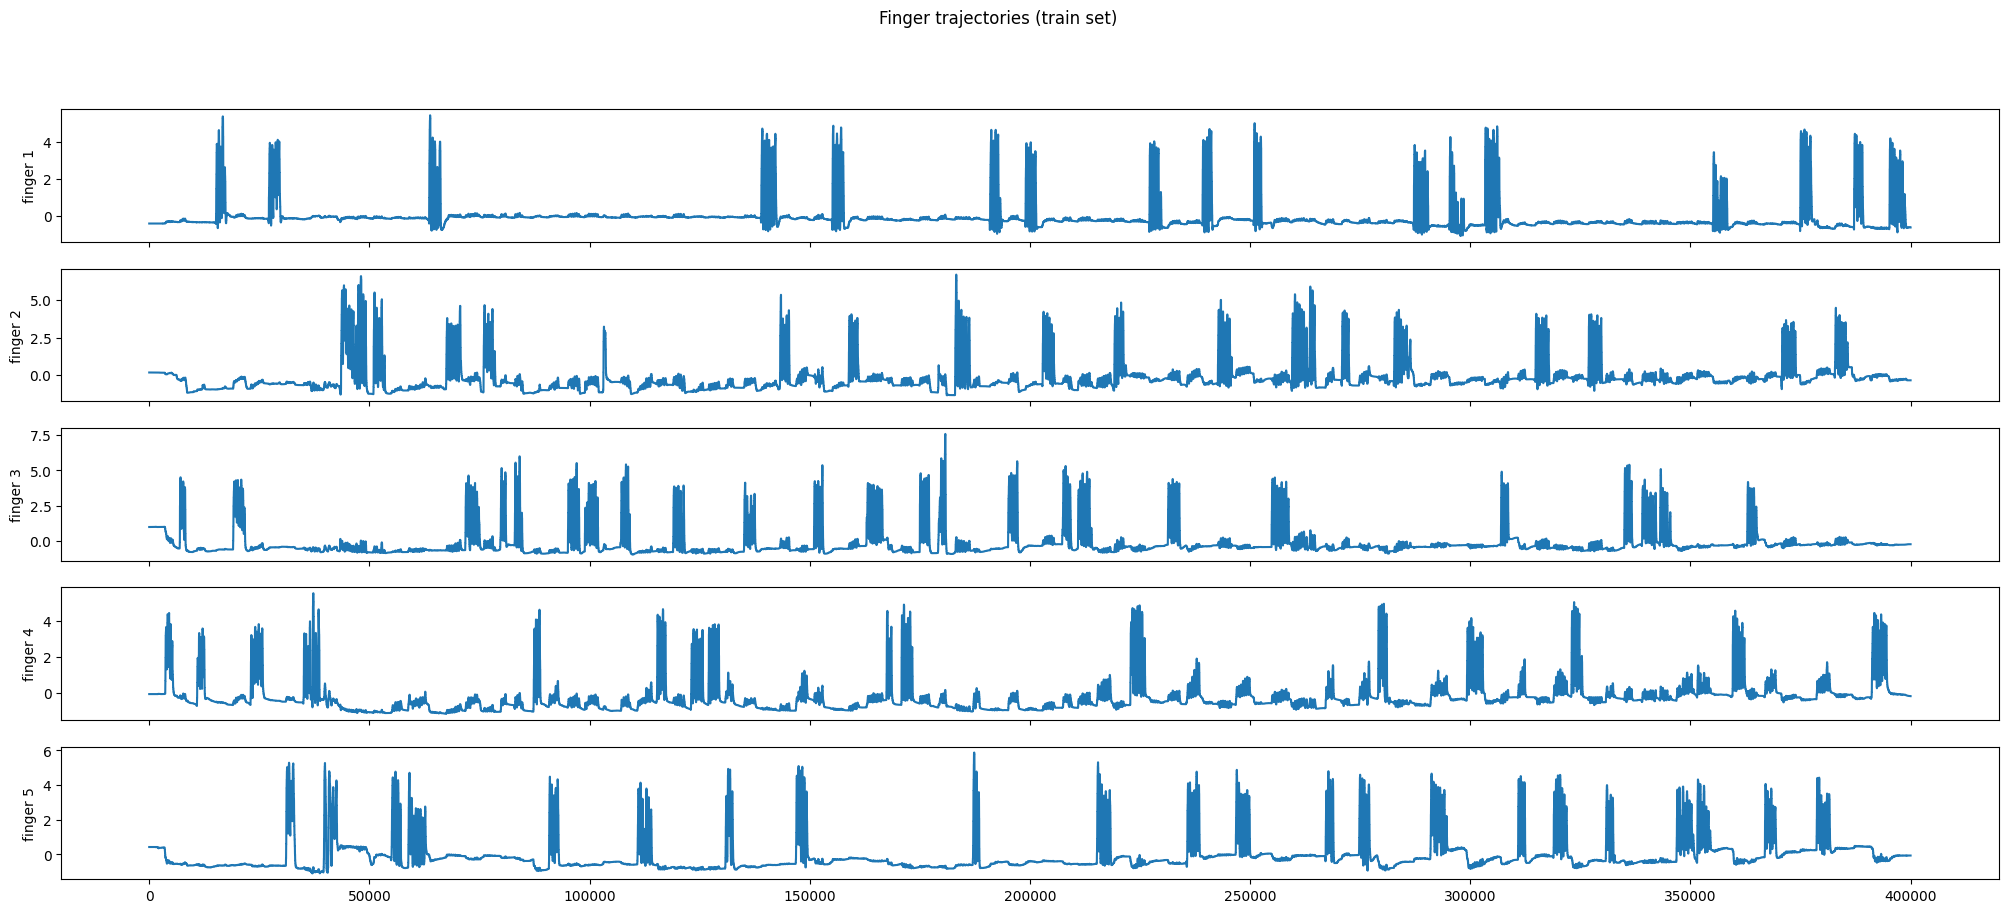

In [92]:
import matplotlib.pyplot as plt

n_fingers = subject_data.train_fingers.shape[1]


fig = plt.figure(figsize=FIGSIZE)  # figure (width, height) in inches
fig.suptitle('Finger trajectories (train set)') #just to give the figure a title

# This creates a grid of subplots with n_fingers rows and 1 column,
axes = fig.subplots(nrows=n_fingers, ncols=1, sharex=True) 

for i in range(n_fingers):
    axes[i].plot(subject_data.train_fingers[:,i]) #this is what actually creates the plot for each finger, using all time samples (:) and the i-th finger (:,i)
    axes[i].set_ylabel(f'finger {i+1}')


#### 2.3.2 Visualize ECoG Signals

ECoG recordings are long and multi-channel. Plotting the full signal at once is usually too dense to read.

Let's see a short time window (delimitated by `start` and `end`) and select specific chanels (`selected_channels`).

In [93]:
import numpy as np
fs = 1000 #This is the sampling frequency of the data 
n_channels = subject_data.train_ecog.shape[1]
selected_channels = [0, 1, 2, 3, 54]

start_time = 0
end = 199_000

time = np.arange(start_time, end) / fs #This creates a time array that goes from 0 to 200 seconds, with a step of 1/fs (1 millisecond) between samples.

In the next plot, each subplot corresponds to one ECoG channel, and the horizontal axis is time in seconds.

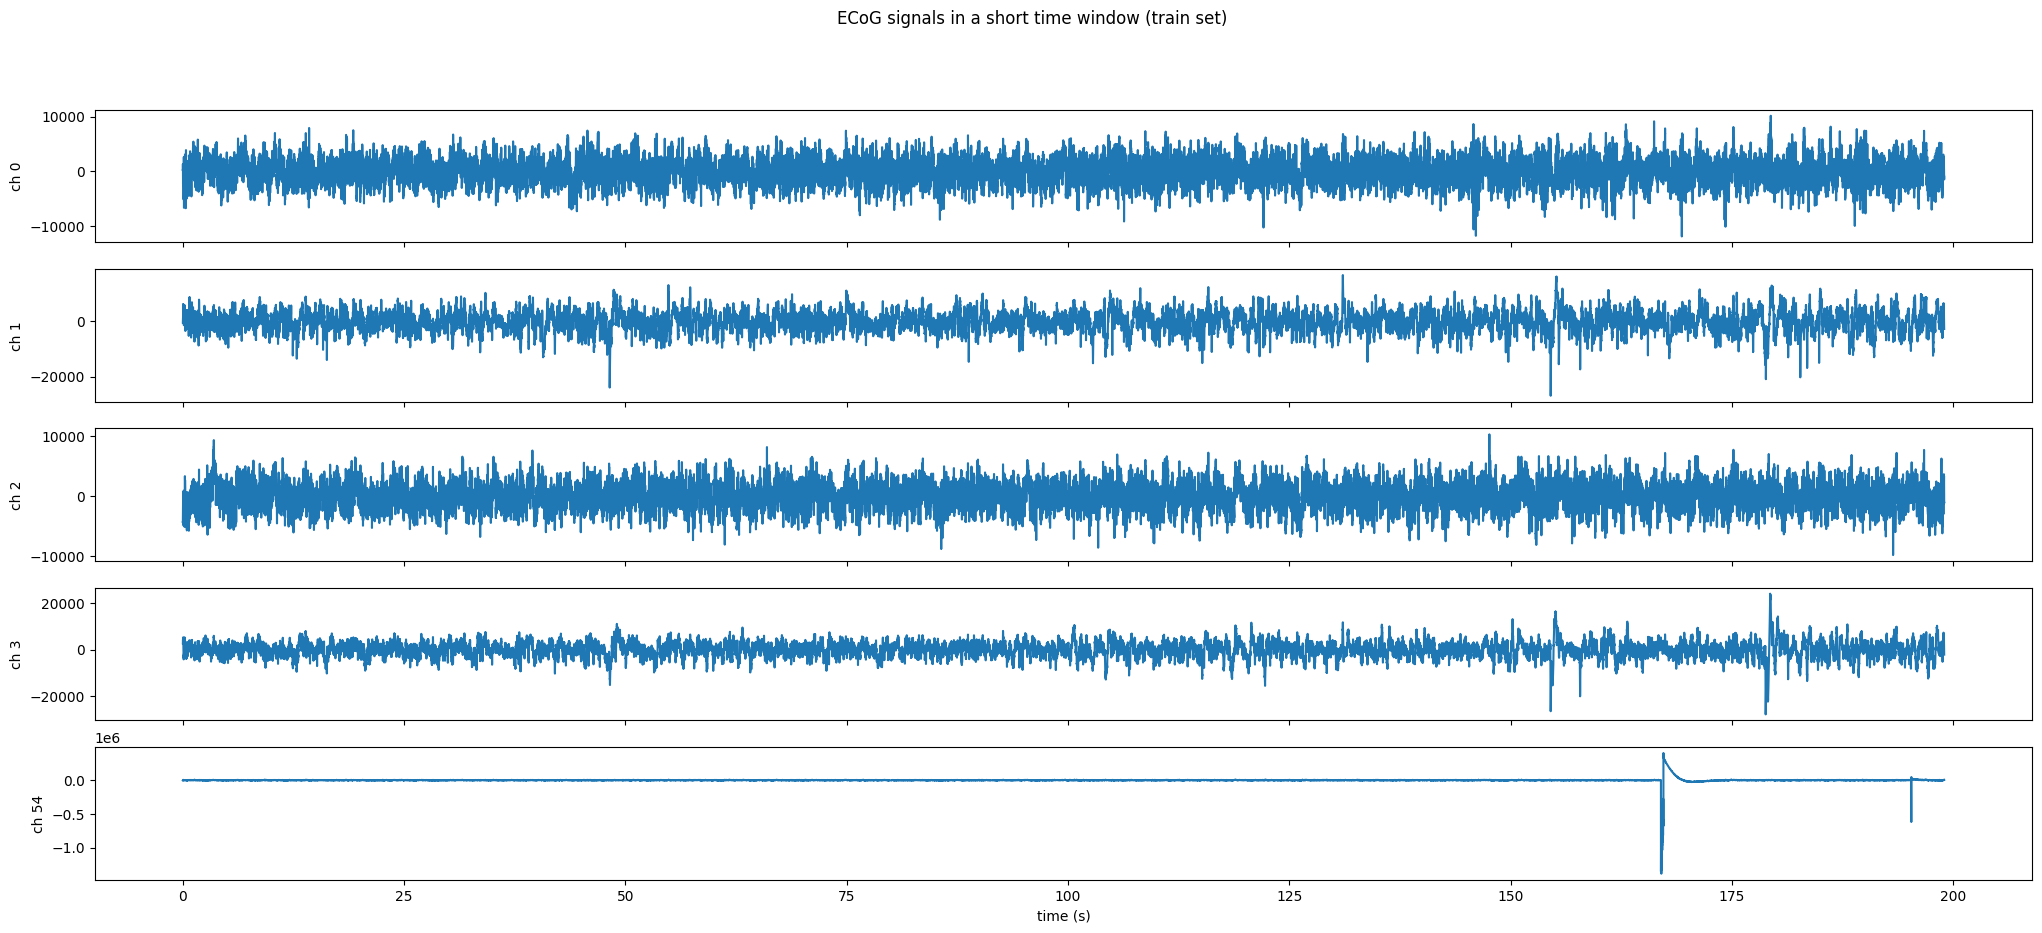

In [94]:
fig = plt.figure(figsize=FIGSIZE)
fig.suptitle('ECoG signals in a short time window (train set)')
axes = fig.subplots(len(selected_channels), 1, sharex=True)
axes[-1].set_xlabel('time (s)')

for ax, channel in zip(axes, selected_channels):
    ax.plot(time, subject_data.train_ecog[start_time:end, channel])
    ax.set_ylabel(f'ch {channel}')


Note that the channel 54 present an artefact

# Part 0: ECoG Preprocessing

This preprocessing block will be shared by both the discrete decoding workflow and the continuous decoding workflow.


## 0.1 Channel Selection

Some channels can be noisy or faulty. After previous visual inspection, we remove channel `54`.

We keep the remaining channels in `channel_selection`.


In [95]:
exclude_channels = [54]
n_channels = subject_data.train_ecog.shape[1]
channel_selection = [i for i in range(n_channels) if i not in exclude_channels]

print('number of selected channels:', len(channel_selection))


number of selected channels: 61


## 0.2 Artefact Removal With CAR

Some noise sources are shared across channels, for example line noise and its harmonics. A simple way to reduce this common activity is the **common average reference (CAR)**.

At each time point, we subtract the average across channels (one can also substract the median):

$$ECoG(c, t) = ECoG(c, t) - \frac{1}{N} \sum_{k=0}^{N-1} ECoG(k, t)$$

> **Note on self-inclusion:** Channel $c$ is itself included in the average being subtracted. This is the standard convention — it slightly attenuates the signal on each channel, but the benefit of removing the common noise shared by all channels far outweighs this small effect.

We apply CAR after removing the faulty channel. The figure below compares the same 10-second window before and after CAR on one electrode channel.

The computation is done in the next code cell, and the visualization is separated just after it.


In [96]:
example_channel_pos = 0
example_channel = channel_selection[example_channel_pos]

ecog_train = tp.common_average_reference(subject_data.train_ecog[:, channel_selection], axis=1)
ecog_test = tp.common_average_reference(subject_data.test_ecog[:, channel_selection], axis=1)

print('ecog_train:', ecog_train.shape)
print('ecog_test :', ecog_test.shape)


ecog_train: (400000, 61)
ecog_test : (200000, 61)


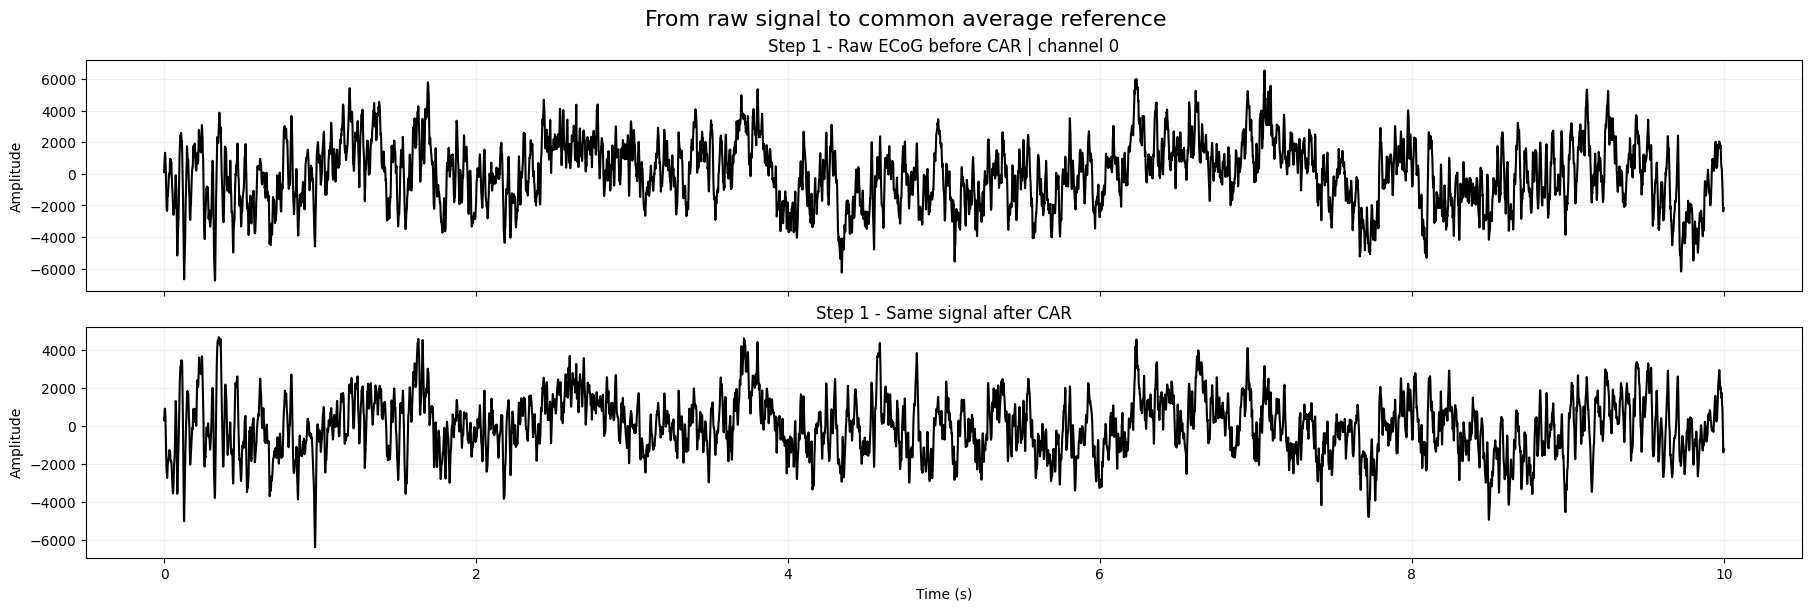

In [97]:
preview_duration_sec = 10
preview_start_sec = 0
preview_start_sample = int(preview_start_sec * fs)
preview_end_sample = min(preview_start_sample + int(preview_duration_sec * fs), subject_data.train_ecog.shape[0])
preview_end_sec = preview_end_sample / fs
preview_slice = slice(preview_start_sample, preview_end_sample)
time_preview = np.arange(preview_start_sample, preview_end_sample) / fs

fig, axes = plt.subplots(2, 1, figsize=(18, 6), sharex=True, constrained_layout=True)

axes[0].plot(time_preview, subject_data.train_ecog[preview_slice, example_channel], color='black')
axes[0].set_title(f'Step 1 - Raw ECoG before CAR | channel {example_channel}')
axes[0].set_ylabel('Amplitude')
axes[0].grid(alpha=0.2)

axes[1].plot(time_preview, ecog_train[preview_slice, example_channel_pos], color='black')
axes[1].set_title('Step 1 - Same signal after CAR')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Amplitude')
axes[1].grid(alpha=0.2)

fig.suptitle('From raw signal to common average reference', fontsize=16)
plt.show()


## 0.3 Band Filtering

In ECoG, the raw signal contains electrical activity at all frequencies. Research has shown that specific **frequency bands** carry different kinds of information about brain activity. For motor decoding (predicting movement), the most informative bands are:

| Band | Frequency range | Relevance for motor decoding |
| --- | --- | --- |
| Delta | 1 – 4 Hz | Slow movement rhythms |
| Theta / Alpha | 4 – 30 Hz | Broad low-frequency activity |
| Beta | 10 – 30 Hz | Motor planning; **decreases before movement** |
| Low Gamma | 30 – 50 Hz | Onset of movement |
| High Gamma | 70 – 200 Hz | Most directly correlated with local neural firing; **key band for ECoG decoding** |

By **bandpass filtering**, we extract only the activity in each frequency range and discard everything outside it. This is similar to how an equalizer isolates bass or treble from an audio signal.

Here we use the helper function `tp.compute_band_filters` to get our filters. The bands used in this notebook are: `(1–10 Hz)`, `(10–30 Hz)`, `(30–50 Hz)`, and `(70–200 Hz)` — covering slow activity up to high gamma.

The next figure compares the CAR-corrected signal with a time-versus-frequency-band view of the same 10-second window.

In [98]:
from scipy.signal import sosfilt

bands = [(1, 10), (10, 30), (30, 50), (70, 200)]
band_labels = [f'{low}-{high} Hz' for low, high in bands]
band_colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
band_centers = np.array([(low + high) / 2 for low, high in bands])
band_filters = tp.compute_band_filters(bands)

train_ecog_filtered = [sosfilt(filt, ecog_train, axis=0) for filt in band_filters]
test_ecog_filtered = [sosfilt(filt, ecog_test, axis=0) for filt in band_filters]

X_train_filtered = np.concatenate(train_ecog_filtered, axis=1)
X_test_filtered = np.concatenate(test_ecog_filtered, axis=1)




print('X_train_filtered:', X_train_filtered.shape)
print('X_test_filtered :', X_test_filtered.shape)


X_train_filtered: (400000, 244)
X_test_filtered : (200000, 244)


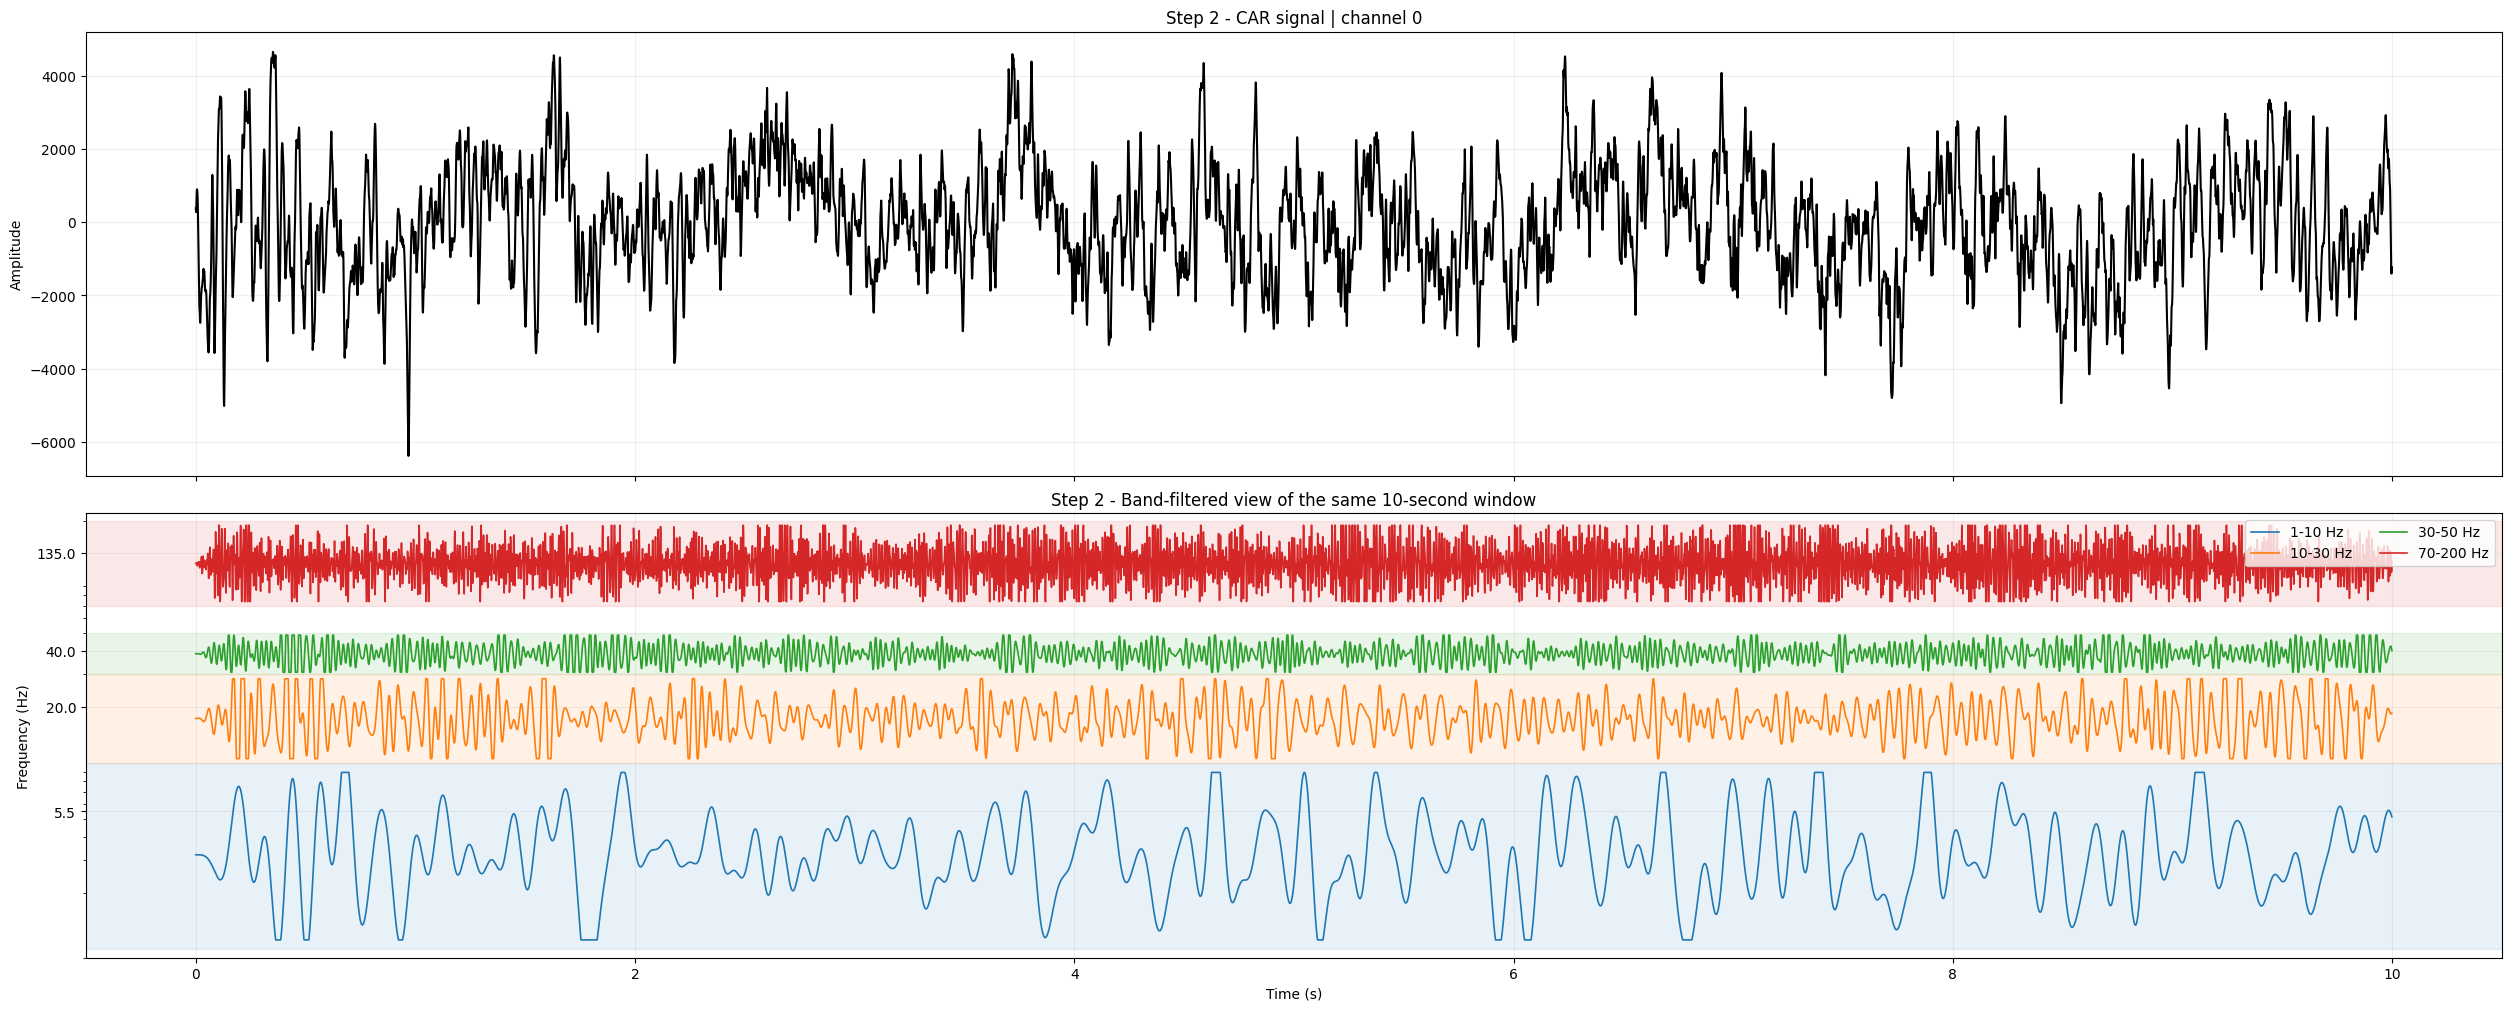

In [99]:
def plot_band_activity(ax, filtered_signals, title):
    band_lows = np.array([low for low, _ in bands], dtype=float)
    band_highs = np.array([high for _, high in bands], dtype=float)

    for filtered_signal, (low, high), center, label, color in zip(
        filtered_signals,
        bands,
        band_centers,
        band_labels,
        band_colors,
    ):
        trace = filtered_signal[preview_slice, example_channel_pos]
        trace_centered = trace - np.median(trace)
        trace_scale = np.percentile(np.abs(trace_centered), 95)
        trace_scaled = trace_centered / np.maximum(trace_scale, 1e-8)
        trace_scaled = np.clip(trace_scaled, -1.0, 1.0)

        # Draw the trace inside its band in log-frequency space so wide high-frequency bands
        # do not dominate the figure visually.
        log_low = np.log10(low)
        log_high = np.log10(high)
        log_center = 0.5 * (log_low + log_high)
        log_half_height = 0.45 * (log_high - log_low)
        trace_frequency = 10 ** (log_center + log_half_height * trace_scaled)

        ax.axhspan(low, high, color=color, alpha=0.10)
        ax.plot(time_preview, trace_frequency, color=color, linewidth=1.2, label=label)

    ax.set_title(title)
    ax.set_ylabel('Frequency (Hz)')
    ax.set_yscale('log')
    ax.set_ylim(0.9 * band_lows.min(), 1.1 * band_highs.max())
    ax.set_yticks(band_centers)
    ax.set_yticklabels([f'{center:.1f}' for center in band_centers])
    ax.grid(alpha=0.2)
    ax.legend(loc='upper right', ncols=2)

fig, axes = plt.subplots(2, 1, figsize=FIGSIZE, sharex=True, constrained_layout=True)

axes[0].plot(time_preview, ecog_train[preview_slice, example_channel_pos], color='black')
axes[0].set_title(f'Step 2 - CAR signal | channel {example_channel}')
axes[0].set_ylabel('Amplitude')
axes[0].grid(alpha=0.2)

plot_band_activity(axes[1], train_ecog_filtered, 'Step 2 - Band-filtered view of the same 10-second window')
axes[1].set_xlabel('Time (s)')

plt.show()


Note that, for visualization purposes, the vertical scale has been adjusted. However, the amplitudes in the high-frequency bands are lower than those in the low-frequency bands. This difference becomes more apparent in the next section.

## 0.4 Power Features

We now convert the filtered ECoG signal into power features. For a centered signal $x$, the average power over a window of length $N$ is:

\begin{align}
P(x) = \frac{1}{N}\sum_{t}x^2(t),
\end{align}

We directly use `tp.buffering_power` for computing the power features.

We use `hop_size = 40`, which corresponds to one feature vector every 40 ms, that is a final sampling rate of `25 Hz`. This matches the temporal resolution used later for the discrete labels.

The next figure compares the band-filtered representation with the resulting power features on the same channel and the same 10-second window.

As above, the feature computation cell is followed by a separate figure cell.


In [100]:
hop_size = 40
feature_win_size = 1000

X_train_features_raw = tp.buffering_power(X_train_filtered, feature_win_size, hop_size)
X_test_features_raw = tp.buffering_power(X_test_filtered, feature_win_size, hop_size)

print('X_train_features_raw:', X_train_features_raw.shape)
print('X_test_features_raw :', X_test_features_raw.shape)

feature_time = np.arange(X_train_features_raw.shape[0]) * hop_size / fs
preview_feature_mask = (feature_time >= preview_start_sec) & (feature_time < preview_end_sec)
power_indices = [band_idx * len(channel_selection) + example_channel_pos for band_idx in range(len(bands))]


X_train_features_raw: (10000, 244)
X_test_features_raw : (5000, 244)


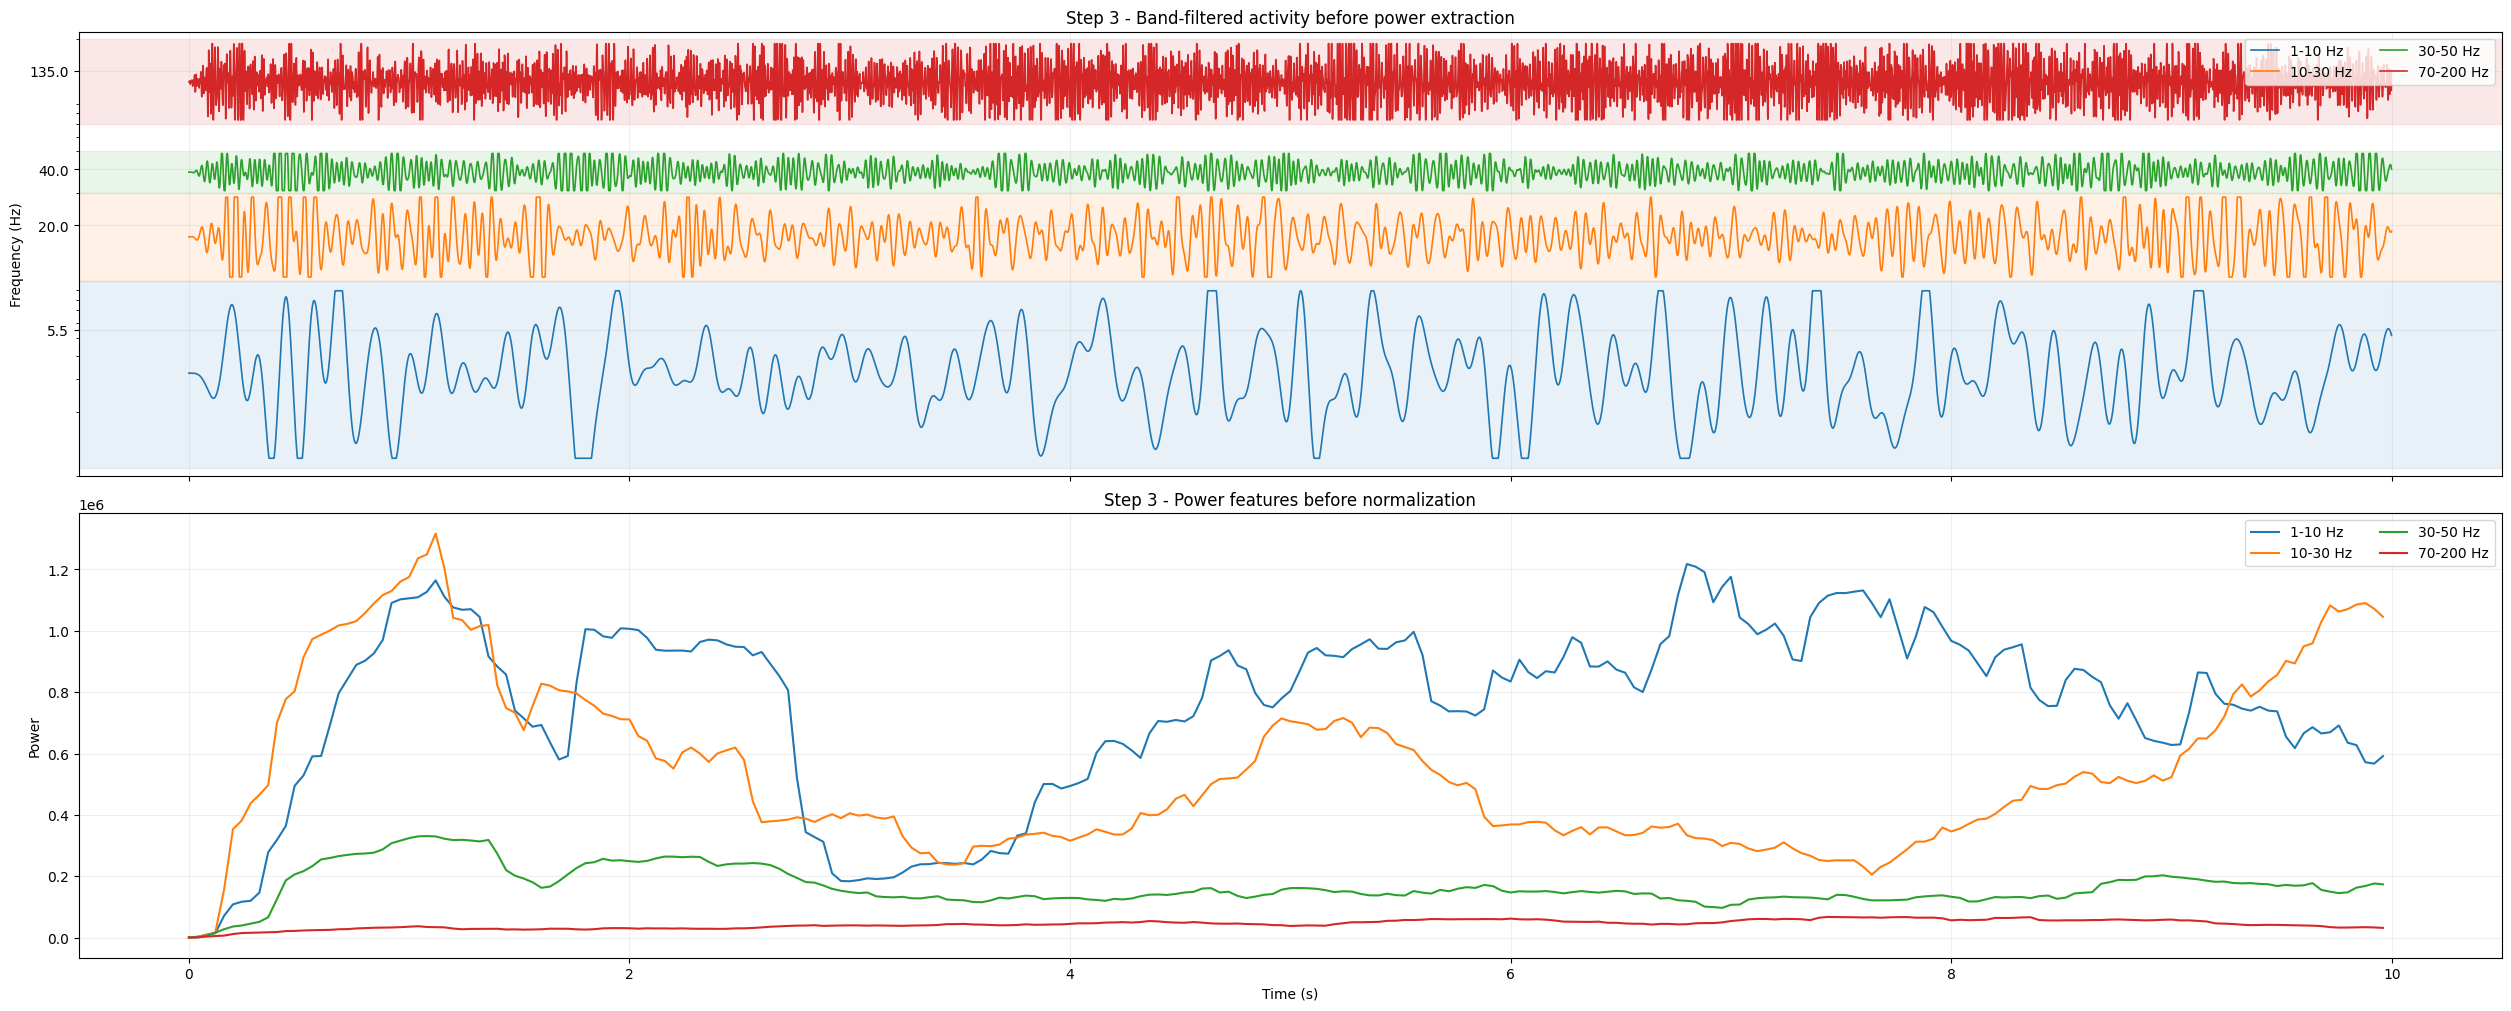

In [101]:
fig, axes = plt.subplots(2, 1, figsize=FIGSIZE, sharex=True, constrained_layout=True)

plot_band_activity(axes[0], train_ecog_filtered, 'Step 3 - Band-filtered activity before power extraction')

for power_idx, label, color in zip(power_indices, band_labels, band_colors):
    axes[1].plot(
        feature_time[preview_feature_mask],
        X_train_features_raw[preview_feature_mask, power_idx],
        label=label,
        color=color,
        linewidth=1.5,
    )
axes[1].set_title('Step 3 - Power features before normalization')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Power')
axes[1].grid(alpha=0.2)
axes[1].legend(loc='upper right', ncols=2)

plt.show()


Here, we observe that high-frequency bands exhibit lower power than low-frequency bands, consistent with a $1/f$ scaling.

## 0.5 Feature Normalization

The four band-power features do not naturally live on the same scale. A standard final preprocessing step is therefore a **z-score normalization** applied feature by feature:

$$x_{\mathrm{norm}} = \frac{x - \mu_{\mathrm{train}}}{\sigma_{\mathrm{train}}}$$

To avoid leaking validation information into preprocessing, we estimate $\mu_{\mathrm{train}}$ and $\sigma_{\mathrm{train}}$ on the **first 80% of the training recording only** (the same split that will later become the training subset), and then reuse these statistics for the validation and test data.

The figure below compares the four unnormalized band-power features with the same four features after normalization.

The normalization computation is separated from the comparison figure in the next cell.


In [102]:
n_train_feature_samples = int(0.8 * X_train_features_raw.shape[0])
feature_mean = X_train_features_raw[:n_train_feature_samples].mean(axis=0, keepdims=True)
feature_std = X_train_features_raw[:n_train_feature_samples].std(axis=0, keepdims=True)
feature_std = np.where(feature_std < 1e-8, 1.0, feature_std)

X_train_features_full = (X_train_features_raw - feature_mean) / feature_std
X_test_full = (X_test_features_raw - feature_mean) / feature_std

print('X_train_features_full (normalized):', X_train_features_full.shape)
print('X_test_full (normalized)         :', X_test_full.shape)


X_train_features_full (normalized): (10000, 244)
X_test_full (normalized)         : (5000, 244)


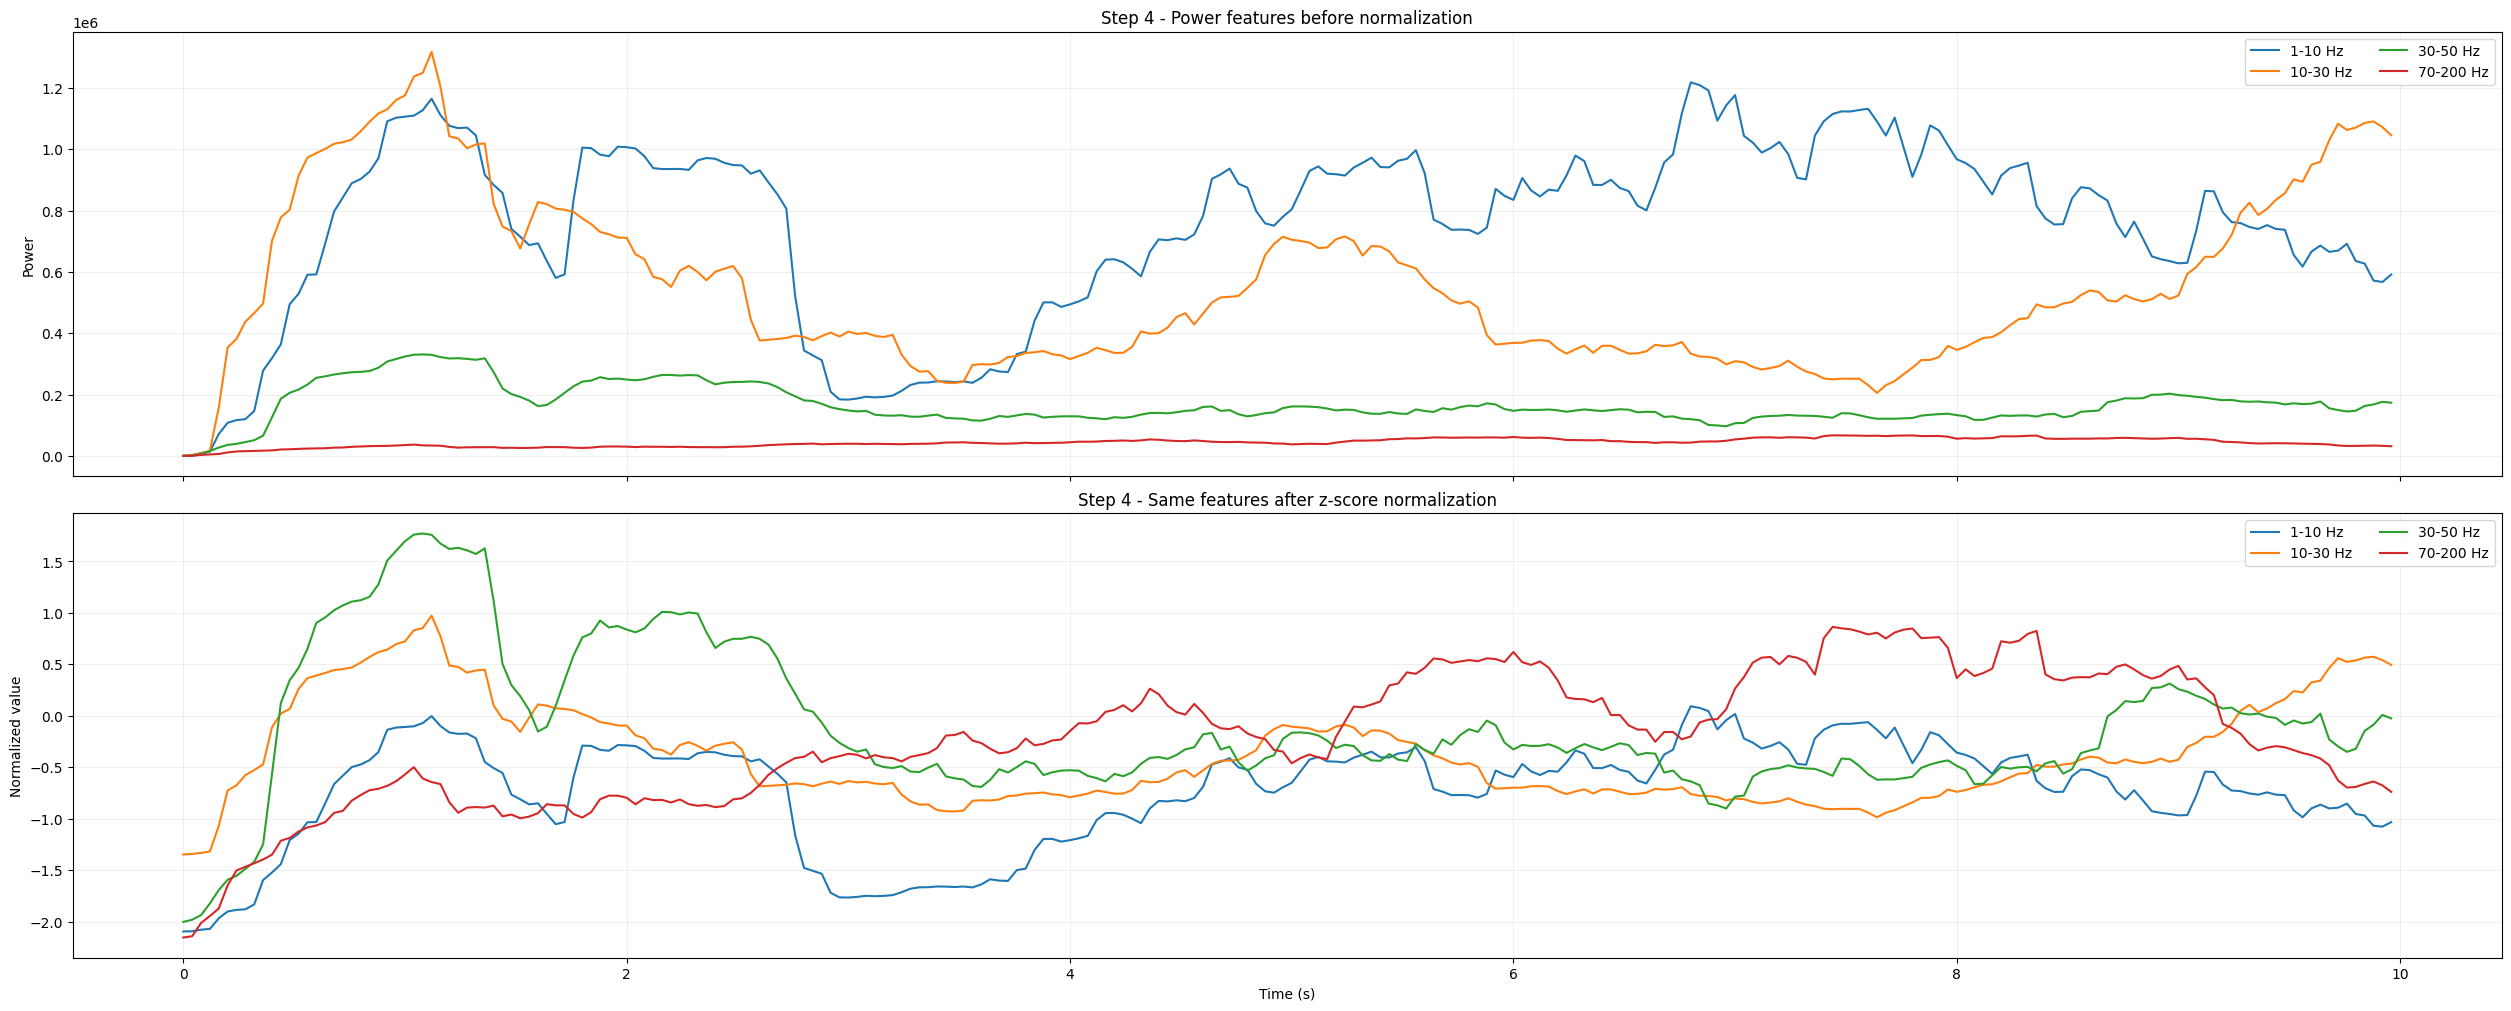

In [103]:
fig, axes = plt.subplots(2, 1, figsize=FIGSIZE, sharex=True, constrained_layout=True)

for power_idx, label, color in zip(power_indices, band_labels, band_colors):
    axes[0].plot(
        feature_time[preview_feature_mask],
        X_train_features_raw[preview_feature_mask, power_idx],
        label=label,
        color=color,
        linewidth=1.5,
    )
axes[0].set_title('Step 4 - Power features before normalization')
axes[0].set_ylabel('Power')
axes[0].grid(alpha=0.2)
axes[0].legend(loc='upper right', ncols=2)

for power_idx, label, color in zip(power_indices, band_labels, band_colors):
    axes[1].plot(
        feature_time[preview_feature_mask],
        X_train_features_full[preview_feature_mask, power_idx],
        label=label,
        color=color,
        linewidth=1.5,
    )
axes[1].set_title('Step 4 - Same features after z-score normalization')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Normalized value')
axes[1].grid(alpha=0.2)
axes[1].legend(loc='upper right', ncols=2)

plt.show()


# DECODING


# Part 1: Discrete Decoding

In this part, we turn the continuous finger trajectories into **discrete labels**, train a classifier, and evaluate the decoding performance.

The ECoG preprocessing, feature extraction, and final normalization were already prepared in **Part 0**.


## 1.1 Create Discrete Labels

We will build the labels in three explicit steps

1. **Downsampling**
2. **Smoothing**
3. **Thresholding**


### 1.1.1 Downsampling

The finger trajectories are sampled at `fs = 1000` Hz. We use `f_ratio = hop_size = 40` from Part 0 and keep one sample every `f_ratio` points.

This gives `train_fingers_downsampled` and `test_fingers_downsampled`.


In [104]:
import numpy as np

f_ratio = hop_size
threshold = 0.5
label_win_size = 25

n_times_train_full = subject_data.train_fingers.shape[0] // f_ratio
n_times_test = subject_data.test_fingers.shape[0] // f_ratio
n_fingers = subject_data.train_fingers.shape[1]

train_fingers_downsampled = subject_data.train_fingers[::f_ratio]
test_fingers_downsampled = subject_data.test_fingers[::f_ratio]


### 1.1.2 Smoothing

The downsampled trajectories can still be a bit jagged. We therefore smooth `train_fingers_downsampled` and `test_fingers_downsampled` with a moving-average window.

The window length is controlled by `label_win_size`, and the averaging kernel itself is stored in `label_win`.

This produces the variables `train_fingers_filtered` and `test_fingers_filtered`.


In [105]:
from scipy.signal import convolve

label_win = np.ones((label_win_size, 1)) / label_win_size

train_fingers_filtered = convolve(train_fingers_downsampled, label_win, 'same')
test_fingers_filtered = convolve(test_fingers_downsampled, label_win, 'same')


### 1.1.3 Thresholding

Finally, we compare the smoothed trajectories to a fixed value `threshold`.

At each time point, if all finger trajectories are below `threshold = 0.5`, we consider that the subject is in a `rest` state.

To represent this extra state, we concatenate one additional column filled with `threshold`. This creates `train_fingers_thresholded` and `test_fingers_thresholded`, with one supplementary column corresponding to the `rest` class.

Then we take the largest value with `argmax` to obtain the discrete labels `y_train_full` and `y_test`. For plotting convenience, we also build one-hot matrices `cue_train_full` and `cue_test`.


In [106]:
train_fingers_thresholded = np.concatenate((train_fingers_filtered, threshold * np.ones((n_times_train_full, 1))), axis=1)
test_fingers_thresholded = np.concatenate((test_fingers_filtered, threshold * np.ones((n_times_test, 1))), axis=1)

y_train_full = np.argmax(train_fingers_thresholded, axis=1)
y_test = np.argmax(test_fingers_thresholded, axis=1)

cue_train_full = np.zeros((n_times_train_full, n_fingers + 1))
cue_test = np.zeros((n_times_test, n_fingers + 1))
cue_train_full[np.arange(n_times_train_full), y_train_full] = 1
cue_test[np.arange(n_times_test), y_test] = 1


### Visualize The Labels

The figure below compares the three key variables built above:

- `train_fingers_downsampled`
- `train_fingers_filtered`
- `cue_train_full`

The legend identifies the five fingers, the `rest` class, and the black threshold line.


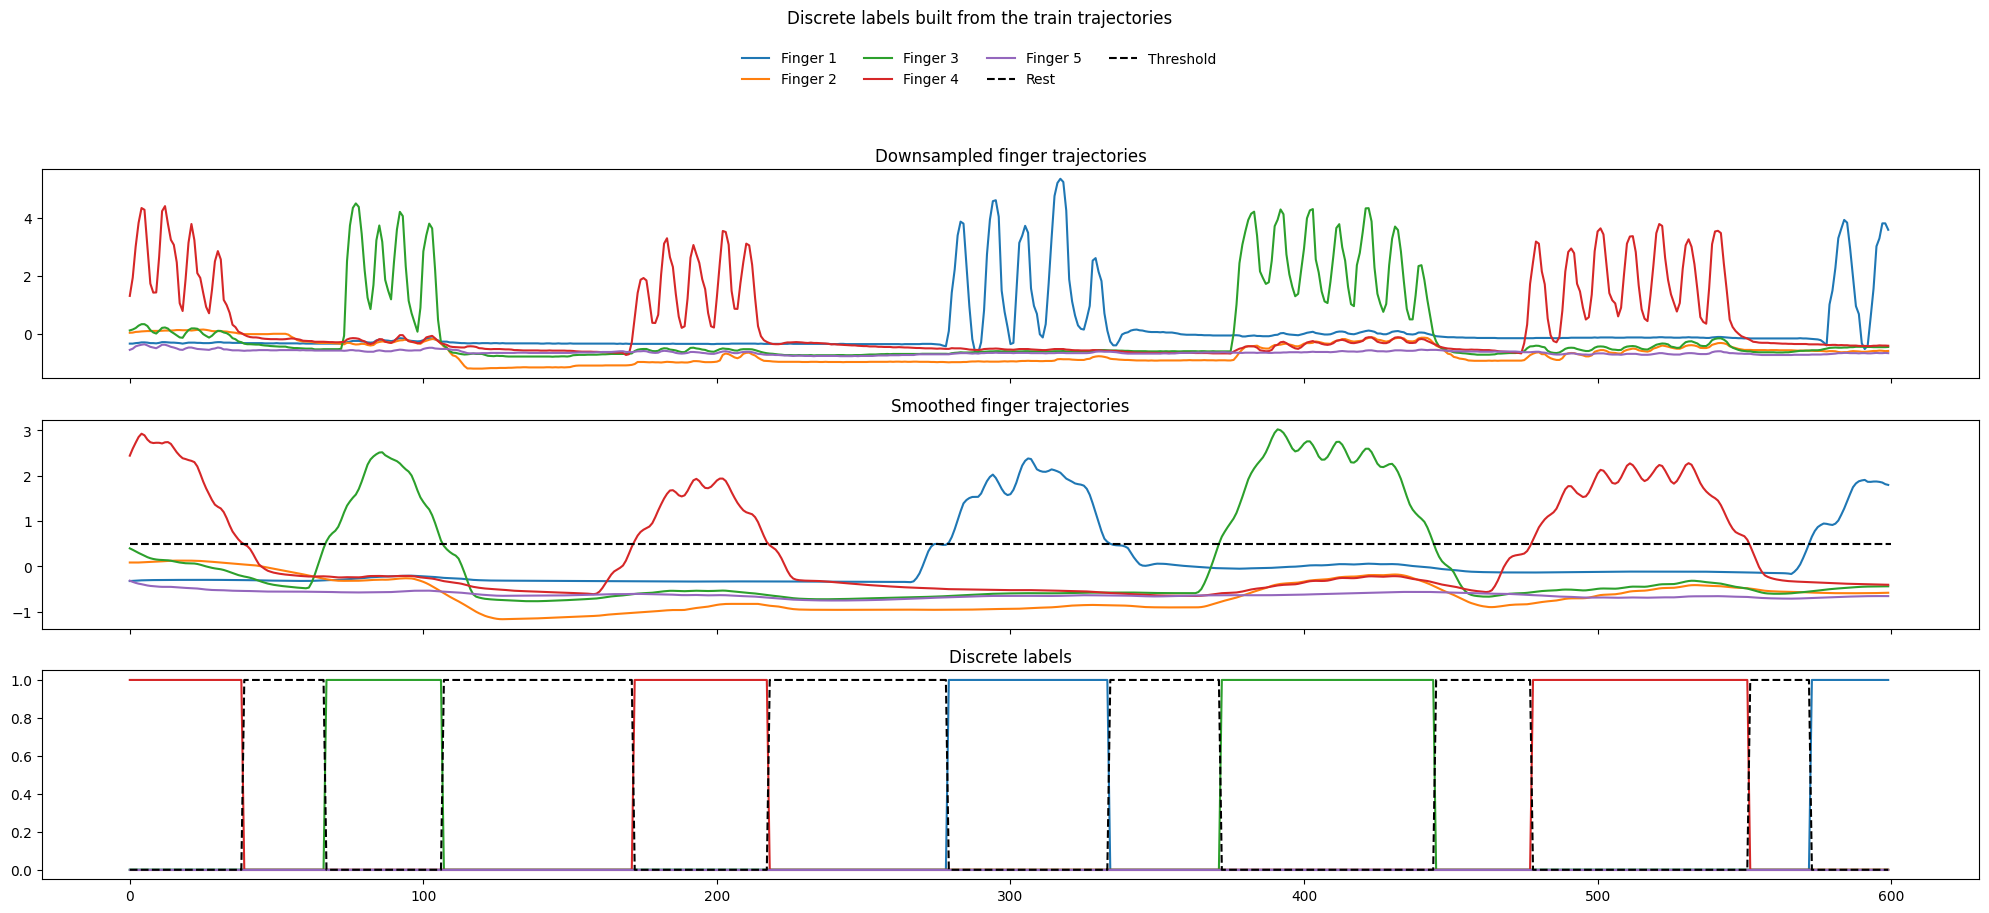

In [107]:
start_time = 100
end = 700

fig = plt.figure(figsize=FIGSIZE)
fig.suptitle('Discrete labels built from the train trajectories')

ax = fig.subplots(3, 1, sharex=True)
ax[0].set_title('Downsampled finger trajectories')
ax[1].set_title('Smoothed finger trajectories')
ax[2].set_title('Discrete labels')

finger_labels = [f'Finger {i + 1}' for i in range(n_fingers)]
finger_handles = []

for i in range(n_fingers):
    line, = ax[0].plot(train_fingers_downsampled[start_time:end, i], label=finger_labels[i])
    ax[1].plot(train_fingers_filtered[start_time:end, i], color=line.get_color())
    ax[2].plot(cue_train_full[start_time:end, i], color=line.get_color())
    finger_handles.append(line)

threshold_handle, = ax[1].plot([0, end - start_time], [threshold, threshold], color='k', linestyle='--', label='Threshold')
rest_handle, = ax[2].plot(cue_train_full[start_time:end, n_fingers], color='k', linestyle='--', label='Rest')

fig.subplots_adjust(top=0.82)
fig.legend(handles=finger_handles + [rest_handle, threshold_handle], loc='upper center', ncol=4, bbox_to_anchor=(0.5, 0.95), frameon=False)


## 1.2 Split The Data Into Train / Validation / Test

We now split the original training set into a new training subset and a validation subset, while keeping the original test set untouched.


X_train: (8000, 244)
X_val: (2000, 244)
X_test: (5000, 244)
train labels: (8000,)
validation labels: (2000,)
test labels: (5000,)


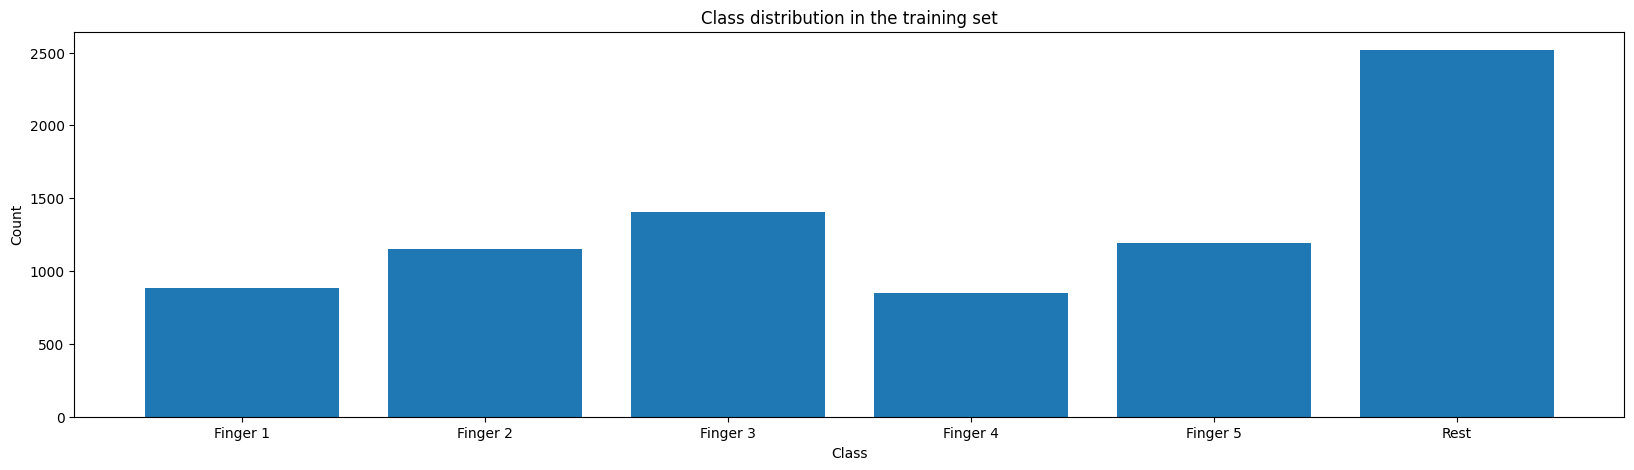

In [108]:
n_train_samples = int(0.8 * n_times_train_full)
train_slice = slice(0, n_train_samples)
val_slice = slice(n_train_samples, n_times_train_full)

X_train = X_train_features_full[train_slice]
X_val = X_train_features_full[val_slice]
X_test = X_test_full

y_train = y_train_full[train_slice]
y_val = y_train_full[val_slice]

print('X_train:', X_train.shape)
print('X_val:', X_val.shape)
print('X_test:', X_test.shape)
print('train labels:', y_train.shape)
print('validation labels:', y_val.shape)
print('test labels:', y_test.shape)

#print class distribution in the training set
import matplotlib.pyplot as plt
unique, counts = np.unique(y_train, return_counts=True)
fig = plt.figure(figsize=(20, 5))
plt.bar(unique, counts)
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class distribution in the training set')
plt.xticks(unique, [f'Finger {i+1}' for i in unique[:-1]] + ['Rest'])
plt.show()


## 1.3 Scikit-Learn And Model Usage

In scikit-learn, most estimators follow the same API:

- `fit(X, y)` trains the model;
- `predict(X)` returns predicted labels;
- `predict_proba(X)` returns class probabilities when the estimator supports them.

We start with a strong baseline: **Linear Discriminant Analysis (LDA)** with automatic shrinkage.

### Geometric intuition

The core idea of LDA is simple: **each class lives in its own region of the feature space**. LDA models each class as a cloud of points (a Gaussian distribution). All clouds are assumed to have the same shape (the same covariance matrix $\Sigma$), but different centers $\mu_k$.

The decision boundary between two classes is then a **flat hyperplane** (a line in 2D, a plane in 3D) — hence the name *Linear* Discriminant Analysis.

To classify a new point $x$, LDA asks: which class center is closest, taking the shared shape of the clouds into account?

### Mathematical formulation

Formally, LDA assigns $x$ to the class $k$ that maximises the discriminant score:

$$\hat{y}(x) = \arg\max_k \; \delta_k(x)$$

with

$$\delta_k(x) = x^T \Sigma^{-1} \mu_k - \frac{1}{2} \mu_k^T \Sigma^{-1} \mu_k + \log \pi_k$$

where:
- $\mu_k$ is the mean of class $k$ (the center of that cloud),
- $\Sigma$ is the shared covariance matrix (the common shape of all clouds),
- $\pi_k$ is the prior probability of class $k$ (how frequent that class is in training data).

The $\Sigma^{-1}$ term acts as a rescaling: it accounts for the fact that some directions in feature space have more variance than others.


In [109]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

ESTIMATOR_KWARGS = {'solver': 'lsqr', 'shrinkage': 'auto'}
estimator = LDA(**ESTIMATOR_KWARGS)
estimator


,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'lsqr'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",'auto'
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


## 1.4 Train The Model

We first train the baseline model on the training split, then inspect both the validation and the test predictions.


In [110]:
estimator.fit(X_train, y_train)

y_val_pred = estimator.predict(X_val)
y_test_pred = estimator.predict(X_test)

## 1.5 Metrics

We will look at four standard classification metrics, plus one reference baseline.

### Reference baseline

- **Chance level relative to the validation set**: we use the class that is most frequent in the **validation set** and ask what accuracy we would obtain by always predicting that class. In this dataset the `rest` class often dominates, so this validation-majority baseline is a much more relevant lower bound than the uniform `1 / n_classes` rule.

### Classification metrics

- **precision**: among the samples predicted as one class, how many are actually from that class.

$$\text{precision} = \frac{TP}{TP + FP}$$

- **recall**: among the samples that truly belong to one class, how many are correctly recovered by the model.

$$\text{recall} = \frac{TP}{TP + FN}$$

- **accuracy**: the overall fraction of correct predictions across all samples.

$$\text{accuracy} = \frac{\text{number of correct predictions}}{\text{total number of predictions}}$$

- **F1-score**: the harmonic mean of precision and recall. It is more robust than accuracy because it penalizes both false positives and false negatives.

$$F_1 = 2 \times \frac{\text{precision} \times \text{recall}}{\text{precision} + \text{recall}}$$

- **confusion matrix**: a detailed view of which classes are confused with which others. Its coefficient `(i, j)` counts how many samples of true class `i` are predicted as class `j`.

Because we have multiple classes, we use **balanced accuracy** and **macro F1** so that each class has the same weight in the final metric:

- **balanced accuracy**: the average recall across classes.

$$\text{balanced accuracy} = \frac{1}{K} \sum_{k=1}^{K} \text{recall}_k$$

- **macro F1**: the average F1-score across classes.

$$\text{macro F1} = \frac{1}{K} \sum_{k=1}^{K} F_{1,k}$$

In short, `accuracy` gives a global score over all samples, while `balanced accuracy` and `macro F1` give the same importance to every class. **For imbalanced datasets like ours, always prefer balanced accuracy and macro F1 as your primary metrics.**


In [111]:
def print_classification_metrics(name, y_true, y_pred, reference_labels=None, reference_name='validation set'):
    n_classes = len(np.unique(y_true))
    reference_labels = y_true if reference_labels is None else reference_labels

    majority_class = np.bincount(reference_labels).argmax()
    majority_acc = np.mean(y_true == majority_class)

    if 'n_fingers' in globals() and majority_class == n_fingers:
        majority_label = 'Rest'
    elif 'n_fingers' in globals() and majority_class < n_fingers:
        majority_label = f'Finger {majority_class + 1}'
    else:
        majority_label = f'Class {majority_class}'

    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')

    print(name)
    print(f'  number of classes                  : {n_classes}')
    print(f'  chance level ({reference_name})    : {majority_acc:.3f} (always predict {majority_label})')
    print(f'  accuracy                           : {acc:.3f}')
    print(f'  balanced accuracy                  : {bal_acc:.3f}')
    print(f'  macro F1                           : {macro_f1:.3f}')

print_classification_metrics('Validation metrics (LDA)', y_val, y_val_pred, reference_labels=y_val)
print_classification_metrics('Test metrics (LDA)', y_test, y_test_pred, reference_labels=y_val)


Validation metrics (LDA)
  number of classes                  : 6
  chance level (validation set)    : 0.238 (always predict Rest)
  accuracy                           : 0.491
  balanced accuracy                  : 0.476
  macro F1                           : 0.484
Test metrics (LDA)
  number of classes                  : 6
  chance level (validation set)    : 0.169 (always predict Rest)
  accuracy                           : 0.451
  balanced accuracy                  : 0.451
  macro F1                           : 0.449


Text(0.5, 1.0, 'Confusion matrix (LDA on test set)')

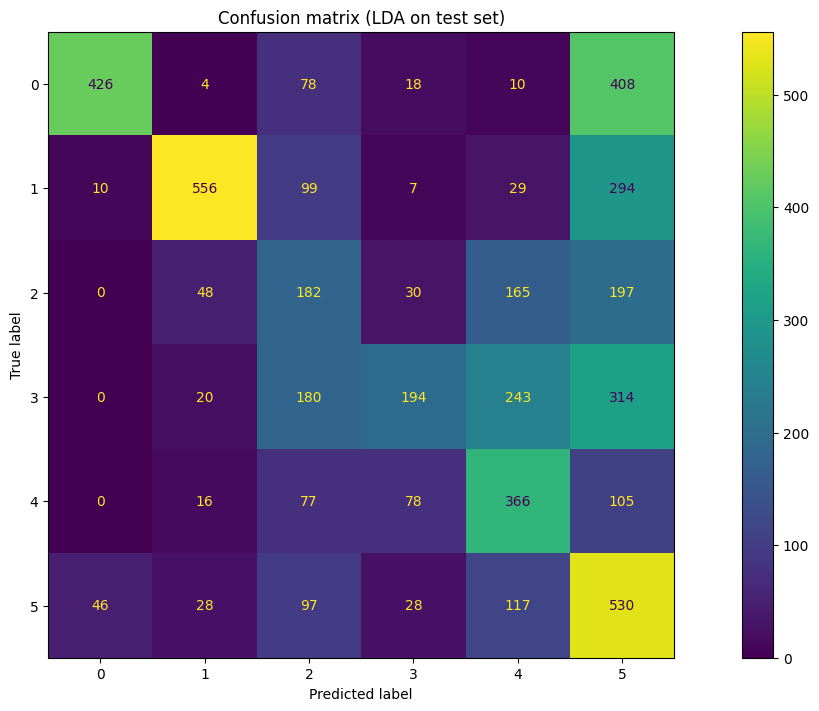

In [112]:
fig, axes = plt.subplots(1,  figsize=(15,7), constrained_layout=True)
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, ax=axes)
plt.title('Confusion matrix (LDA on test set)')

The confusion matrix shows that the model tends to **fall back to the validation-majority class** in a large number of cases: the corresponding prediction column gathers many samples coming from several different true classes.

In other words, when the LDA is uncertain, it often predicts the dominant class instead of separating the minority classes cleanly. This is exactly why it is more relevant to report a **chance level based on the majority class of the validation set** than a uniform `1 / n_classes` baseline.


### Visualize Predictions Vs. Ground Truth

The next figure shows a short segment of the test set:

- the ground-truth labels `y_test`;
- the predicted labels `y_test_pred`;
- the class probabilities `y_test_proba`.

This makes it easier to see where the model is correct, where it makes mistakes, and how confident it is.


In [113]:
class_labels = [f'Finger {i + 1}' for i in range(n_fingers)] + ['Rest']

tp.plot_prediction_vs_truth(
    y_test,
    y_test_pred,
    sample_rate=fs / hop_size,
    class_labels=class_labels,
    title='Prediction vs. ground truth on a short test segment',
    predicted_label='Model Prediction',
)


## 1.6 Advanced: Temporal Shift And Dimensionality Reduction

The ECoG signal and the finger label do not necessarily evolve at exactly the same time. In practice, the neural activity can appear slightly before or after the label we want to predict.

To account for this, we introduce a **temporal shift**: we shift the ECoG features with respect to the labels and keep the value that gives the best validation accuracy. Then we try PCA.


### 1.6.1 Find The Best Temporal Shift

We test several values of `shift_grid` on the validation set and keep the value `best_shift` that gives the best `balanced_accuracy_score`.

**What does a temporal shift mean?**

Imagine the label (finger class) and the ECoG feature aligned in time:

```
Time:    ... t-3  t-2  t-1   t   t+1  t+2  ...
Label:   ...  R    R    F1   F1   F1   R   ...   (R=rest, F1=finger 1)
ECoG:    ...  e    e    e    e    e    e   ...
```

With `shift = 0`, we predict label at time `t` using ECoG features at time `t`.
With `shift = -2` (negative = look earlier), we predict label at time `t` using ECoG features at time `t-2`.

In brain-computer interfaces, neural activity typically **precedes** movement by a few hundred milliseconds. A negative shift allows the model to exploit this lead time: the brain signal "warns" us that a movement is about to happen before it actually does.

We test several values in `shift_grid` on the validation set and keep the value `best_shift` that gives the best `balanced_accuracy_score`.


best_shift: -20 samples (-0.80 s)


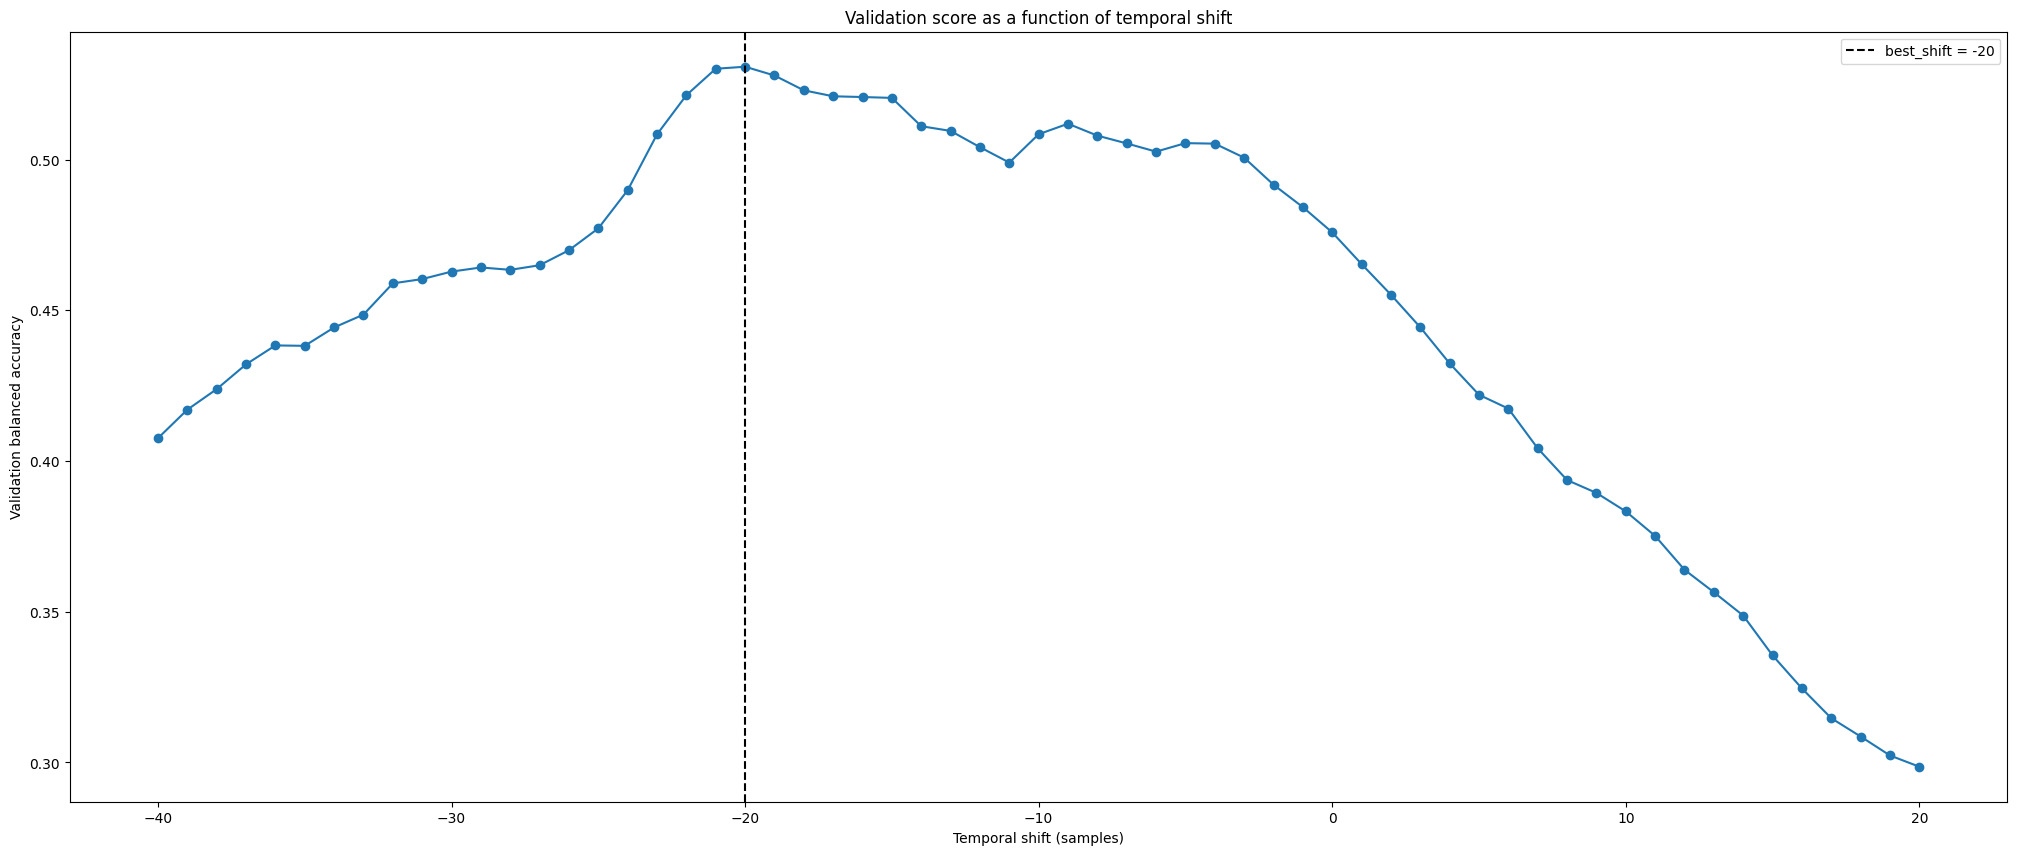

In [114]:
def apply_temporal_shift(X, y, shift):
    n_times = X.shape[0]
    X_shifted = X[max(-shift, 0):min(n_times - shift, n_times)]
    y_shifted = y[max(shift, 0):min(n_times + shift, n_times)]
    return X_shifted, y_shifted

shift_grid = np.arange(-40, 21)
shift_scores = []

for shift in shift_grid:
    X_train_candidate, y_train_candidate = apply_temporal_shift(X_train, y_train, shift)
    X_val_candidate, y_val_candidate = apply_temporal_shift(X_val, y_val, shift)

    estimator_shift = LDA(**ESTIMATOR_KWARGS)
    estimator_shift.fit(X_train_candidate, y_train_candidate)
    y_val_pred_candidate = estimator_shift.predict(X_val_candidate)
    shift_scores.append(balanced_accuracy_score(y_val_candidate, y_val_pred_candidate))

best_shift = int(shift_grid[np.argmax(shift_scores)])
print(f'best_shift: {best_shift} samples ({best_shift / 25:.2f} s)')

plt.figure(figsize=FIGSIZE)
plt.plot(shift_grid, shift_scores, marker="o")
plt.axvline(best_shift, color="k", linestyle="--", label=f"best_shift = {best_shift}")
plt.xlabel("Temporal shift (samples)")
plt.ylabel("Validation balanced accuracy")
plt.title("Validation score as a function of temporal shift")
plt.legend()


### 1.6.2 Apply The Best Temporal Shift

We now build shifted train, validation, and test sets.


In [115]:
X_train_shifted, y_train_shifted = apply_temporal_shift(X_train, y_train, best_shift)
X_val_shifted, y_val_shifted = apply_temporal_shift(X_val, y_val, best_shift)
X_test_shifted, y_test_shifted = apply_temporal_shift(X_test, y_test, best_shift)

print('X_train_shifted:', X_train_shifted.shape)
print('X_val_shifted:', X_val_shifted.shape)
print('X_test_shifted:', X_test_shifted.shape)


X_train_shifted: (7980, 244)
X_val_shifted: (1980, 244)
X_test_shifted: (4980, 244)


### 1.6.3 Train LDA With The Best Temporal Shift

We now train the baseline LDA again on the shifted features.


In [116]:
estimator_shift = LDA(**ESTIMATOR_KWARGS)
estimator_shift.fit(X_train_shifted, y_train_shifted)

y_val_pred_shift = estimator_shift.predict(X_val_shifted)
y_test_pred_shift = estimator_shift.predict(X_test_shifted)
y_test_proba_shift = estimator_shift.predict_proba(X_test_shifted)

print_classification_metrics(
    'Validation metrics (temporal-shifted LDA)',
    y_val_shifted,
    y_val_pred_shift,
    reference_labels=y_val_shifted,
)
print_classification_metrics(
    'Test metrics (temporal-shifted LDA)',
    y_test_shifted,
    y_test_pred_shift,
    reference_labels=y_val_shifted,
)


Validation metrics (temporal-shifted LDA)
  number of classes                  : 6
  chance level (validation set)    : 0.233 (always predict Finger 5)
  accuracy                           : 0.525
  balanced accuracy                  : 0.531
  macro F1                           : 0.533
Test metrics (temporal-shifted LDA)
  number of classes                  : 6
  chance level (validation set)    : 0.129 (always predict Finger 5)
  accuracy                           : 0.482
  balanced accuracy                  : 0.478
  macro F1                           : 0.477


### 1.6.4 PCA After Temporal Shift Correction

PCA stands for **Principal Component Analysis**. It is a classical dimensionality reduction method: it replaces the original feature space with a smaller set of directions that capture most of the variance in the data.

**Intuition:** Imagine your features as a cloud of points in a high-dimensional space. PCA finds the directions along which this cloud is most spread out (the axes of maximum variance) and projects everything onto those directions. If the cloud is very flat in some directions — meaning many features are nearly redundant — PCA can discard those directions with little loss of information.

Mathematically, PCA projects the data onto the first principal components:

$$Z = X W_p$$

where `W_p` contains the `p` eigenvectors associated with the largest eigenvalues of the covariance matrix of `X`.

**Why might PCA help here?** With 61 channels × 4 frequency bands = 244 features, many features may carry redundant or correlated information. PCA can compress this into fewer, more informative dimensions, which can reduce overfitting and make LDA more stable.

**How to choose `p`?** A common guide is to plot the cumulative explained variance as a function of the number of components and look for the "elbow" — the point where adding more components yields diminishing returns. Here, we test several values in `pca_grid` on the validation set and keep the value `n_pca_components` that gives the best `balanced_accuracy_score`. We then train the same LDA model on the reduced features.


n_pca_components: 25
Validation metrics (temporal shift + PCA + LDA)
  number of classes                  : 6
  chance level (validation set)    : 0.233 (always predict Finger 5)
  accuracy                           : 0.559
  balanced accuracy                  : 0.571
  macro F1                           : 0.557
Test metrics (temporal shift + PCA + LDA)
  number of classes                  : 6
  chance level (validation set)    : 0.129 (always predict Finger 5)
  accuracy                           : 0.431
  balanced accuracy                  : 0.439
  macro F1                           : 0.413


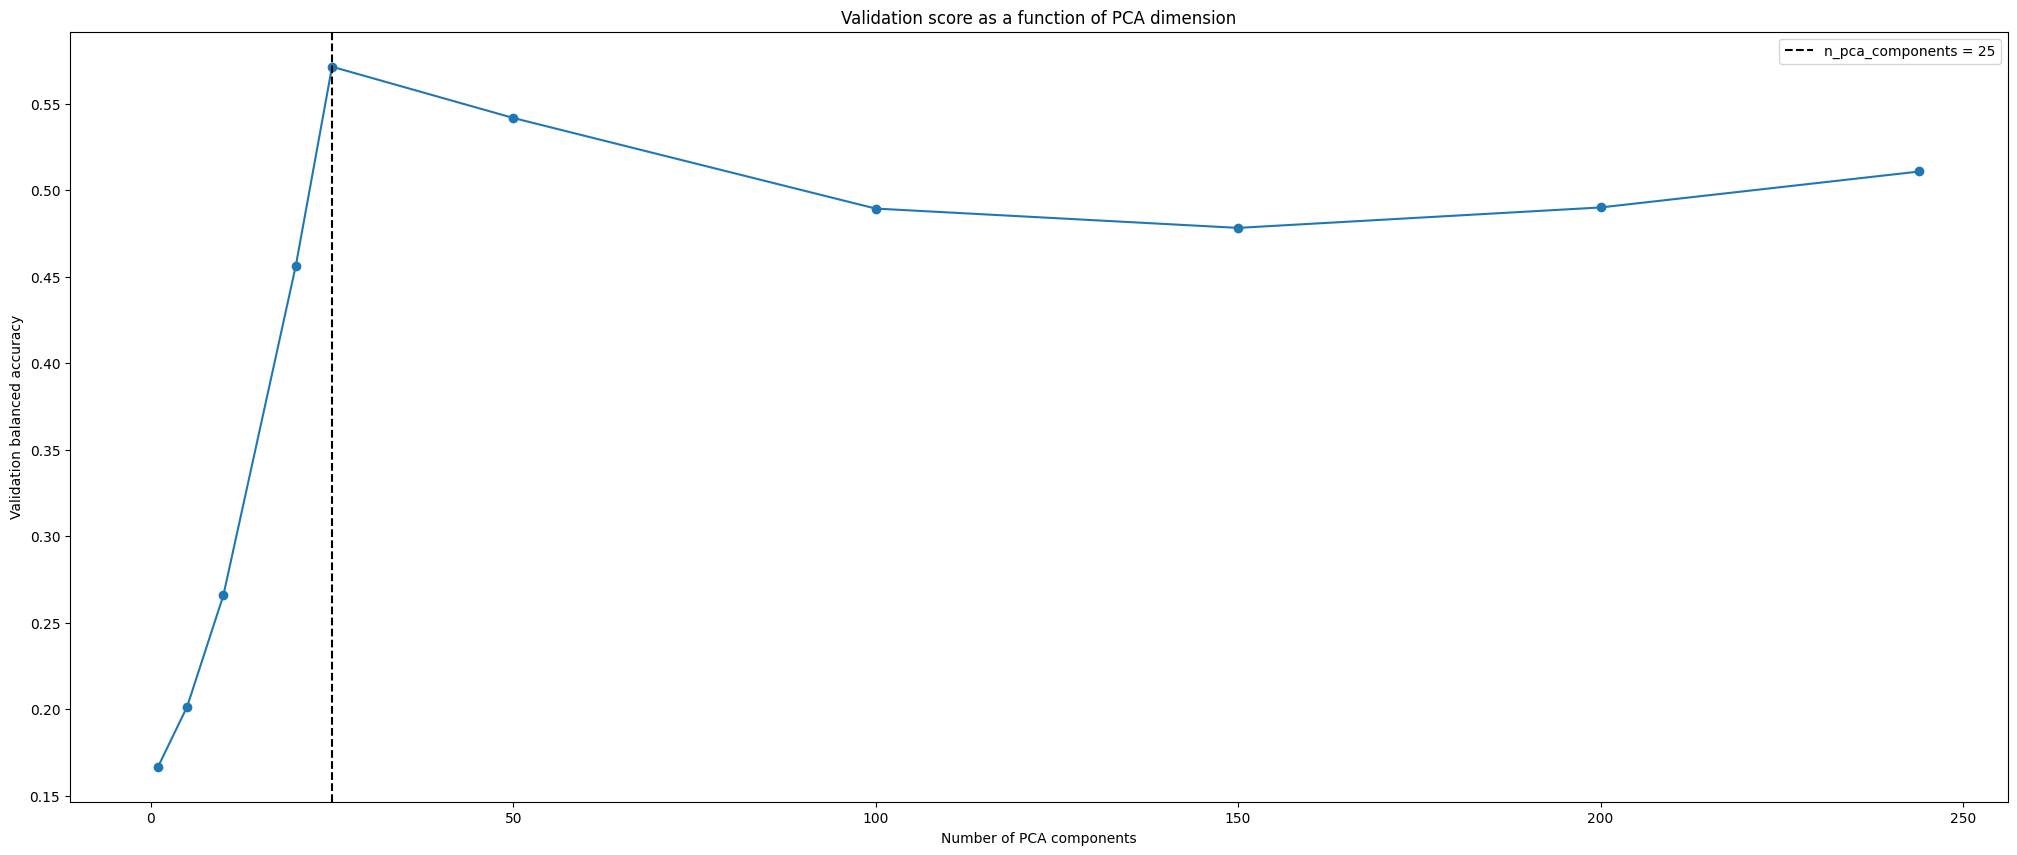

In [117]:
candidate_components = [1, 5, 10, 20, 25, 50, 100, 150, 200, 244]
max_components = min(X_train_shifted.shape[0], X_train_shifted.shape[1])
pca_grid = [n for n in candidate_components if n <= max_components]
pca_scores = []

for n_components in pca_grid:
    pca_candidate = PCA(n_components=n_components)
    X_train_pca_candidate = pca_candidate.fit_transform(X_train_shifted)
    X_val_pca_candidate = pca_candidate.transform(X_val_shifted)

    estimator_pca_candidate = LDA(**ESTIMATOR_KWARGS)
    estimator_pca_candidate.fit(X_train_pca_candidate, y_train_shifted)
    y_val_pred_candidate = estimator_pca_candidate.predict(X_val_pca_candidate)
    pca_scores.append(balanced_accuracy_score(y_val_shifted, y_val_pred_candidate))

n_pca_components = int(pca_grid[np.argmax(pca_scores)])
print(f'n_pca_components: {n_pca_components}')

plt.figure(figsize=FIGSIZE)
plt.plot(pca_grid, pca_scores, marker="o")
plt.axvline(n_pca_components, color="k", linestyle="--", label=f"n_pca_components = {n_pca_components}")
plt.xlabel("Number of PCA components")
plt.ylabel("Validation balanced accuracy")
plt.title("Validation score as a function of PCA dimension")
plt.legend()

pca = PCA(n_components=n_pca_components)
X_train_pca = pca.fit_transform(X_train_shifted)
X_val_pca = pca.transform(X_val_shifted)
X_test_pca = pca.transform(X_test_shifted)

estimator_pca = LDA(**ESTIMATOR_KWARGS)
estimator_pca.fit(X_train_pca, y_train_shifted)

y_val_pred_pca = estimator_pca.predict(X_val_pca)
y_test_pred_pca = estimator_pca.predict(X_test_pca)
y_test_proba_pca = estimator_pca.predict_proba(X_test_pca)

print_classification_metrics(
    'Validation metrics (temporal shift + PCA + LDA)',
    y_val_shifted,
    y_val_pred_pca,
    reference_labels=y_val_shifted,
)
print_classification_metrics(
    'Test metrics (temporal shift + PCA + LDA)',
    y_test_shifted,
    y_test_pred_pca,
    reference_labels=y_val_shifted,
)


## 1.6.5 Get A More Stable Output

A discrete decoder can be noisy from one prediction to the next. One simple trick is to smooth the class probabilities over time before taking the final `argmax`.

If `p_t` is the vector of class probabilities at time `t`, we compute a smoothed version

$$\tilde{p}_t = \sum_{\tau} w_{\tau} \, p_{t-\tau}$$

and then predict

$$\hat{y}_t = \arg\max_k \; \tilde{p}_{t,k}$$

Here we apply this idea to the probabilities produced by the `temporal shift + PCA + LDA` pipeline.


In [118]:
stable_win_size = 25
stable_win = np.expand_dims(np.hamming(stable_win_size), 1)

y_test_proba_stable = convolve(y_test_proba_pca, stable_win, 'same')
y_test_pred_stable = np.argmax(y_test_proba_stable, axis=1)

print_classification_metrics(
    'Test metrics (stable temporal shift + PCA + LDA + Smoothing)',
    y_test_shifted,
    y_test_pred_stable,
    reference_labels=y_val_shifted,
)


Test metrics (stable temporal shift + PCA + LDA + Smoothing)
  number of classes                  : 6
  chance level (validation set)    : 0.129 (always predict Finger 5)
  accuracy                           : 0.434
  balanced accuracy                  : 0.442
  macro F1                           : 0.415


### 1.7.1 Visualize Predictions Vs. Ground Truth
Let see visually how we improved our model

In [119]:
class_labels = [f'Finger {i + 1}' for i in range(n_fingers)] + ['Rest']

tp.plot_prediction_vs_truth(
    y_test[:len(y_test_pred_stable)],
    y_test_pred_stable,
    sample_rate=fs / hop_size,
    class_labels=class_labels,
    title='Prediction vs. ground truth using stable temporal shift + PCA + LDA + smoothing',
    predicted_label='Stable Model Prediction',
)


# Part 2: Continuous Decoding

We now reuse the ECoG preprocessing from **Part 0** to predict continuous finger trajectories.


## 2.1 Prepare The Continuous Labels

**What is finger flexion?** The label in this dataset is a measure of **finger flexion**: how much each finger is bent (curled) at each moment in time. Concretely, it is a normalised signal between 0 (finger fully extended / resting) and 1 (finger fully bent). Five fingers are tracked independently, giving a 5-dimensional output at each time step.

In this part, the continuous label is simply the original finger trajectory — we no longer threshold it into discrete classes. The goal is to reconstruct the shape of the movement itself, not just identify which finger moved.

We store it in `Y_train_position_full` for the training set and in `Y_test_position` for the test set.


In [120]:
Y_train_position_full = subject_data.train_fingers[::f_ratio]
Y_test_position = subject_data.test_fingers[::f_ratio]

print('X_train_features_full:', X_train_features_full.shape)
print('Y_train_position_full:', Y_train_position_full.shape)


X_train_features_full: (10000, 244)
Y_train_position_full: (10000, 5)


## 2.2 Split The Data

We keep the same temporal logic as before: the first part of the training signal is used for fitting, the second part for validation, and the original test set is kept for the final evaluation.


In [121]:
n_times_train_full = len(Y_train_position_full)
n_train = int(0.8 * n_times_train_full)
train_slice = slice(0, n_train)
val_slice = slice(n_train, n_times_train_full)

X_train = X_train_features_full[train_slice]
X_val = X_train_features_full[val_slice]

Y_train_position = Y_train_position_full[train_slice]
Y_val_position = Y_train_position_full[val_slice]

print('X_train:', X_train.shape)
print('X_val:', X_val.shape)
print('X_test:', X_test_full.shape)


X_train: (8000, 244)
X_val: (2000, 244)
X_test: (5000, 244)


## 2.3 Linear Regression

We start with a simple baseline: a multi-output `LinearRegression` trained on the original position label.

The model assumes a linear relationship between the features and the continuous target:

$$\hat{Y} = XW + b$$

where `X` is the feature matrix, `W` contains the regression coefficients, and `b` is the intercept.

The fitted coefficients are chosen to minimize the squared error:

$$\min_{W,b} \; ||Y - (XW + b)||_2^2$$


In [122]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error

linear_model = LinearRegression()
linear_model.fit(X_train, Y_train_position)

Y_val_pred_linear = linear_model.predict(X_val)
Y_test_pred_linear = linear_model.predict(X_test_full)


## 2.4 Regression Metrics

We use three standard metrics:

- `R2`: how much variance is explained by the model.

$$R^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}$$

A value close to `1` is good, `0` means that the model is not better than predicting the mean, and negative values mean that the model is worse than that simple baseline.

- `MSE`: the average squared error.

$$\text{MSE} = \frac{1}{N} \sum_i (y_i - \hat{y}_i)^2$$

Smaller values are better, and `0` would mean perfect predictions. Its absolute scale depends on the scale of the finger trajectories, so it is mostly useful for comparing models on the same task.

- `correlation`: how well the predicted trajectory follows the shape of the true trajectory.

$$\rho(y, \hat{y}) = \frac{\sum_i (y_i - \bar{y})(\hat{y}_i - \bar{\hat{y}})}{\sqrt{\sum_i (y_i - \bar{y})^2} \sqrt{\sum_i (\hat{y}_i - \bar{\hat{y}})^2}}$$

A value close to `1` is good, a value near `0` means little or no linear relationship, and a negative value means that the prediction tends to move in the opposite direction.

In practice, a good model should have high `R2`, low `MSE`, and high positive `correlation`.


In [123]:
def compute_regression_metrics(Y_true, Y_pred):
    r2_values = []
    mse_values = []
    corr_values = []
    for finger in range(Y_true.shape[1]):
        y_true_f = Y_true[:, finger]
        y_pred_f = Y_pred[:, finger]
        r2_values.append(r2_score(y_true_f, y_pred_f))
        mse_values.append(mean_squared_error(y_true_f, y_pred_f))
        if np.std(y_true_f) < 1e-12 or np.std(y_pred_f) < 1e-12:
            corr_values.append(0.0)
        else:
            corr_values.append(np.corrcoef(y_true_f, y_pred_f)[0, 1])
    return np.array(r2_values), np.array(mse_values), np.array(corr_values)

def print_regression_metrics(name, Y_true, Y_pred):
    r2_values, mse_values, corr_values = compute_regression_metrics(Y_true, Y_pred)
    print(name)
    print(f'  mean R2          : {r2_values.mean():.3f}')
    print(f'  mean MSE         : {mse_values.mean():.3f}')
    print(f'  mean correlation : {corr_values.mean():.3f}')
    print()
    for finger in range(Y_true.shape[1]):
        print(f'  finger {finger + 1}: R2={r2_values[finger]:.3f}, MSE={mse_values[finger]:.3f}, corr={corr_values[finger]:.3f}')

print_regression_metrics('Validation metrics (Linear Regression)', Y_val_position, Y_val_pred_linear)
print_regression_metrics('Test metrics (Linear Regression)', Y_test_position, Y_test_pred_linear)


Validation metrics (Linear Regression)
  mean R2          : -0.168
  mean MSE         : 0.966
  mean correlation : 0.350

  finger 1: R2=0.099, MSE=0.763, corr=0.405
  finger 2: R2=0.126, MSE=0.543, corr=0.572
  finger 3: R2=-0.815, MSE=1.443, corr=0.001
  finger 4: R2=-0.192, MSE=0.970, corr=0.444
  finger 5: R2=-0.056, MSE=1.113, corr=0.329
Test metrics (Linear Regression)
  mean R2          : -0.396
  mean MSE         : 1.190
  mean correlation : 0.321

  finger 1: R2=0.170, MSE=1.311, corr=0.413
  finger 2: R2=-0.123, MSE=0.737, corr=0.605
  finger 3: R2=-1.129, MSE=1.347, corr=0.048
  finger 4: R2=-0.425, MSE=1.391, corr=0.334
  finger 5: R2=-0.476, MSE=1.164, corr=0.204


## 2.5 Ridge Regression

We now add an `L2` regularization term with `Ridge`.

### Why regularize?

In this problem we have many features (61 channels × 4 bands = 244) but the relationship between ECoG and finger movement may only use a fraction of them. Plain linear regression can be "greedy": it fits the training data perfectly by giving large weights to features that are only accidentally correlated with the target in that particular training set (this is called **overfitting**). On unseen test data, these large weights hurt performance.

Ridge regression fixes this by adding a **penalty on the size of the weights**. Large weights become costly, so the model is forced to spread the information across many small weights rather than concentrating it on a few accidental ones. This generally improves generalisation.

Here, we start with a fixed value `ridge_alpha = 10000.0` as a simple baseline, before the per-finger hyperparameter search introduced later.

Ridge keeps the same linear model

$$\hat{Y} = XW + b$$

but changes the objective function by penalizing large coefficients:

$$\min_{W,b} \; ||Y - (XW + b)||_2^2 + \alpha ||W||_2^2$$

The parameter `alpha` controls the strength of the regularization:
- `alpha = 0` → pure linear regression, no penalty
- large `alpha` → weights are strongly pushed toward zero; the model becomes more conservative

Choosing `alpha` is a tuning problem — we try several values and pick the one that performs best on the validation set.


In [124]:
ridge_alpha = 10000.0
ridge_model = Ridge(alpha=ridge_alpha)
ridge_model.fit(X_train, Y_train_position)

Y_val_pred_ridge = ridge_model.predict(X_val)
Y_test_pred_ridge = ridge_model.predict(X_test_full)

print_regression_metrics('Validation metrics (Ridge)', Y_val_position, Y_val_pred_ridge)
print_regression_metrics('Test metrics (Ridge)', Y_test_position, Y_test_pred_ridge)


Validation metrics (Ridge)
  mean R2          : 0.038
  mean MSE         : 0.796
  mean correlation : 0.370

  finger 1: R2=0.123, MSE=0.743, corr=0.433
  finger 2: R2=0.121, MSE=0.546, corr=0.450
  finger 3: R2=-0.086, MSE=0.864, corr=-0.002
  finger 4: R2=-0.030, MSE=0.837, corr=0.564
  finger 5: R2=0.060, MSE=0.990, corr=0.407
Test metrics (Ridge)
  mean R2          : -0.065
  mean MSE         : 0.956
  mean correlation : 0.384

  finger 1: R2=0.180, MSE=1.297, corr=0.555
  finger 2: R2=-0.059, MSE=0.695, corr=0.539
  finger 3: R2=-0.129, MSE=0.714, corr=0.179
  finger 4: R2=-0.307, MSE=1.276, corr=0.401
  finger 5: R2=-0.012, MSE=0.798, corr=0.246


### Visualize Ridge Metrics And Predictions

We compare `Linear Regression` and `Ridge` finger by finger, then we plot the predicted and true trajectories on a short segment of the test set.


Text(0.5, 0.98, 'Ridge predictions vs ground truth on a short test segment')

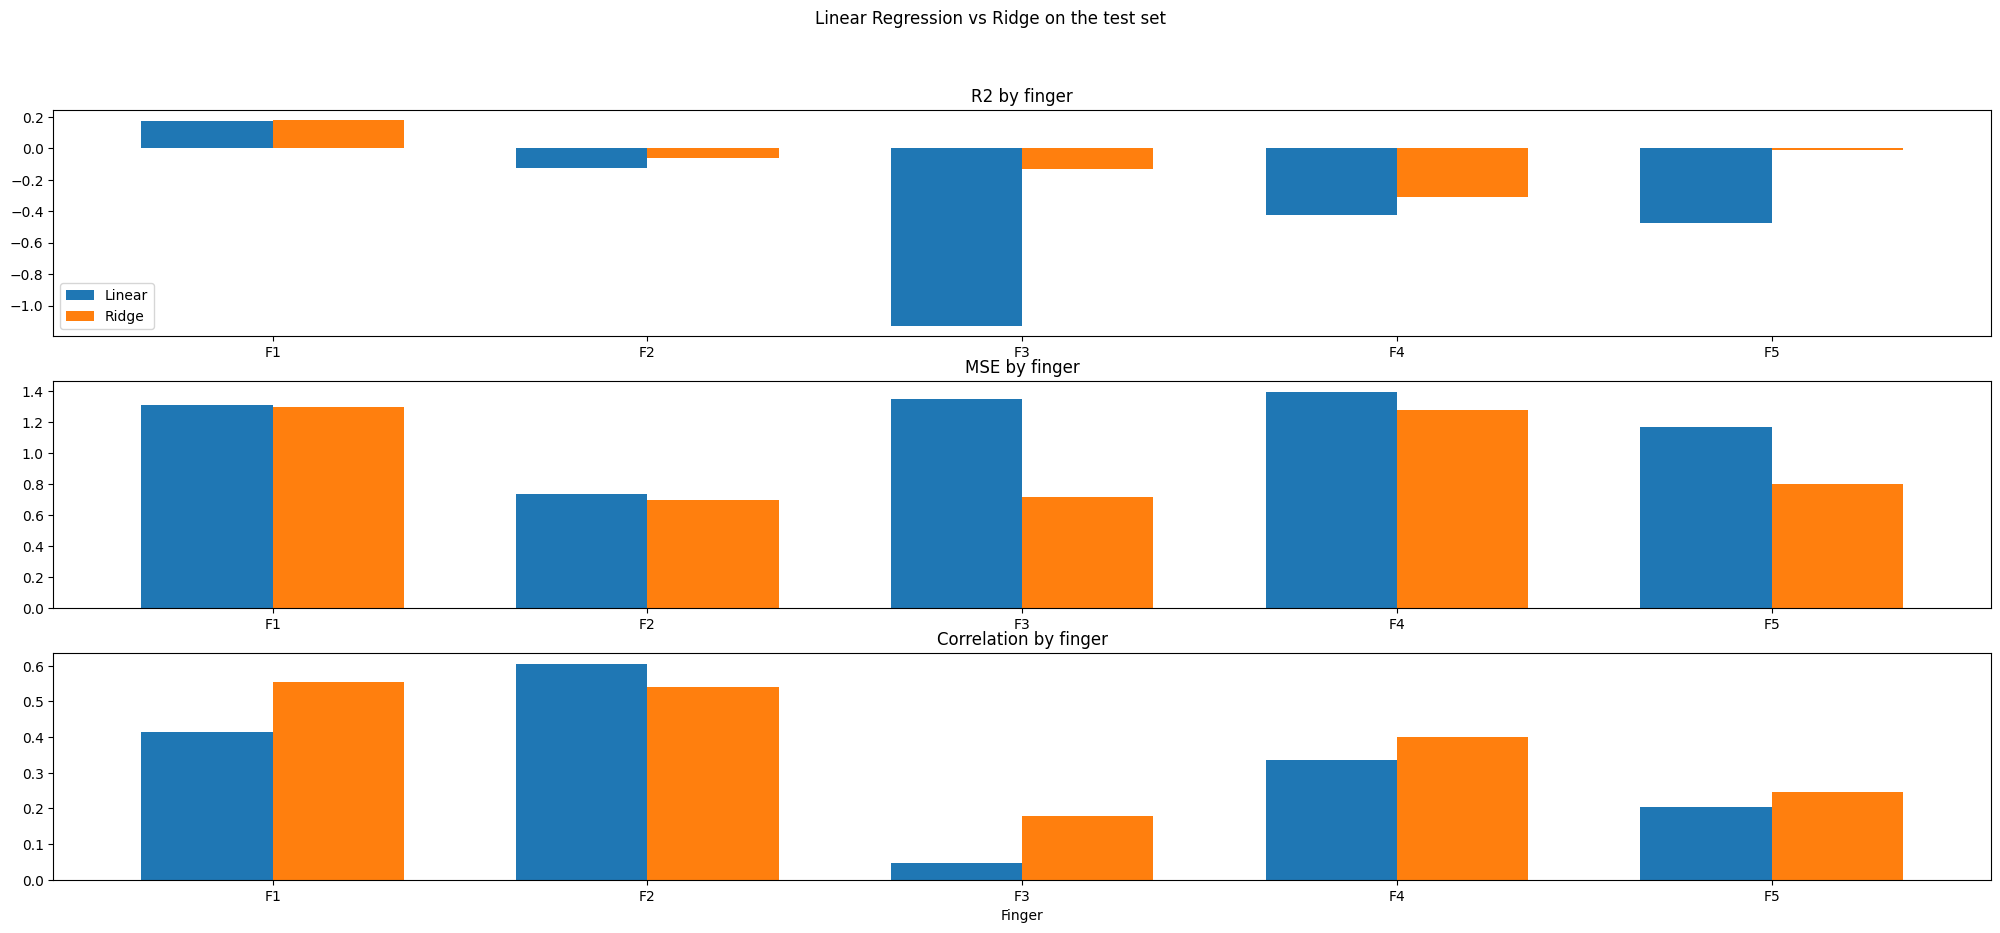

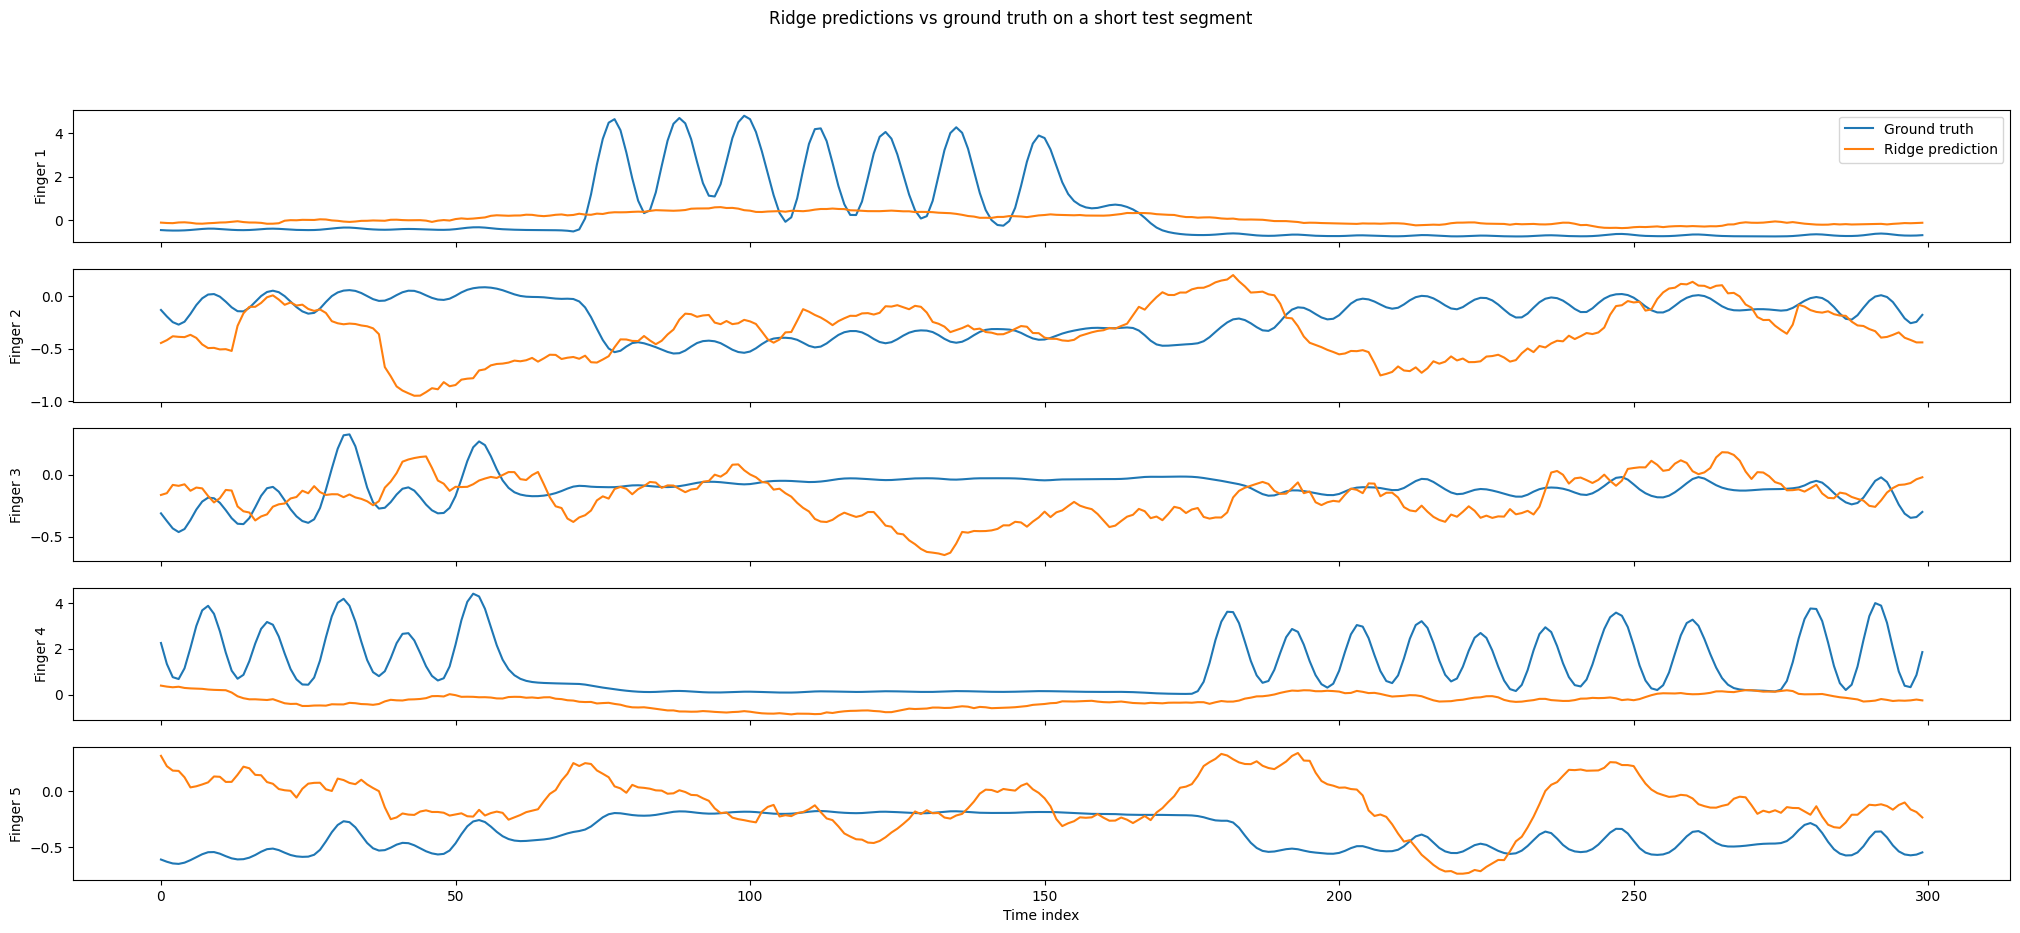

In [125]:
linear_r2, linear_mse, linear_corr = compute_regression_metrics(Y_test_position, Y_test_pred_linear)
ridge_r2, ridge_mse, ridge_corr = compute_regression_metrics(Y_test_position, Y_test_pred_ridge)
fingers = np.arange(n_fingers)
bar_width = 0.35

fig = plt.figure(figsize=FIGSIZE)
ax = fig.subplots(3, 1)
ax[0].bar(fingers - bar_width / 2, linear_r2, width=bar_width, label='Linear')
ax[0].bar(fingers + bar_width / 2, ridge_r2, width=bar_width, label='Ridge')
ax[0].set_title('R2 by finger')
ax[0].set_xticks(fingers, [f'F{i + 1}' for i in fingers])
ax[0].legend()

ax[1].bar(fingers - bar_width / 2, linear_mse, width=bar_width, label='Linear')
ax[1].bar(fingers + bar_width / 2, ridge_mse, width=bar_width, label='Ridge')
ax[1].set_title('MSE by finger')
ax[1].set_xticks(fingers, [f'F{i + 1}' for i in fingers])

ax[2].bar(fingers - bar_width / 2, linear_corr, width=bar_width, label='Linear')
ax[2].bar(fingers + bar_width / 2, ridge_corr, width=bar_width, label='Ridge')
ax[2].set_title('Correlation by finger')
ax[2].set_xticks(fingers, [f'F{i + 1}' for i in fingers])
ax[2].set_xlabel('Finger')

fig.suptitle('Linear Regression vs Ridge on the test set')

start_time = 100
end_time = min(400, len(Y_test_position))

fig = plt.figure(figsize=FIGSIZE)
ax = fig.subplots(n_fingers, 1, sharex=True)
for finger in range(n_fingers):
    ax[finger].plot(Y_test_position[start_time:end_time, finger], label='Ground truth')
    ax[finger].plot(Y_test_pred_ridge[start_time:end_time, finger], label='Ridge prediction')
    ax[finger].set_ylabel(f'Finger {finger + 1}')
ax[0].legend(loc='upper right')
ax[-1].set_xlabel('Time index')
fig.suptitle('Ridge predictions vs ground truth on a short test segment')


## 2.6 Advanced: Find The Best Temporal Shift And Alpha For Each Finger

**Why treat each finger independently?**

Different fingers are controlled by different regions of the motor cortex, and the ECoG electrodes are positioned over specific cortical areas. As a result:
- The **temporal shift** may differ per finger: the neural activity predicting index finger movement may lead the movement by a different amount than the activity predicting ring finger movement.
- The **optimal regularization** may differ: fingers that are harder to decode from the available channels may need a stronger regularization to avoid overfitting.

By optimizing independently for each finger, we can squeeze out better performance for each output channel.

For each finger, we still use the same Ridge model

$$\hat{y} = Xw + b$$

with the Ridge objective

$$\min_{w,b} \; ||y - (Xw + b)||_2^2 + \alpha ||w||_2^2$$

but we now test several values in `shift_grid` and `alpha_grid` on the validation set, independently for each finger.

We then keep the pair `(best_shift, best_alpha)` that gives the highest validation correlation.


In [126]:
shift_grid = np.arange(-10, 11)
alpha_grid = np.logspace(-4, 4, 9)

best_shifts_per_finger = np.zeros(n_fingers, dtype=int)
best_alphas_per_finger = np.zeros(n_fingers, dtype=float)
best_val_corr_per_finger = np.zeros(n_fingers, dtype=float)

for finger in range(n_fingers):
    best_score = -np.inf

    for shift in shift_grid:
        y_train_shifted_finger = tp.lag(Y_train_position[:, finger], shift)
        y_val_shifted_finger = tp.lag(Y_val_position[:, finger], shift)

        for alpha in alpha_grid:
            model = Ridge(alpha=float(alpha))
            model.fit(X_train, y_train_shifted_finger)
            y_val_pred_finger = model.predict(X_val)

            if np.std(y_val_shifted_finger) < 1e-12 or np.std(y_val_pred_finger) < 1e-12:
                score = 0.0
            else:
                score = np.corrcoef(y_val_shifted_finger, y_val_pred_finger)[0, 1]

            if score > best_score:
                best_score = score
                best_shifts_per_finger[finger] = int(shift)
                best_alphas_per_finger[finger] = float(alpha)
                best_val_corr_per_finger[finger] = float(score)

Y_test_position_tuned = np.zeros_like(Y_test_position)
Y_test_position_target_tuned = np.zeros_like(Y_test_position)

for finger in range(n_fingers):
    best_shift = int(best_shifts_per_finger[finger])
    best_alpha = float(best_alphas_per_finger[finger])

    y_train_full_shifted_finger = tp.lag(Y_train_position_full[:, finger], best_shift)
    y_test_shifted_finger = tp.lag(Y_test_position[:, finger], best_shift)

    tuned_model = Ridge(alpha=best_alpha)
    tuned_model.fit(X_train_features_full, y_train_full_shifted_finger)
    Y_test_position_tuned[:, finger] = tuned_model.predict(X_test_full)
    Y_test_position_target_tuned[:, finger] = y_test_shifted_finger

print('best_shifts_per_finger:', best_shifts_per_finger)
print('best_alphas_per_finger:', best_alphas_per_finger)
print('best_val_corr_per_finger:', np.round(best_val_corr_per_finger, 3))
print_regression_metrics('Test metrics (tuned Ridge)', Y_test_position_target_tuned, Y_test_position_tuned)


best_shifts_per_finger: [10  1 10  0  0]
best_alphas_per_finger: [1.e+03 1.e+00 1.e+04 1.e+04 1.e+04]
best_val_corr_per_finger: [0.513 0.588 0.063 0.564 0.407]
Test metrics (tuned Ridge)
  mean R2          : 0.057
  mean MSE         : 0.841
  mean correlation : 0.454

  finger 1: R2=0.273, MSE=1.135, corr=0.566
  finger 2: R2=0.092, MSE=0.595, corr=0.669
  finger 3: R2=-0.037, MSE=0.655, corr=0.286
  finger 4: R2=-0.111, MSE=1.084, corr=0.439
  finger 5: R2=0.068, MSE=0.735, corr=0.308


Text(0.5, 0.98, 'Tuned Ridge predictions vs ground truth on the test set')

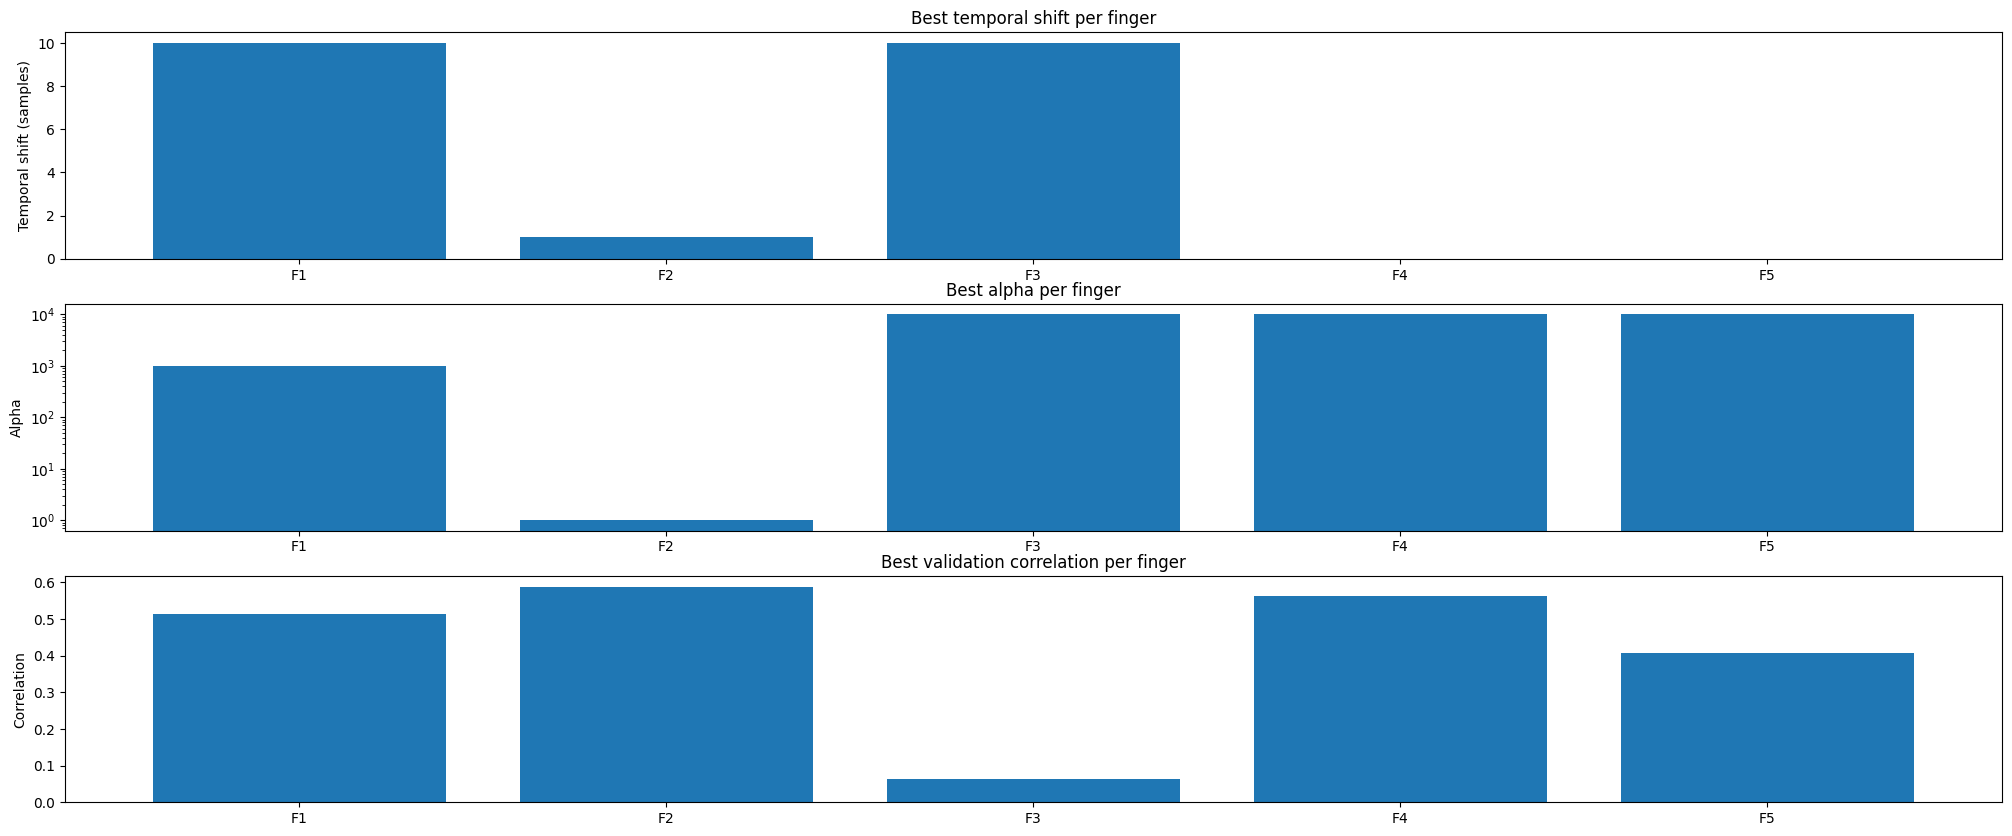

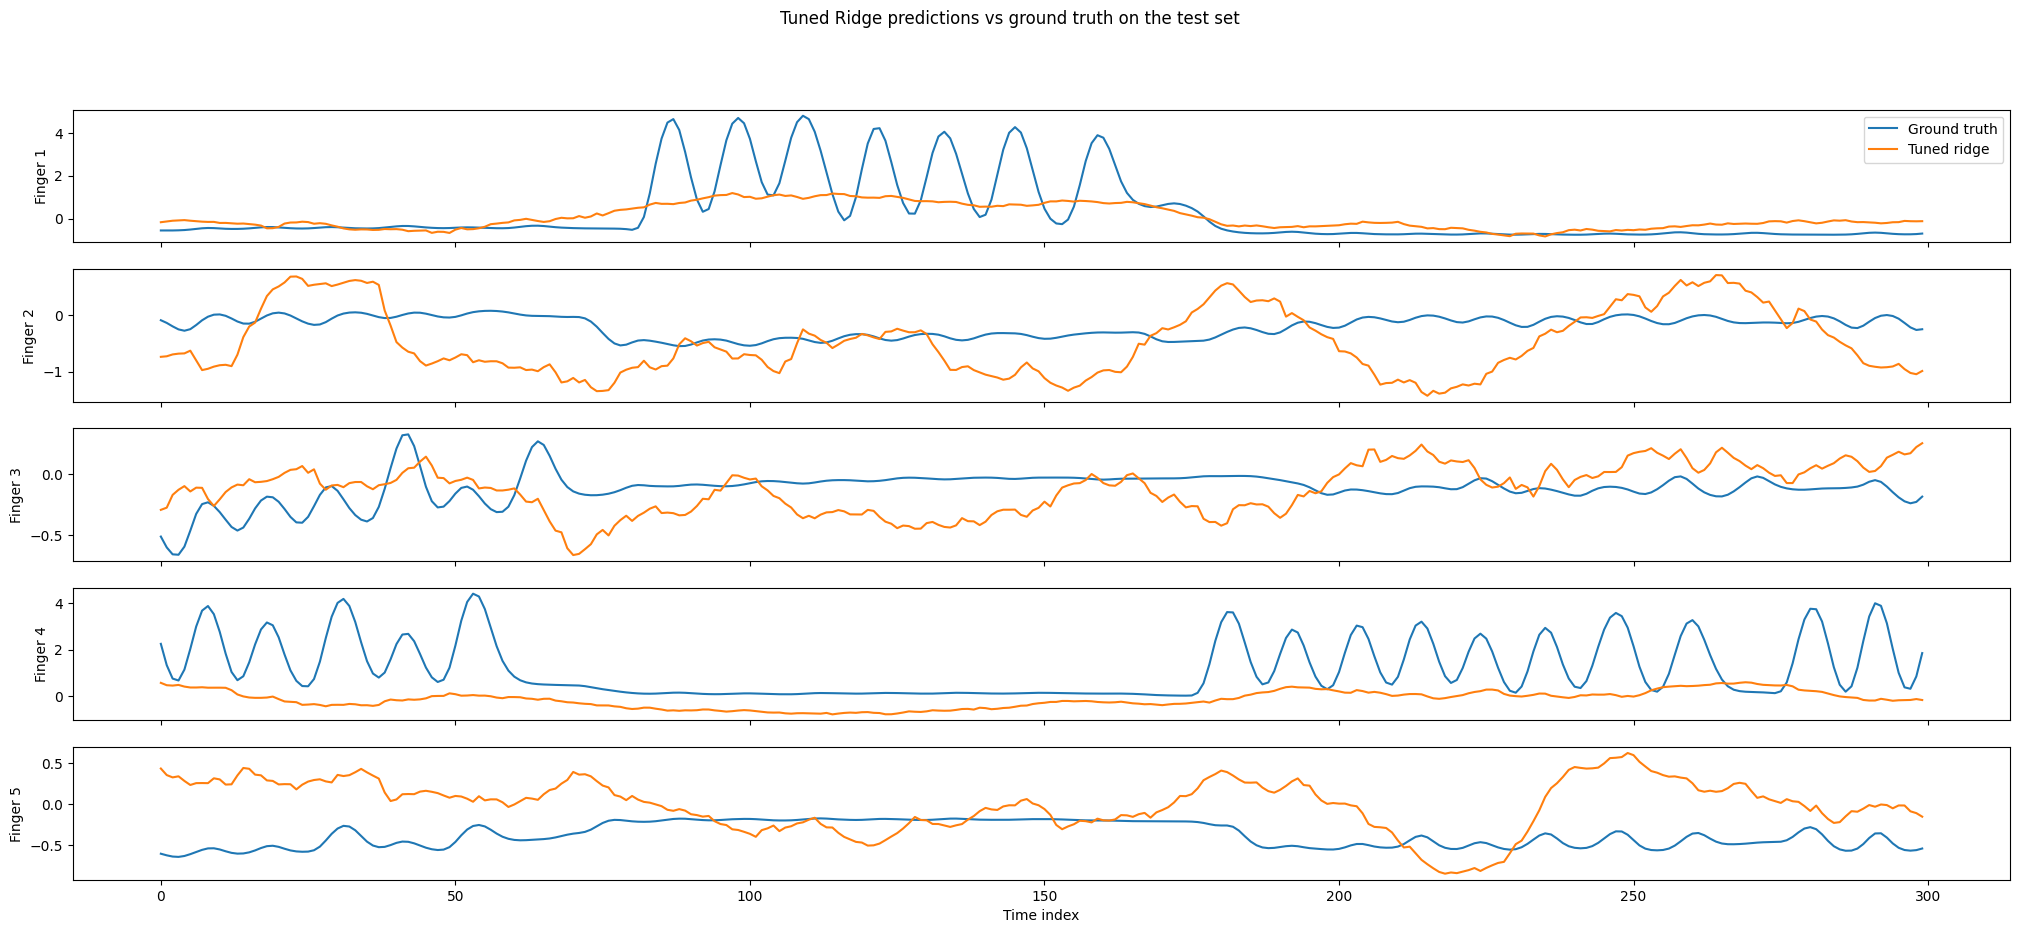

In [127]:
fig = plt.figure(figsize=FIGSIZE)
ax = fig.subplots(3, 1)
fingers = np.arange(n_fingers)

ax[0].bar(fingers, best_shifts_per_finger)
ax[0].set_title('Best temporal shift per finger')
ax[0].set_xticks(fingers, [f'F{i + 1}' for i in fingers])
ax[0].set_ylabel('Temporal shift (samples)')

ax[1].bar(fingers, best_alphas_per_finger)
ax[1].set_title('Best alpha per finger')
ax[1].set_xticks(fingers, [f'F{i + 1}' for i in fingers])
ax[1].set_ylabel('Alpha')
ax[1].set_yscale('log')

ax[2].bar(fingers, best_val_corr_per_finger)
ax[2].set_title('Best validation correlation per finger')
ax[2].set_xticks(fingers, [f'F{i + 1}' for i in fingers])
ax[2].set_ylabel('Correlation')

start_time = 100
end_time = min(400, len(Y_test_position_tuned))

fig = plt.figure(figsize=FIGSIZE)
ax = fig.subplots(n_fingers, 1, sharex=True)
for finger in range(n_fingers):
    ax[finger].plot(Y_test_position_target_tuned[start_time:end_time, finger], label='Ground truth')
    ax[finger].plot(Y_test_position_tuned[start_time:end_time, finger], label='Tuned ridge')
    ax[finger].set_ylabel(f'Finger {finger + 1}')
ax[0].legend(loc='upper right')
ax[-1].set_xlabel('Time index')
fig.suptitle('Tuned Ridge predictions vs ground truth on the test set')


# Part 3: DNN For Discrete Decoding

In this part we build deep models step by step for the same discrete task.

Pedagogical order:

1. temporal windows for sequence prediction;
2. Big Picture: What Happens During Deep Learning Training?
3. MLP (Multi Layer Perceptron)
4. CNN (Convolution Neural Network)
5. RNN (Recurrent Neural Network)
6. Transformer And Attention 
7. Compare All Models
8. Visualize Best DNN Prediction Vs Ground Truth


## 3.1 Temporal Window Setup

As before, labels are discrete classes. But now each prediction uses a **time window**:

$$
\hat{y}_t = f(x_{t-W+1}, x_{t-W+2}, \dots, x_t)
$$

where `W` is the window length.

At 25 Hz, `W = 5` means `5/25 = 0.2 s`  of context.



In [128]:
# Window size in number of feature samples (features are at 25 Hz)
dnn_window_size = 5


def build_temporal_windows(X, y, window_size):
    """
    Build windows so each target y_t uses [t-window_size+1, ..., t].
    """
    X_windows = np.stack(
        [X[t - window_size + 1:t + 1] for t in range(window_size - 1, X.shape[0])],
        axis=0,
    )
    y_windows = y[window_size - 1:]
    return X_windows, y_windows


X_train_win, y_train_win = build_temporal_windows(X_train, y_train, dnn_window_size)
X_val_win, y_val_win = build_temporal_windows(X_val, y_val, dnn_window_size)
X_test_win, y_test_win = build_temporal_windows(X_test, y_test, dnn_window_size)

n_features_dnn = X_train_win.shape[-1]
n_classes_dnn = int(np.max(y_train_win) + 1)

print(f'dnn_window_size: {dnn_window_size} samples ({dnn_window_size / 25:.2f} s)')
print('X_train_win:', X_train_win.shape)
print('X_val_win  :', X_val_win.shape)
print('X_test_win :', X_test_win.shape)
print('n_features_dnn:', n_features_dnn)
print('n_classes_dnn :', n_classes_dnn)



dnn_window_size: 5 samples (0.20 s)
X_train_win: (7996, 5, 244)
X_val_win  : (1996, 5, 244)
X_test_win : (4996, 5, 244)
n_features_dnn: 244
n_classes_dnn : 6


## 3.2 Big Picture: What Happens During Deep Learning Training?

Let us make the training process very concrete.

Deep learning training is essentially **repeating a simple algorithm many times** on small chunks of the dataset.

To keep the intuition clear, we use a tiny toy example below. The exact numbers do not matter: the goal is only to see what PyTorch manipulates at each step.


In [129]:
# Small illustration 1: a tiny toy dataset
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(0)

X_demo = torch.tensor(
    [
        [[0.1, 0.0], [0.2, 0.1], [0.3, 0.0]],
        [[1.0, 0.9], [1.1, 1.0], [1.2, 1.1]],
        [[0.0, 0.4], [0.1, 0.5], [0.0, 0.6]],
        [[0.9, 0.2], [1.0, 0.1], [1.1, 0.0]],
        [[0.2, 1.0], [0.3, 1.1], [0.4, 1.2]],
        [[1.2, 0.3], [1.3, 0.2], [1.4, 0.1]],
    ],
    dtype=torch.float32,
)
y_demo = torch.tensor([0, 1, 2, 0, 2, 1], dtype=torch.long)

print('X_demo shape:', tuple(X_demo.shape))
print('y_demo shape:', tuple(y_demo.shape))
print('first target labels:', y_demo.tolist())
print('first sample shape:', tuple(X_demo[0].shape))


X_demo shape: (6, 3, 2)
y_demo shape: (6,)
first target labels: [0, 1, 2, 0, 2, 1]
first sample shape: (3, 2)


### 3.2.3 Dataset And Mini-Batches

Suppose we collected a dataset of neural recordings.

Each example contains:

- an **input** `X` -> one neural signal window
- a **target** `y` -> the class we want to predict

Example:

| sample | input (X) | target (y) |
|------|------|------|
| 1 | neural signal window | finger 1 |
| 2 | neural signal window | rest |
| 3 | neural signal window | finger 3 |

If we stack everything together:

```
X_train_win = [X1, X2, X3, ..., XN]
y_train_win = [y1, y2, y3, ..., yN]
```

This full collection is called the **training dataset**.

In theory we could process all samples at once, but in practice this is usually a bad idea because:

- datasets are too large
- GPUs have limited memory
- smaller updates often help optimization

So we split the dataset into **small groups of samples**. These groups are called **mini-batches**.

If the dataset contains **10,000 samples** and the batch size is **32**:

```
mini-batch 1 = samples 1 -> 32
mini-batch 2 = samples 33 -> 64
mini-batch 3 = samples 65 -> 96
...
```

Each mini-batch contains:

```
X_batch = [X_i, X_{i+1}, ..., X_{i+B-1}]
y_batch = [y_i, y_{i+1}, ..., y_{i+B-1}]
```

where **B = batch size**.

In PyTorch, mini-batches are usually **produced by a `DataLoader`**, which returns one pair `(X_batch, y_batch)` at a time.

For our temporal windows in this notebook, this usually looks like:

```
X_batch.shape = (batch_size, window_size, n_features)
y_batch.shape = (batch_size,)
```

One **epoch** simply means that the model has seen all training mini-batches once.


In [130]:
loader_demo = DataLoader(TensorDataset(X_demo, y_demo), batch_size=4, shuffle=False)
X_batch, y_batch = next(iter(loader_demo))

print('number of samples in dataset:', len(X_demo))
print('number of mini-batches per epoch:', len(loader_demo))
print('X_batch shape:', tuple(X_batch.shape)) #(4, 3, 2) batch_size, time, features
print('y_batch:', y_batch.tolist())


number of samples in dataset: 6
number of mini-batches per epoch: 2
X_batch shape: (4, 3, 2)
y_batch: [0, 1, 2, 0]


### 3.2.4 Stochastic Gradient Descent Algorithm

Before running the stochastic gradient descent algorithm, we first define several objects:

1. the **dataset / DataLoader**, which provides the mini-batches `(X_batch, y_batch)`
2. the **model** $f_{\theta}$, with learnable parameters `theta` 
3. the **loss function** `criterion`, which measures the prediction error
4. the **optimizer** (`SGD`, `Adam`, ...), which updates the parameters

Then, for one mini-batch `(X_batch, y_batch)`, we repeat the following steps.


In [131]:
nb_classes_demo = 3
model_demo = nn.Sequential(
    nn.Flatten(),  # from (batch_size, time, features) to (batch_size, time * features)
    nn.Linear(
        X_demo.shape[1] * X_demo.shape[2], nb_classes_demo
    ),  # Apply a linear transformation to get nb_classes_demo output values (one per class)
)
criterion_demo = (
    nn.CrossEntropyLoss()
)  # Function that will compute the loss between the model predictions and the true labels
optimizer_demo = torch.optim.SGD(
    model_demo.parameters(), lr=0.1
)  # Optimizer that will update the model parameters using the gradients computed from the criterion.

print("model:", model_demo)
print("loss:", criterion_demo.__class__.__name__)
print("optimizer:", optimizer_demo.__class__.__name__)

model: Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=6, out_features=3, bias=True)
)
loss: CrossEntropyLoss
optimizer: SGD


#### 1. Forward pass (prediction)

The model processes the input.

$$
\hat{y} = f_{\theta}(X_{\text{batch}})
$$

This produces predictions for every sample in the batch.

In [132]:
# logits are the raw outputs of the model.
logits_batch = model_demo(X_batch)

print("logits shape:", tuple(logits_batch.shape))
print("first sample logits:", logits_batch[0].detach())

logits shape: (4, 3)
first sample logits: tensor([ 0.0918,  0.1857, -0.1271])


#### 2. Loss computation

We compare predictions and targets.

$$
L = \mathrm{criterion}(\hat{y}, y_{\text{batch}})
$$

The loss is a **single number** measuring how wrong the predictions are.


In [133]:
loss_demo = criterion_demo(logits_batch, y_batch)

print('loss value:', float(loss_demo.detach()))

loss value: 1.2062060832977295


#### 3. Gradient computation

```
L.backward()
```

PyTorch automatically computes:

$$
\frac{\partial L}{\partial \theta}
$$

These gradients tell us **how each parameter should change to reduce the loss**.


In [134]:
#  backward pass computes gradients
optimizer_demo.zero_grad() # always zero gradients before backward pass, otherwise they accumulate
logits_batch = model_demo(X_batch) 
loss_demo = criterion_demo(logits_batch, y_batch)
loss_demo.backward() # HERE we compute the gradients of the LOSS with respect to the model parameters

print('gradient shape:', tuple(model_demo[1].weight.grad.shape))
print('mean absolute gradient:', float(model_demo[1].weight.grad.abs().mean()))


gradient shape: (3, 6)
mean absolute gradient: 0.1048341691493988


#### 4. Parameter update

```
optimizer.step()
```

The optimizer updates model parameters:

$$
\theta \leftarrow \theta - \eta \nabla_\theta L
$$

where `eta` is the learning rate.


In [135]:
old_weight = model_demo[1].weight.detach().clone() #just a checkpoint to see how the weights change after the optimization step

optimizer_demo.zero_grad()
logits_batch = model_demo(X_batch)
loss_demo = criterion_demo(logits_batch, y_batch)
loss_demo.backward()
optimizer_demo.step() # HERE we update the model parameters

new_weight = model_demo[1].weight.detach()
print('mean absolute parameter update:', float((new_weight - old_weight).abs().mean()))


mean absolute parameter update: 0.010483416728675365


#### 5. Gradient reset

```
optimizer.zero_grad()
```

Gradients are accumulated in PyTorch by default: if you call `.backward()` twice without resetting, the second gradients are **added** to the first ones. This is almost never what you want during standard training.

> **Timing note:** In a real training loop, `zero_grad()` is typically called **at the start of each iteration** (before the forward pass), not at the end. The order shown here (reset after update) is equivalent — it clears gradients for the *next* mini-batch — but many codebases zero the gradients first thing. Both work; what matters is that gradients are zeroed once per mini-batch.

The standard loop pattern you will see in the helpers below is:
```python
optimizer.zero_grad()   # 0. clear old gradients
y_hat = model(X_batch)  # 1. forward pass
loss  = criterion(y_hat, y_batch)  # 2. compute loss
loss.backward()         # 3. compute gradients
optimizer.step()        # 4. update weights
```


In [136]:
# Small illustration 8: zero_grad clears old gradients
optimizer_demo.zero_grad()
print('gradient after reset:', model_demo[1].weight.grad)

gradient after reset: None


### 3.2.5 Cheat Sheet (Vocabulary)

- **Sample**: one training example.
- **Dataset**: the full collection of samples.
- **DataLoader**: the PyTorch object that outputs mini-batches.
- **Mini-batch**: a small group of samples returned by a DataLoader.
- **Epoch**: one full pass over all mini-batches in the training set.
- **Logits**: raw scores produced by the network before softmax.
- **Model parameters**: weights and biases to learn.
- **Forward pass**: compute predictions from inputs.
- **Loss**: numeric error between predictions and targets.
- **Backward pass**: compute gradients of the loss with respect to the parameters.
- **Gradient**: direction and magnitude used to update a parameter.
- **Optimizer step**: update parameters with the gradients.
- **Learning rate**: step size of each parameter update.
- **Validation set**: used for tuning and model selection.
- **Test set**: used once for the final unbiased evaluation.


### 3.2.6 Helpers Used Below

We already saw the basic algorithmic ingredients of this DNN pipeline above. For the convenience of the TP, this training algorithm and all the boilerplate code are now refactorized in `tp/dnn.py`.

The next cells expose the functions that will be useful in the rest of Part 3 and in the advanced section:

1. `WindowDataset`: wraps temporal windows and labels into a PyTorch dataset.
2. `make_training_context(...)`: builds the loaders, class weights, and shared bookkeeping state.
3. `make_optimizer(...)`: chooses the optimization rule (`SGD`, `Adam`, `AdamW`, `RMSprop`, ...).
4. `evaluate_loader(...)`: computes loss and classification metrics on one loader.
5. `predict_labels(...)` and `predict_probabilities(...)`: extract predictions from a trained model.
6. `train_model(...)`: runs the epoch loop and keeps the best validation model.
7. `train_and_record(...)`: trains one architecture, stores its validation/test metrics, and plots its learning curves.
8. `plot_dnn_learning_curves(...)`: visualizes the train/validation evolution.



We will reuse this shared module below, including in the advanced tokenisation section.

Note (Model checkpoint):

In `train_and_record`, the model with the best `f1 score` on the validation set is saved for evaluation on the test set.


In [137]:
import math

import torch
import torch.nn as nn

SEED = 5
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print('device:', device)


BASE_BATCH_SIZE = 128
BASE_EPOCHS = 50
BASE_LR = 2e-5
BASE_WEIGHT_DECAY = 1e-3
BASE_OPTIMIZER_NAME = 'adamw'

WindowDataset = tp.WindowDataset
make_training_context = tp.make_training_context
make_optimizer = tp.make_optimizer
plot_dnn_learning_curves = tp.plot_dnn_learning_curves
predict_labels = tp.predict_labels
predict_probabilities = tp.predict_probabilities
evaluate_loader = tp.evaluate_loader
build_class_weights_torch = tp.build_class_weights_torch
train_model = tp.train_model
train_and_record = tp.train_and_record

dnn_context = tp.make_training_context(
    X_train_win,
    y_train_win,
    X_val_win,
    y_val_win,
    X_test_win,
    y_test_win,
    batch_size=BASE_BATCH_SIZE,
    n_classes=n_classes_dnn,
    device=device,
    seed=SEED,
)

train_loader = dnn_context.train_loader
val_loader = dnn_context.val_loader
test_loader = dnn_context.test_loader
class_counts = dnn_context.class_counts
class_weights = dnn_context.class_weights
class_weights_torch = dnn_context.class_weights_torch
dnn_results = dnn_context.results
dnn_histories = dnn_context.histories
trained_dnn_models = dnn_context.trained_models


print('train batches:', len(train_loader))
print('val batches  :', len(val_loader))
print('test batches :', len(test_loader))
print('class_counts :', class_counts)
print('class_weights:', np.round(class_weights, 3))
print(
    'tuned defaults:',
    {
        'optimizer': BASE_OPTIMIZER_NAME,
        'lr': BASE_LR,
        'batch_size': BASE_BATCH_SIZE,
        'weight_decay': BASE_WEIGHT_DECAY,
    },
)


device: mps
train batches: 63
val batches  : 16
test batches : 40
class_counts : [ 885 1154 1400  847 1193 2517]
class_weights: [1.506 1.155 0.952 1.573 1.117 0.529]
tuned defaults: {'optimizer': 'adamw', 'lr': 2e-05, 'batch_size': 128, 'weight_decay': 0.001}


## 3.3 MLP (Multi Layer Perceptron)

We start with an MLP baseline.

A **linear layer** applies:

$$
z = W x + b
$$

It mixes the input features with learnable weights and biases.

An **activation layer** introduces non-linearity. For ReLU:

$$
\mathrm{ReLU}(u) = \max(0, u)
$$

Without activation, stacking several linear layers would still behave like a single linear transformation.

A 2-layer MLP can be written:

$$
h_1 = \mathrm{ReLU}(W_1 x + b_1), \quad h_2 = \mathrm{ReLU}(W_2 h_1 + b_2), \quad o = W_3 h_2 + b_3
$$

For classification, the final scores `o` (also called `logits`) are converted into class probabilities with a **softmax**:

$$
p_k = \mathrm{softmax}(o)_k = \frac{e^{o_k}}{\sum_j e^{o_j}}
$$

Then we compare these probabilities with the true class using the **CrossEntropy** loss:

$$
\mathcal{L}_{\mathrm{CE}} = -\frac{1}{N}\sum_{i=1}^{N} \log p_{i,y_i}
$$

The key intuition is that we apply the `log` only to the probability assigned to the **true class** `y_i`.

- If the model gives a **low probability** to the true label, then $p_{i,y_i}$ is close to `0`, so $\log p_{i,y_i}$ is very negative, and $-\log p_{i,y_i}$ becomes large. A large loss means a large error.
- If the model gives a **high probability** to the true label, then $p_{i,y_i}$ is close to `1`, so the loss becomes small.
- In the best case, the model gives probability `1` to the true class: $\log(1) = 0$, so the loss is `0`. This is the smallest value CrossEntropy can reach here, and it corresponds to no error for that sample.

In practice, PyTorch `nn.CrossEntropyLoss` takes the logits directly and applies the softmax internally, so the last layer in the code stays **linear**.


### Illustration

<p align="center">
  <img src="figures/mlp.png" width="300"/>
</p>
<div style="font-size:0.92em; color:#4b5563; margin:0.35em 0 1em 0;">
  A neural network with two layers of parameters. Arrows show the direction of information flow, and each hidden or output unit applies a differentiable transformation of an affine map of its inputs (<code>z = f(Wx + b)</code>).<br/>
  Source: <a href="https://link.springer.com/book/10.1007/978-3-031-45468-4">Christopher M. Bishop and Hugh Bishop, <i>Deep Learning: Foundations and Concepts</i>, Springer, 2024</a>.
</div>


In [138]:
class MLPDecoder(nn.Module):
    def __init__(self, window_size, n_features, n_classes, hidden1=256, hidden2=128):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(window_size * n_features, hidden1),
            nn.ReLU(),
            nn.Dropout(0.2), # Set some datapoint to zero during training to regularize the model and prevent overfitting. 
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, n_classes),
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)



In [139]:
mlp_demo_model = MLPDecoder(dnn_window_size, n_features_dnn, n_classes_dnn).to(device)
mlp_demo_model.eval()

X_batch_demo_mlp, y_batch_demo_mlp = next(iter(train_loader))
X_batch_demo_mlp = X_batch_demo_mlp.to(device)
y_batch_demo_mlp = y_batch_demo_mlp.to(device)

logits_demo_mlp = mlp_demo_model(X_batch_demo_mlp)
proba_demo_mlp = torch.softmax(logits_demo_mlp, dim=1)
criterion_demo_mlp = nn.CrossEntropyLoss(weight=class_weights_torch)
loss_demo_mlp = criterion_demo_mlp(logits_demo_mlp, y_batch_demo_mlp)

print('logits shape:', tuple(logits_demo_mlp.shape))
print('probabilities shape:', tuple(proba_demo_mlp.shape))
print('sum of probabilities for first sample:', float(proba_demo_mlp[0].sum()))
print('CrossEntropy loss on one mini-batch:', float(loss_demo_mlp.detach()))


logits shape: (128, 6)
probabilities shape: (128, 6)
sum of probabilities for first sample: 0.9999998807907104
CrossEntropy loss on one mini-batch: 1.8088942766189575



Training MLP baseline
Epoch 01/50 | train loss=1.7587 | val loss=1.7807 | val bal_acc=0.231 | val macro_f1=0.195
Epoch 02/50 | train loss=1.6686 | val loss=1.7549 | val bal_acc=0.283 | val macro_f1=0.276
Epoch 03/50 | train loss=1.5649 | val loss=1.7250 | val bal_acc=0.310 | val macro_f1=0.304
Epoch 04/50 | train loss=1.4415 | val loss=1.6874 | val bal_acc=0.334 | val macro_f1=0.326
Epoch 05/50 | train loss=1.2993 | val loss=1.6453 | val bal_acc=0.338 | val macro_f1=0.327
Epoch 06/50 | train loss=1.1461 | val loss=1.6019 | val bal_acc=0.350 | val macro_f1=0.341
Epoch 07/50 | train loss=1.0019 | val loss=1.5613 | val bal_acc=0.371 | val macro_f1=0.366
Epoch 08/50 | train loss=0.8624 | val loss=1.5261 | val bal_acc=0.383 | val macro_f1=0.380
Epoch 09/50 | train loss=0.7359 | val loss=1.4952 | val bal_acc=0.396 | val macro_f1=0.396
Epoch 10/50 | train loss=0.6330 | val loss=1.4728 | val bal_acc=0.402 | val macro_f1=0.403
Epoch 11/50 | train loss=0.5433 | val loss=1.4579 | val bal_acc=0.4

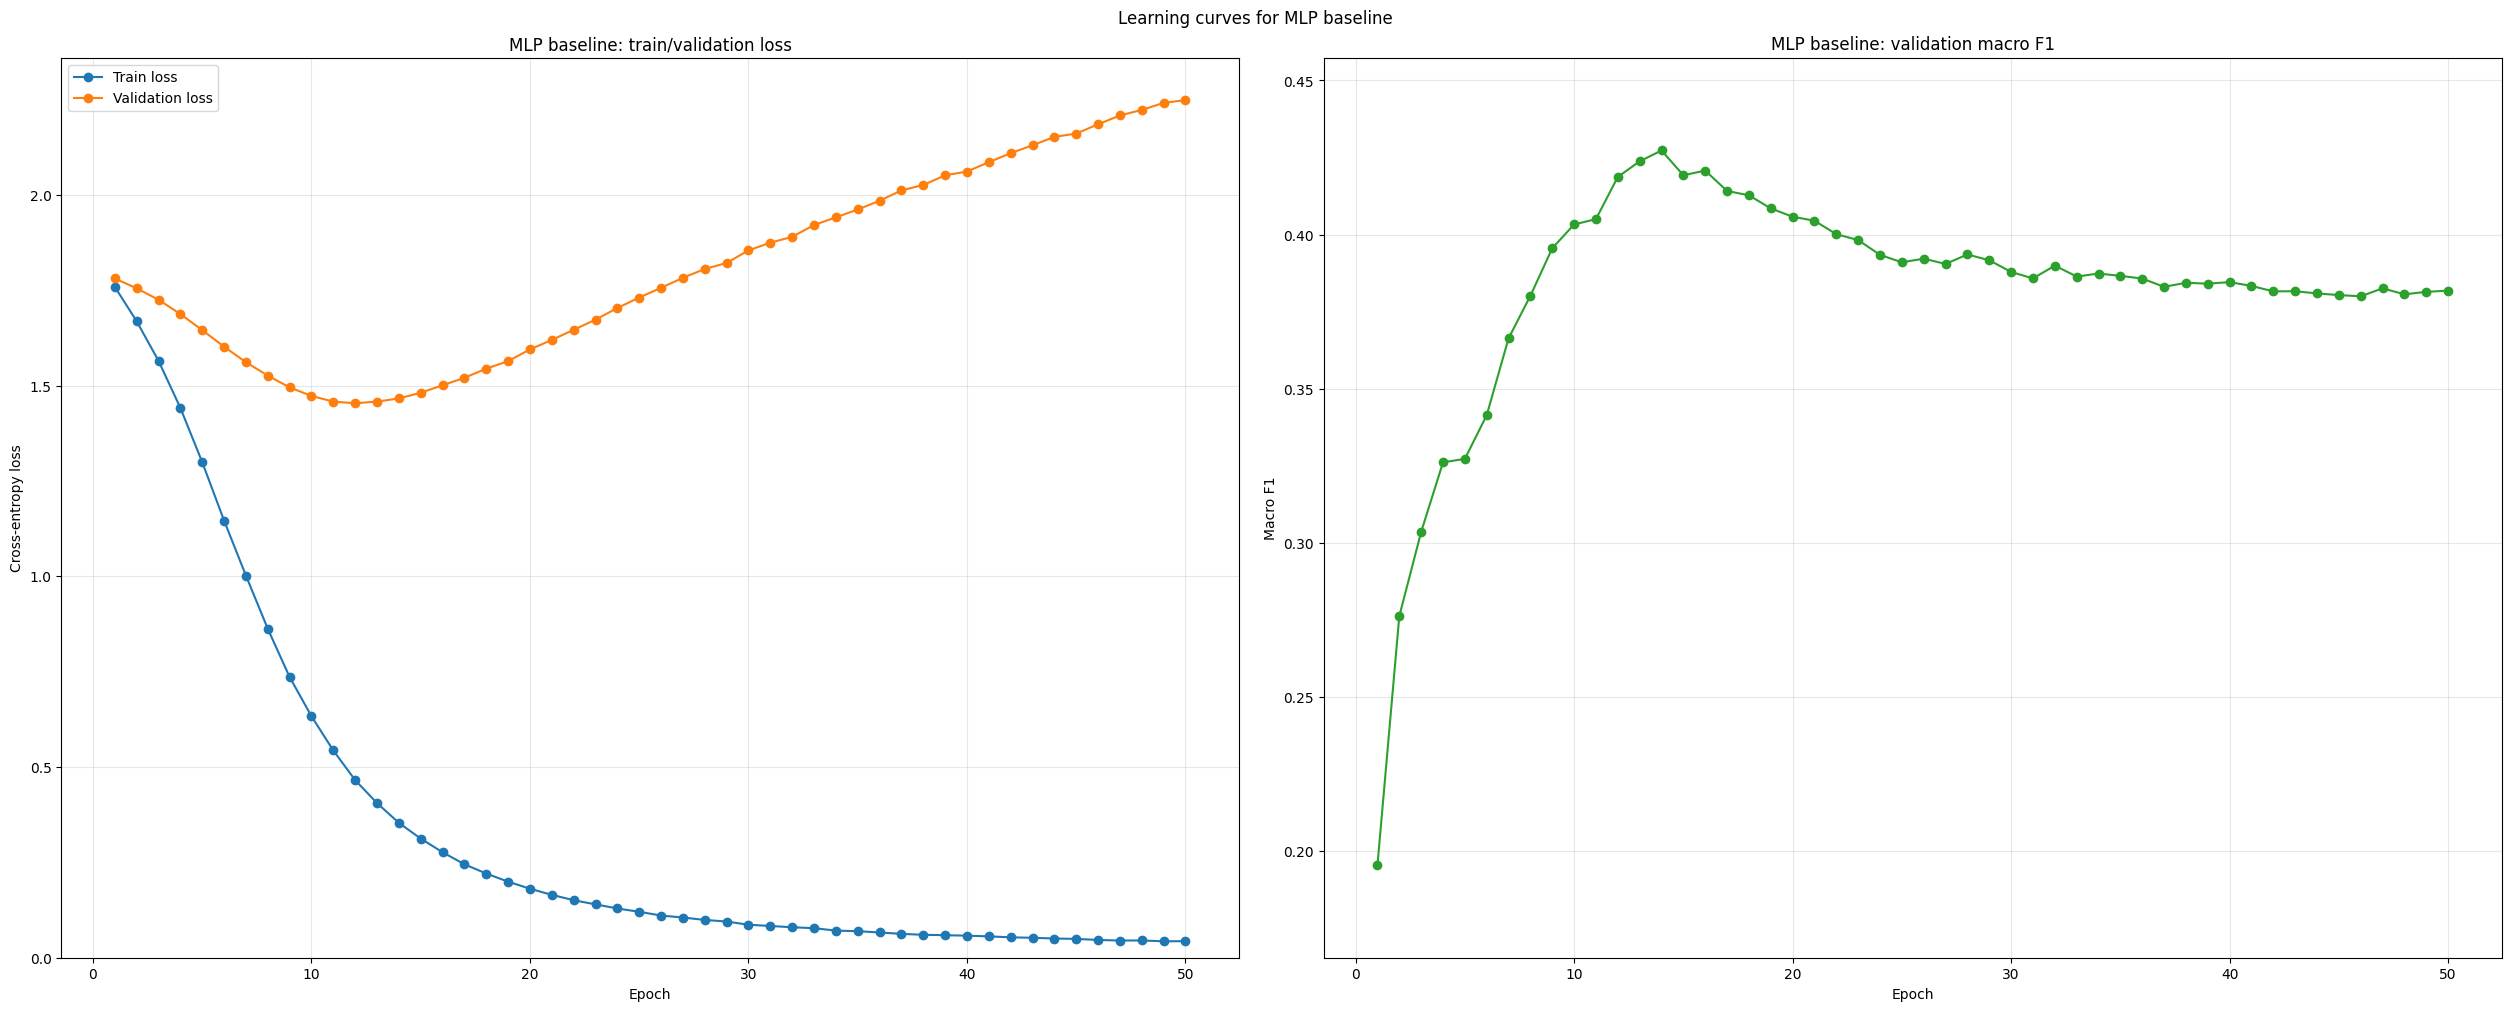

In [140]:
mlp_run = train_and_record(
    context=dnn_context,
    model_name='MLP baseline',
    model=MLPDecoder(dnn_window_size, n_features_dnn, n_classes_dnn),
    n_epochs=BASE_EPOCHS,
    optimizer_name=BASE_OPTIMIZER_NAME,
    lr=BASE_LR,
    weight_decay=BASE_WEIGHT_DECAY,
    learning_curve_figsize=FIGSIZE,
)

mlp_model = mlp_run['model']
mlp_history = mlp_run['history']


Here we see a typical overfitting, after some epochs the model learn the training data but do not generalize

## 3.4 CNN (Convolution Neural Network)

For temporal signals, CNN uses local filters over time.

1D convolution (one output channel `j`):

$$
y_{t,j} = \sum_{c=1}^{C_{in}} \sum_{\tau=0}^{K-1} w_{j,c,\tau} \, x_{t+\tau-p, c} + b_j
$$

`K` is kernel size, `p` is padding.

**Intuition:** Think of the filter as a small "detector window" that slides along the time axis. At each position it looks at `K` consecutive time steps across all channels, computes a weighted sum, and produces one output value. By stacking many such filters, the CNN can detect different local patterns in the signal (e.g. a brief power burst, a rising slope, an oscillation).

> **Note on the figure below:** The illustration shows a **2D** convolution (a filter sliding over an image). Our signals are 1D (time only), so imagine collapsing the image to a single row — the kernel slides left-to-right along that row. The principle is identical, just one dimension instead of two.

<p align="center">
  <img src="figures/cnn_convolution.png" width="620"/>
</p>
<div style="font-size:0.92em; color:#4b5563; margin:0.35em 0 1em 0;">
  Example of a 3×3 image convolved with a 2×2 filter to give a resulting 2×2 feature map. For our 1D ECoG signals, the filter slides along the time axis only.<br/>
  Source: <a href="https://link.springer.com/book/10.1007/978-3-031-45468-4">Christopher M. Bishop and Hugh Bishop, <i>Deep Learning: Foundations and Concepts</i>, Springer, 2024</a>.
</div>

**Pooling** reduces temporal resolution and keeps salient features:

$$
y_t = \max_{\tau \in \{0, \dots, P-1\}} x_{t+\tau}
$$

(with max-pooling size `P`).

<p align="center">
  <img src="figures/pooling.png" width="620"/>
</p>
<div style="font-size:0.92em; color:#4b5563; margin:0.35em 0 1em 0;">
Illustration of max-pooling
in which blocks of 2 ×2 pixels in a feature map are combined using the 'max'
operator to generate a new feature map
of smaller dimensionality
  Source: <a href="https://link.springer.com/book/10.1007/978-3-031-45468-4">Christopher M. Bishop and Hugh Bishop, <i>Deep Learning: Foundations and Concepts</i>, Springer, 2024</a>.
</div>

**Batch normalization** stabilizes activations:

$$
\hat{x} = \frac{x - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}, \quad y = \gamma \hat{x} + \beta
$$


### Example of full CNN architecture

<p align="center">
  <img src="figures/cnn_vgg.png" width="620"/>
</p>
<div style="font-size:0.92em; color:#4b5563; margin:0.35em 0 1em 0;">
  Example of a full convolutional architecture, here illustrated with a VGG-style network.<br/>
  Source: <a href="https://link.springer.com/book/10.1007/978-3-031-45468-4">Christopher M. Bishop and Hugh Bishop, <i>Deep Learning: Foundations and Concepts</i>, Springer, 2024</a>.
</div>


In [141]:
class BasicCNNDecoder(nn.Module):
    def __init__(self, n_features, n_classes, channels=64):
        super().__init__()
        self.conv = nn.Conv1d(n_features, channels, kernel_size=5, padding=2)
        self.bn = nn.BatchNorm1d(channels)
        self.act = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(channels, n_classes),
        )

    def forward(self, x):
        x = x.transpose(1, 2)  # (batch, features, time)
        x = self.pool(self.act(self.bn(self.conv(x))))
        return self.head(x)




Training CNN basic
Epoch 01/50 | train loss=1.7694 | val loss=1.7433 | val bal_acc=0.227 | val macro_f1=0.206
Epoch 02/50 | train loss=1.5488 | val loss=1.6725 | val bal_acc=0.284 | val macro_f1=0.261
Epoch 03/50 | train loss=1.3711 | val loss=1.6181 | val bal_acc=0.307 | val macro_f1=0.284
Epoch 04/50 | train loss=1.2210 | val loss=1.5712 | val bal_acc=0.352 | val macro_f1=0.332
Epoch 05/50 | train loss=1.0947 | val loss=1.5325 | val bal_acc=0.377 | val macro_f1=0.358
Epoch 06/50 | train loss=0.9889 | val loss=1.5023 | val bal_acc=0.390 | val macro_f1=0.373
Epoch 07/50 | train loss=0.9011 | val loss=1.4751 | val bal_acc=0.400 | val macro_f1=0.384
Epoch 08/50 | train loss=0.8248 | val loss=1.4568 | val bal_acc=0.405 | val macro_f1=0.392
Epoch 09/50 | train loss=0.7602 | val loss=1.4425 | val bal_acc=0.404 | val macro_f1=0.392
Epoch 10/50 | train loss=0.7049 | val loss=1.4300 | val bal_acc=0.406 | val macro_f1=0.393
Epoch 11/50 | train loss=0.6549 | val loss=1.4202 | val bal_acc=0.409 

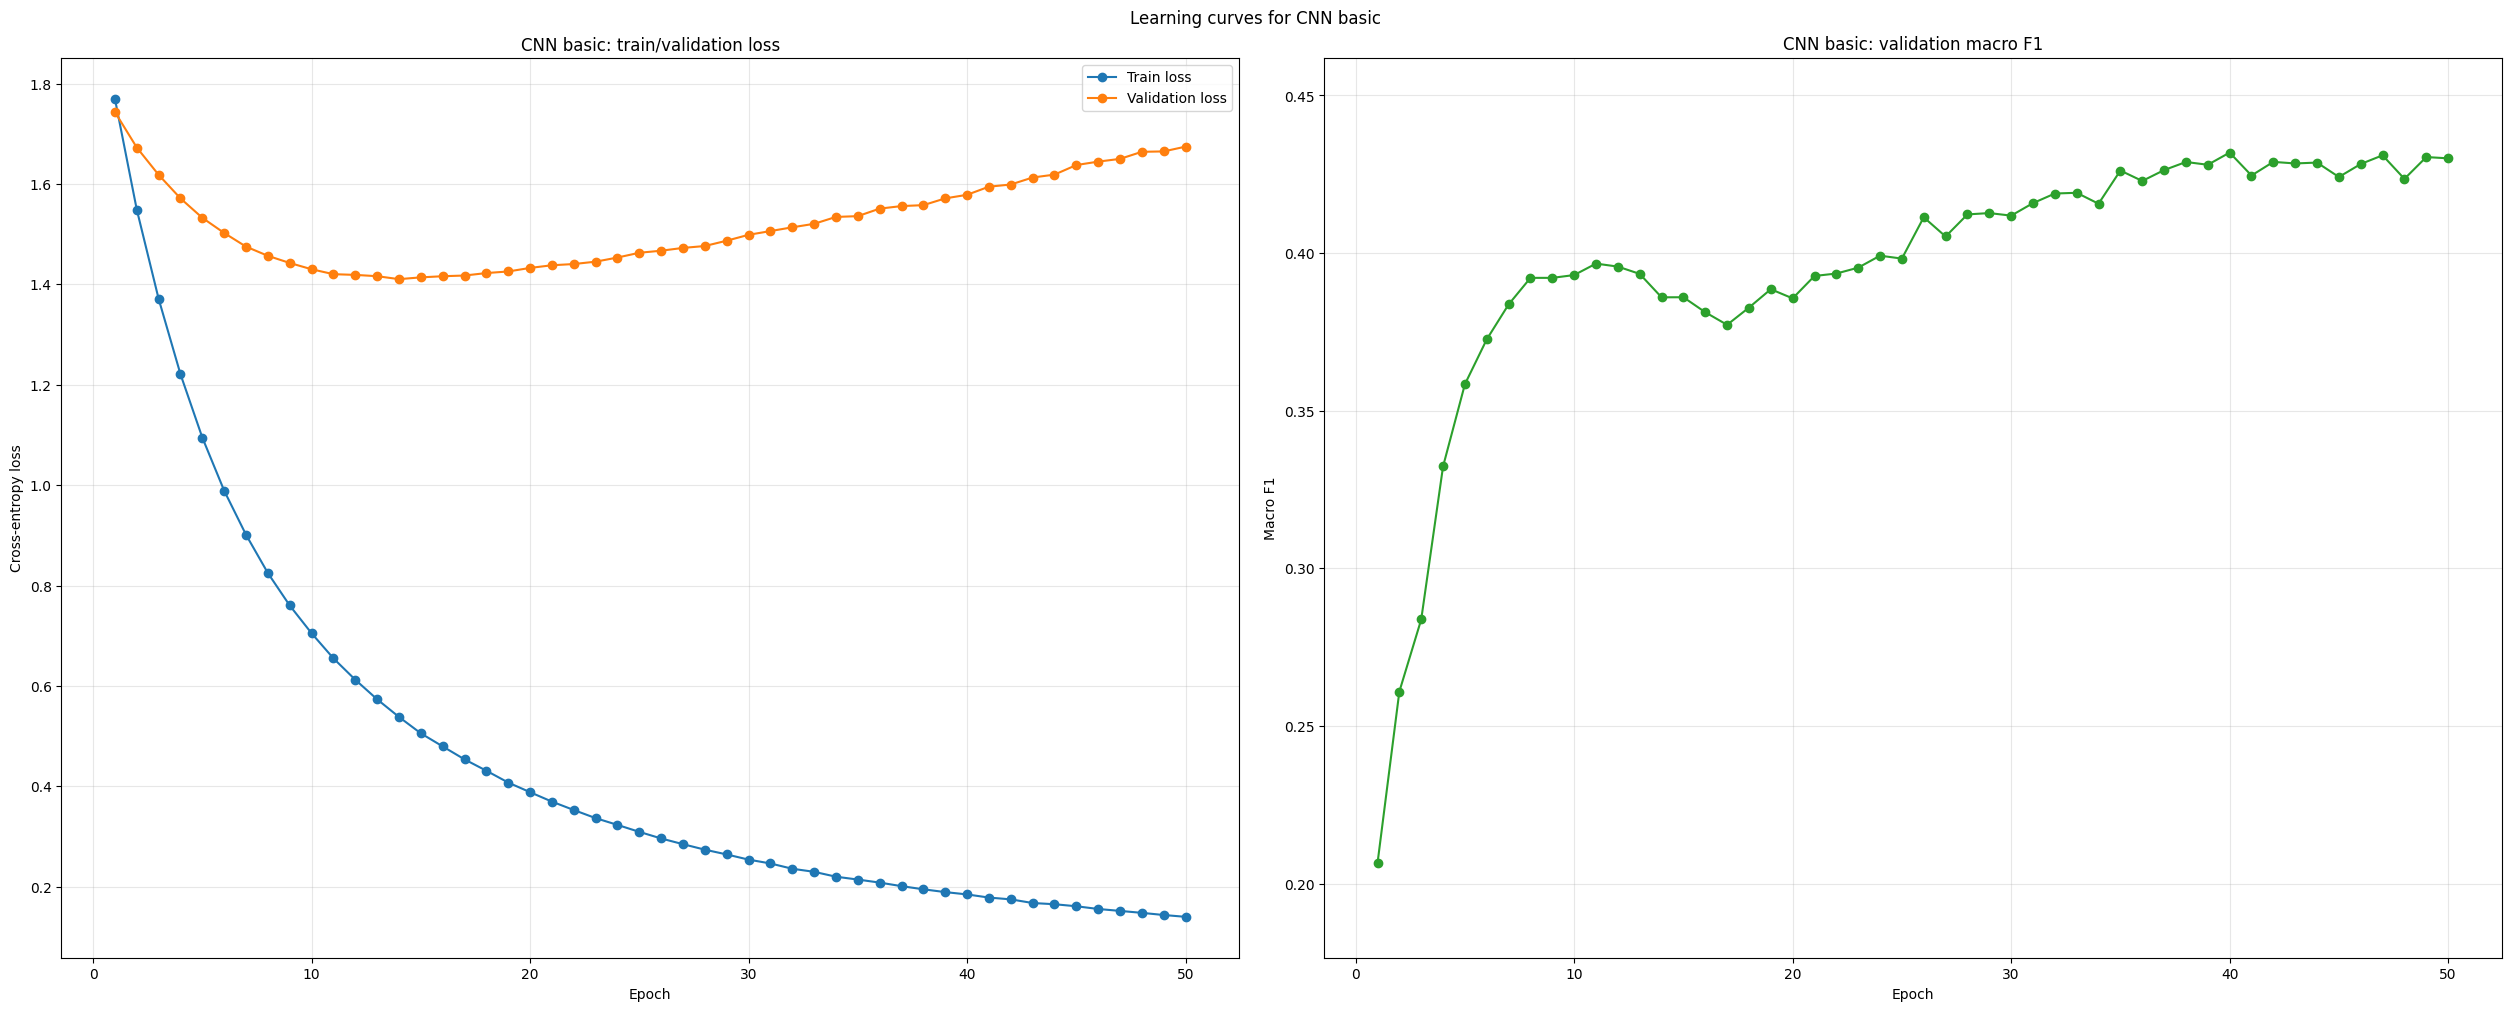

In [142]:
basic_cnn_run = train_and_record(
    context=dnn_context,
    model_name='CNN basic',
    model=BasicCNNDecoder(n_features_dnn, n_classes_dnn),
    n_epochs=BASE_EPOCHS,
    optimizer_name=BASE_OPTIMIZER_NAME,
    lr=BASE_LR,
    weight_decay=BASE_WEIGHT_DECAY,
    learning_curve_figsize=FIGSIZE,
)

basic_cnn_model = basic_cnn_run['model']
basic_cnn_history = basic_cnn_run['history']


## 3.5 RNN (Recurrent Neural Network)

In an RNN, time information is carried by a **hidden state**.

At each time step:

$$
h_t = \tanh(W_x x_t + W_h h_{t-1} + b_h)
$$

`h_t` is the memory summary up to time `t`.

For classification, we usually use the last state:

$$
o = W_o h_T + b_o
$$

### ⚠️ The vanishing gradient problem

Vanilla RNNs suffer from a critical limitation: **gradients vanish over long sequences**.

During training, gradients flow **backwards through time** — from step `T` back to step `1`. At each step, the gradient is multiplied by `W_h`. If the largest singular value of `W_h` is less than 1, these repeated multiplications make the gradient shrink exponentially. By the time it reaches early time steps, the gradient is essentially zero: **the model cannot learn dependencies that span many steps**.

This is the main practical limitation of vanilla RNNs:
- They work well for short-range dependencies (a few steps)
- They struggle with long-range dependencies (many steps)

**Solutions:** More advanced architectures such as **LSTMs** (Long Short-Term Memory) and **GRUs** (Gated Recurrent Units) address this with gating mechanisms that allow gradients to flow more freely across many steps. **Transformers** (the next section) bypass recurrence entirely by allowing every time step to directly attend to every other step — which is why they now dominate sequence modelling tasks.


### Illustration

<p align="center">
  <img src="figures/rnn_unfold.svg" width="700"/>
</p>
<div style="font-size:0.92em; color:#4b5563; margin:0.35em 0 1em 0;">
  An unfolded RNN shows the same recurrent cell reused at each time step while the hidden state is passed forward through time.<br/>
  Source: <a href="https://commons.wikimedia.org/wiki/File:Recurrent_neural_network_unfold.svg">Wikimedia Commons</a>.
</div>


In [143]:
class BasicRNNDecoder(nn.Module):
    def __init__(self, n_features, n_classes, hidden_size=96):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=n_features,
            hidden_size=hidden_size,
            nonlinearity='tanh',
            batch_first=True,
        )
        self.classifier = nn.Linear(hidden_size, n_classes)

    def forward(self, x):
        _, h_n = self.rnn(x)
        h_last = h_n[-1]
        return self.classifier(h_last)




Training RNN basic
Epoch 01/50 | train loss=1.8512 | val loss=1.8857 | val bal_acc=0.176 | val macro_f1=0.157
Epoch 02/50 | train loss=1.7909 | val loss=1.8615 | val bal_acc=0.194 | val macro_f1=0.171
Epoch 03/50 | train loss=1.7333 | val loss=1.8390 | val bal_acc=0.206 | val macro_f1=0.182
Epoch 04/50 | train loss=1.6783 | val loss=1.8178 | val bal_acc=0.219 | val macro_f1=0.193
Epoch 05/50 | train loss=1.6248 | val loss=1.7977 | val bal_acc=0.228 | val macro_f1=0.199
Epoch 06/50 | train loss=1.5718 | val loss=1.7772 | val bal_acc=0.236 | val macro_f1=0.205
Epoch 07/50 | train loss=1.5201 | val loss=1.7572 | val bal_acc=0.245 | val macro_f1=0.213
Epoch 08/50 | train loss=1.4680 | val loss=1.7374 | val bal_acc=0.257 | val macro_f1=0.226
Epoch 09/50 | train loss=1.4163 | val loss=1.7179 | val bal_acc=0.266 | val macro_f1=0.234
Epoch 10/50 | train loss=1.3655 | val loss=1.6981 | val bal_acc=0.275 | val macro_f1=0.243
Epoch 11/50 | train loss=1.3144 | val loss=1.6770 | val bal_acc=0.286 

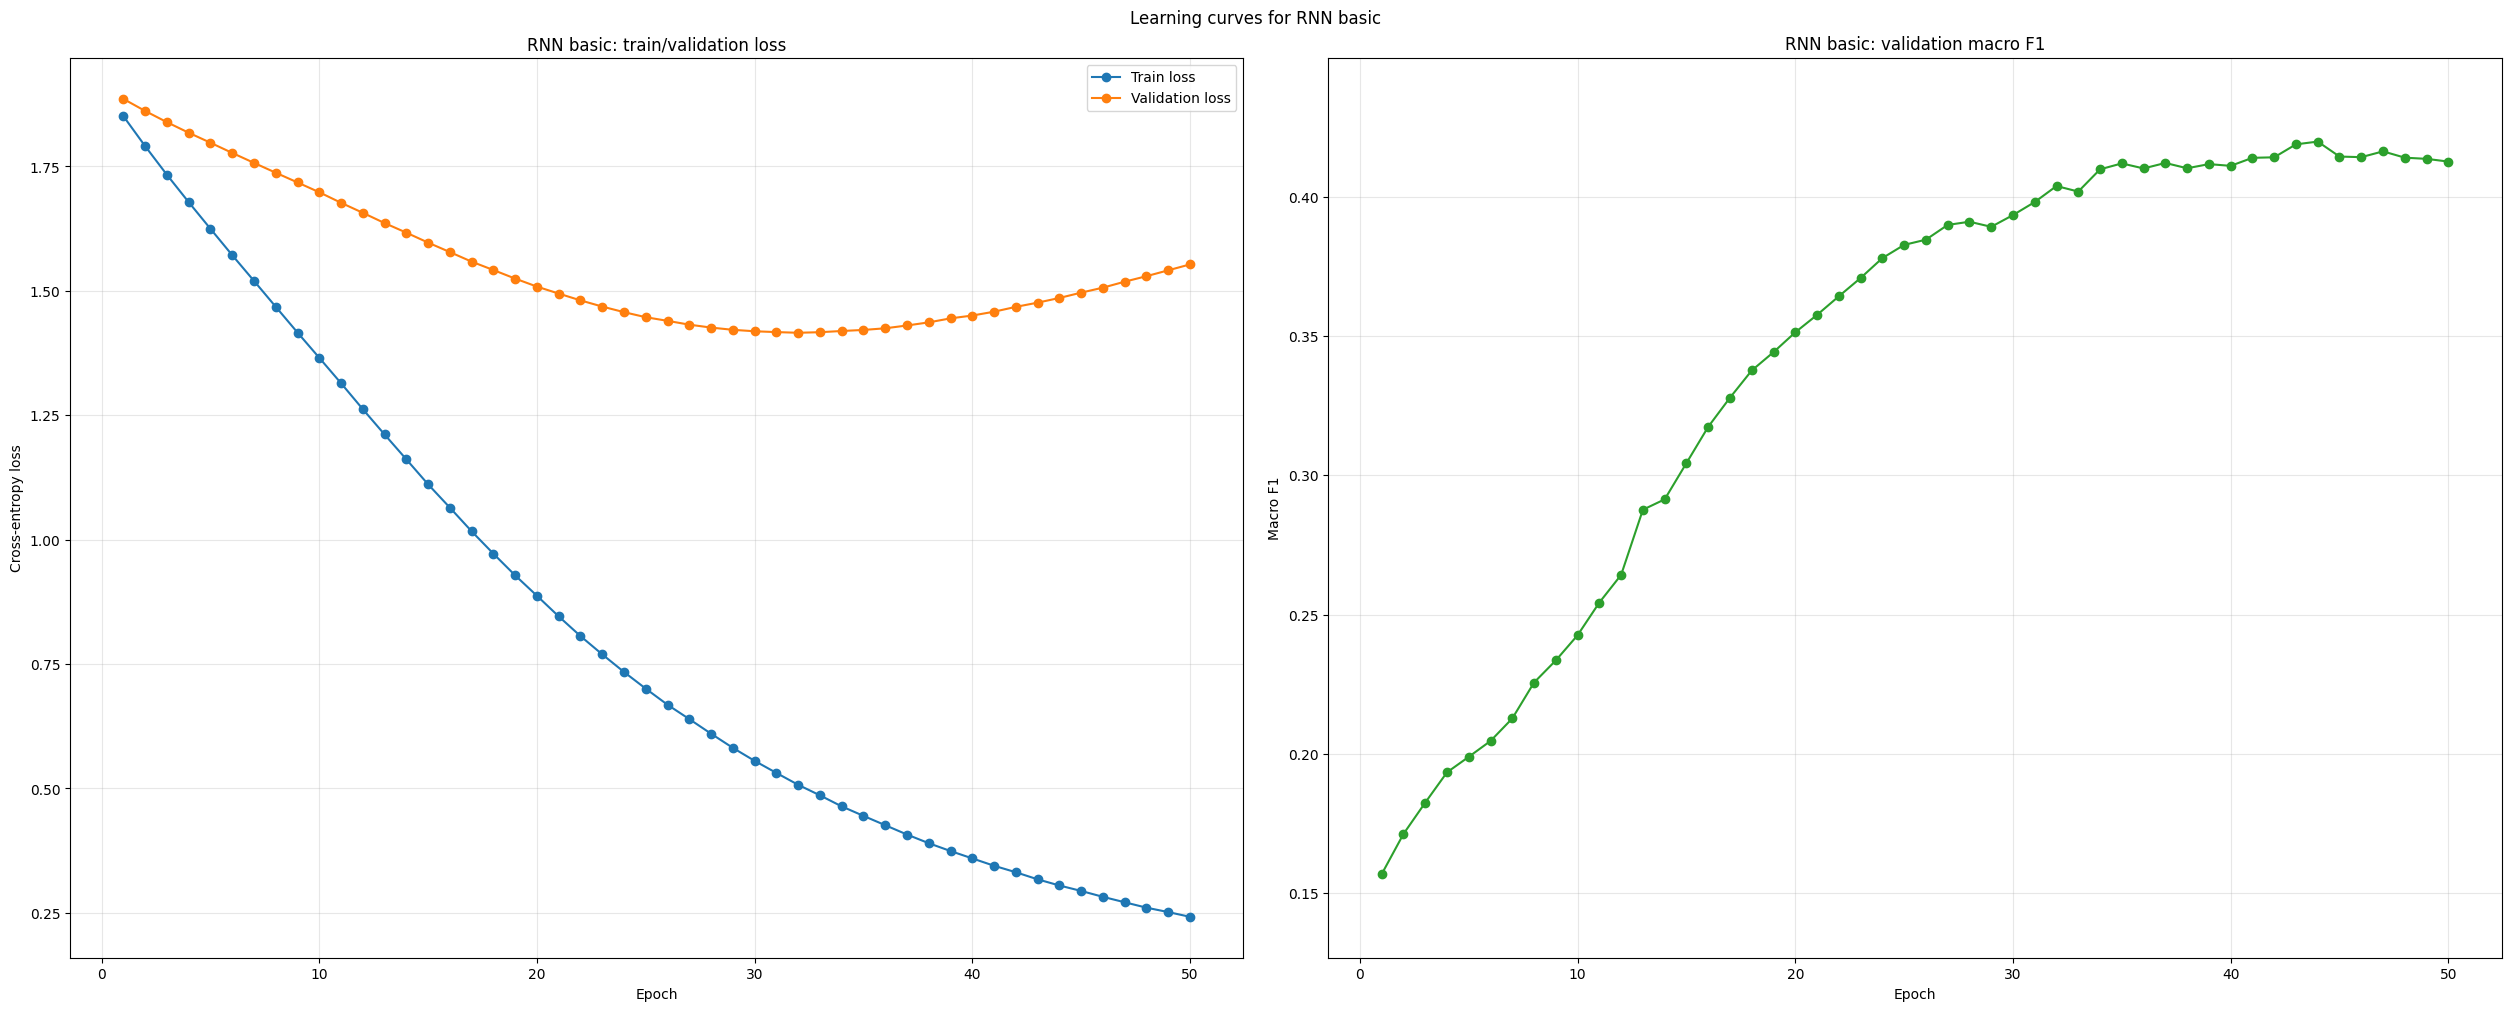

In [144]:
basic_rnn_run = train_and_record(
    context=dnn_context,
    model_name='RNN basic',
    model=BasicRNNDecoder(n_features_dnn, n_classes_dnn),
    n_epochs=BASE_EPOCHS,
    optimizer_name=BASE_OPTIMIZER_NAME,
    lr=BASE_LR,
    weight_decay=BASE_WEIGHT_DECAY,
    learning_curve_figsize=FIGSIZE,
)

basic_rnn_model = basic_rnn_run['model']
basic_rnn_history = basic_rnn_run['history']


## 3.6 Transformer And Attention 





#### 3.6.1 Self Attention

A Transformer replaces recurrence with attention.

### Intuition: the query / key / value analogy

Imagine you are looking for a piece of information in a library. You have a **query** (what you are looking for), you compare it against the **keys** of each book (a summary on the spine), and you retrieve the **value** (the content of the most relevant books).

Self-attention does exactly this, but every time step plays all three roles simultaneously:

- **Q (Query):** "What information am I looking for?"
- **K (Key):** "What information do I offer to others?"
- **V (Value):** "What content do I actually send if someone selects me?"

For each position in the sequence, the model computes a match score between its Query and all Keys, converts those scores into weights (via softmax), and then takes a weighted sum of all Values. The result is a new representation for that position that has "looked at" the whole sequence and gathered relevant context.

### Mathematical formulation

Given input sequence matrix `X`:

$$
Q = XW_Q, \quad K = XW_K, \quad V = XW_V
$$

Scaled dot-product attention is:

$$
\mathrm{Attention}(Q, K, V) = \mathrm{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

- $QK^T$ computes a similarity score between every pair of positions.
- The $\sqrt{d_k}$ scaling prevents the dot products from becoming very large in high dimensions (which would saturate the softmax and kill the gradients).
- The softmax converts scores into attention weights (they sum to 1).
- Multiplying by $V$ produces the final output: a weighted combination of all values.

So each time step can directly look at all other steps — **no information has to travel step-by-step as in an RNN**. This is what makes Transformers so powerful for long sequences.

Below we first define an explicit attention block, then train a model that contains this block.


### Illustration

<p align="center">
  <img src="figures/self_attention.png" width="200"/>
</p>
<div style="font-size:0.92em; color:#4b5563; margin:0.35em 0 1em 0;">
Information flow in a scaled dot product self-attention neural network
layer. Here ‘mat mul’ denotes matrix
multiplication, and ‘scale’ refers to the
normalization of the argument to the
softmax using √Dk. This structure
constitutes a single attention ‘head’.<br/>
  Source: <a href="https://link.springer.com/book/10.1007/978-3-031-45468-4">Christopher M. Bishop and Hugh Bishop, <i>Deep Learning: Foundations and Concepts</i>, Springer, 2024</a>.
</div>


In [145]:
class ScaledDotProductAttentionBlock(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

    def forward(self, x):
        # x shape: (batch, time, d_model)
        q = self.q_proj(x)
        k = self.k_proj(x)
        v = self.v_proj(x)

        scores = torch.matmul(q, k.transpose(1, 2)) / math.sqrt(q.size(-1))
        weights = torch.softmax(scores, dim=-1)
        context = torch.matmul(weights, v)

        out = self.out_proj(context)
        return out, weights


class SingleHeadAttentionDecoder(nn.Module):
    def __init__(self, n_features, n_classes, d_model=128, max_len=128):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.positional = nn.Parameter(torch.zeros(1, max_len, d_model)) # Learnable positional encoding to give the model information about the order of the time steps, since attention is permutation invariant.
        self.attn_block = ScaledDotProductAttentionBlock(d_model)
        self.norm = nn.LayerNorm(d_model)
        self.classifier = nn.Linear(d_model, n_classes)

    def forward(self, x):
        x = self.input_proj(x)
        x = x + self.positional[:, :x.size(1), :]

        attn_out, _ = self.attn_block(x)
        x = self.norm(x + attn_out)

        pooled = x.mean(dim=1)
        return self.classifier(pooled)




Training Attention single-head
Epoch 01/50 | train loss=1.8274 | val loss=1.9781 | val bal_acc=0.126 | val macro_f1=0.114
Epoch 02/50 | train loss=1.6521 | val loss=1.9097 | val bal_acc=0.156 | val macro_f1=0.140
Epoch 03/50 | train loss=1.5010 | val loss=1.8533 | val bal_acc=0.188 | val macro_f1=0.172
Epoch 04/50 | train loss=1.3649 | val loss=1.8032 | val bal_acc=0.227 | val macro_f1=0.207
Epoch 05/50 | train loss=1.2416 | val loss=1.7591 | val bal_acc=0.266 | val macro_f1=0.242
Epoch 06/50 | train loss=1.1300 | val loss=1.7179 | val bal_acc=0.292 | val macro_f1=0.266
Epoch 07/50 | train loss=1.0302 | val loss=1.6826 | val bal_acc=0.316 | val macro_f1=0.289
Epoch 08/50 | train loss=0.9396 | val loss=1.6548 | val bal_acc=0.330 | val macro_f1=0.303
Epoch 09/50 | train loss=0.8567 | val loss=1.6308 | val bal_acc=0.344 | val macro_f1=0.320
Epoch 10/50 | train loss=0.7863 | val loss=1.6119 | val bal_acc=0.367 | val macro_f1=0.345
Epoch 11/50 | train loss=0.7198 | val loss=1.5937 | val ba

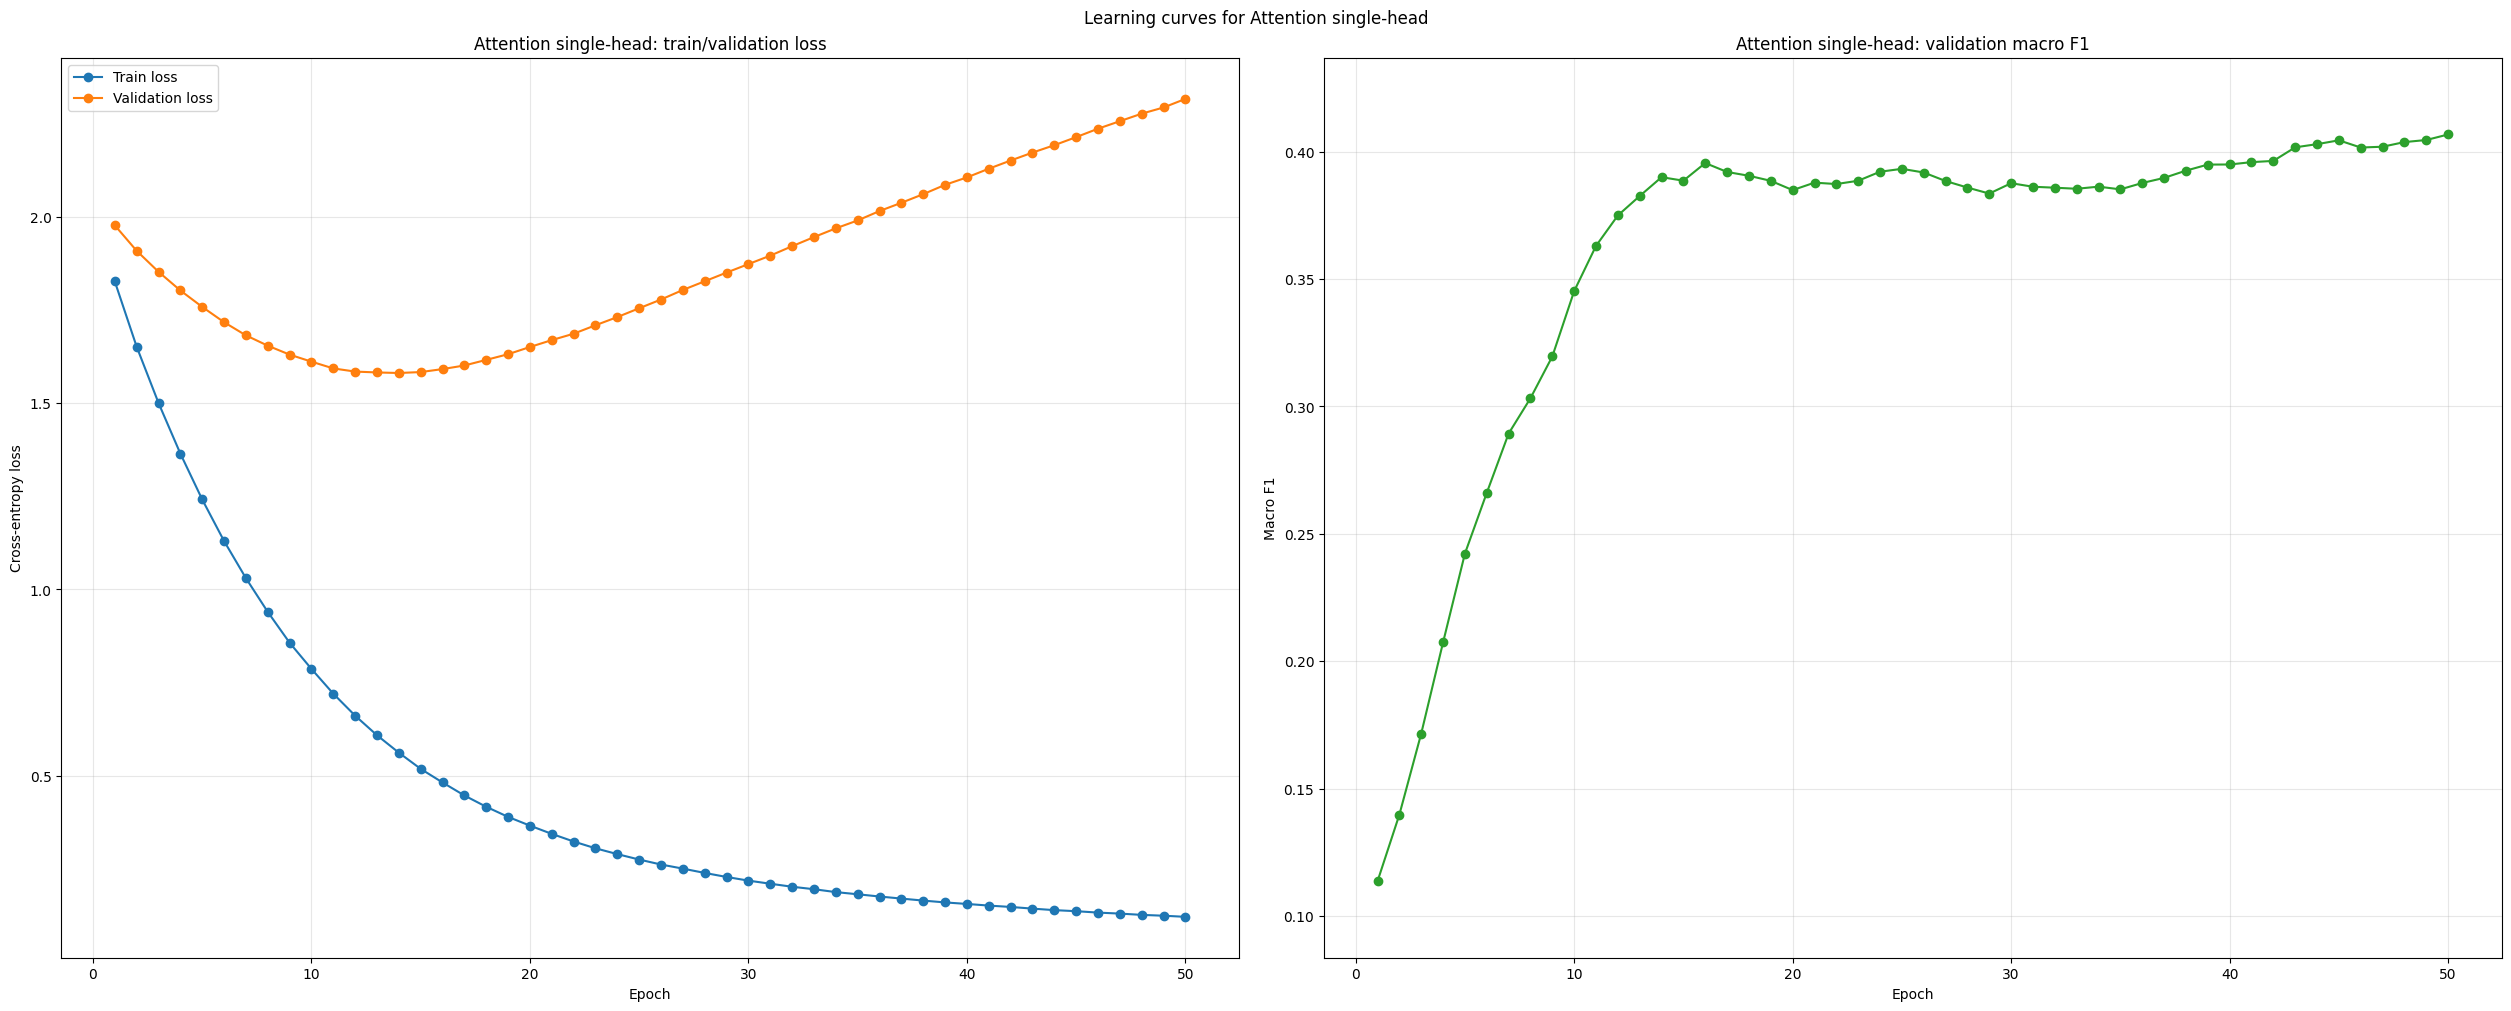

In [146]:
single_attn_run = train_and_record(
    context=dnn_context,
    model_name='Attention single-head',
    model=SingleHeadAttentionDecoder(
        n_features=n_features_dnn,
        n_classes=n_classes_dnn,
        max_len=dnn_window_size,
    ),
    n_epochs=BASE_EPOCHS,
    optimizer_name=BASE_OPTIMIZER_NAME,
    lr=BASE_LR,
    weight_decay=BASE_WEIGHT_DECAY,
    learning_curve_figsize=FIGSIZE,
)

single_attn_model = single_attn_run['model']
single_attn_history = single_attn_run['history']


#### 3.6.2 Multi-Head Attention

**Why multiple heads?**

A single attention head computes one set of Q/K/V projections. But different aspects of the input may require different kinds of relationships. For example, one head might learn to attend to the most recent time steps (short-range context), while another might learn to attend to time steps that were similar in the past (long-range pattern matching).

Multi-head attention runs several attention heads in **parallel**, each with its own independent Q/K/V projections, then concatenates their outputs and mixes them with a final linear layer:

$$
\text{head}_i = \mathrm{Attention}(QW_i^Q, KW_i^K, VW_i^V)
$$

$$
\mathrm{MultiHead}(Q, K, V) = \mathrm{Concat}(\text{head}_1, \dots,\text{head}_H)W^O
$$

This lets the model **simultaneously capture different temporal relations** — short-range, long-range, rhythmic patterns — rather than collapsing everything into a single attention map.

In practice, the dimension $d_k$ of each head is set to $d_\text{model} / H$, so the total computation stays the same as a single head of dimension $d_\text{model}$.


### Illustration

<p align="center">
  <img src="figures/multi_head_attention.png" width="300"/>
</p>
<div style="font-size:0.92em; color:#4b5563; margin:0.35em 0 1em 0;">
  Multi-head attention runs several attention heads in parallel before concatenating their outputs.<br/>
  Source: <a href="https://commons.wikimedia.org/wiki/File:Multi-head_attention.png">Wikimedia Commons</a>.
</div>


In [147]:
class MultiHeadAttentionBlock(nn.Module):
    def __init__(self, d_model=128, n_heads=4):
        super().__init__()
        # here we use the built-in PyTorch multi-head attention, which is more efficient than implementing it from scratch.
        # It will internally split the input into multiple heads, apply scaled dot-product attention to each head, and concatenate the results.
        self.mha = nn.MultiheadAttention(embed_dim=d_model, num_heads=n_heads, batch_first=True)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        attn_out, _ = self.mha(x, x, x, need_weights=False)
        return self.norm(x + attn_out)


class MultiHeadAttentionDecoder(nn.Module):
    def __init__(self, n_features, n_classes, d_model=128, n_heads=4, max_len=128):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.positional = nn.Parameter(torch.zeros(1, max_len, d_model))
        self.attn_block = MultiHeadAttentionBlock(d_model=d_model, n_heads=n_heads)
        self.classifier = nn.Linear(d_model, n_classes)

    def forward(self, x):
        x = self.input_proj(x)
        x = x + self.positional[:, :x.size(1), :]
        x = self.attn_block(x)
        pooled = x.mean(dim=1)
        return self.classifier(pooled)




Training Attention multi-head
Epoch 01/50 | train loss=1.8250 | val loss=1.8766 | val bal_acc=0.183 | val macro_f1=0.179
Epoch 02/50 | train loss=1.6486 | val loss=1.7951 | val bal_acc=0.230 | val macro_f1=0.225
Epoch 03/50 | train loss=1.4961 | val loss=1.7279 | val bal_acc=0.274 | val macro_f1=0.271
Epoch 04/50 | train loss=1.3600 | val loss=1.6704 | val bal_acc=0.312 | val macro_f1=0.311
Epoch 05/50 | train loss=1.2360 | val loss=1.6201 | val bal_acc=0.344 | val macro_f1=0.343
Epoch 06/50 | train loss=1.1228 | val loss=1.5766 | val bal_acc=0.370 | val macro_f1=0.366
Epoch 07/50 | train loss=1.0202 | val loss=1.5394 | val bal_acc=0.393 | val macro_f1=0.385
Epoch 08/50 | train loss=0.9282 | val loss=1.5108 | val bal_acc=0.400 | val macro_f1=0.391
Epoch 09/50 | train loss=0.8449 | val loss=1.4882 | val bal_acc=0.406 | val macro_f1=0.396
Epoch 10/50 | train loss=0.7732 | val loss=1.4713 | val bal_acc=0.409 | val macro_f1=0.399
Epoch 11/50 | train loss=0.7073 | val loss=1.4591 | val bal

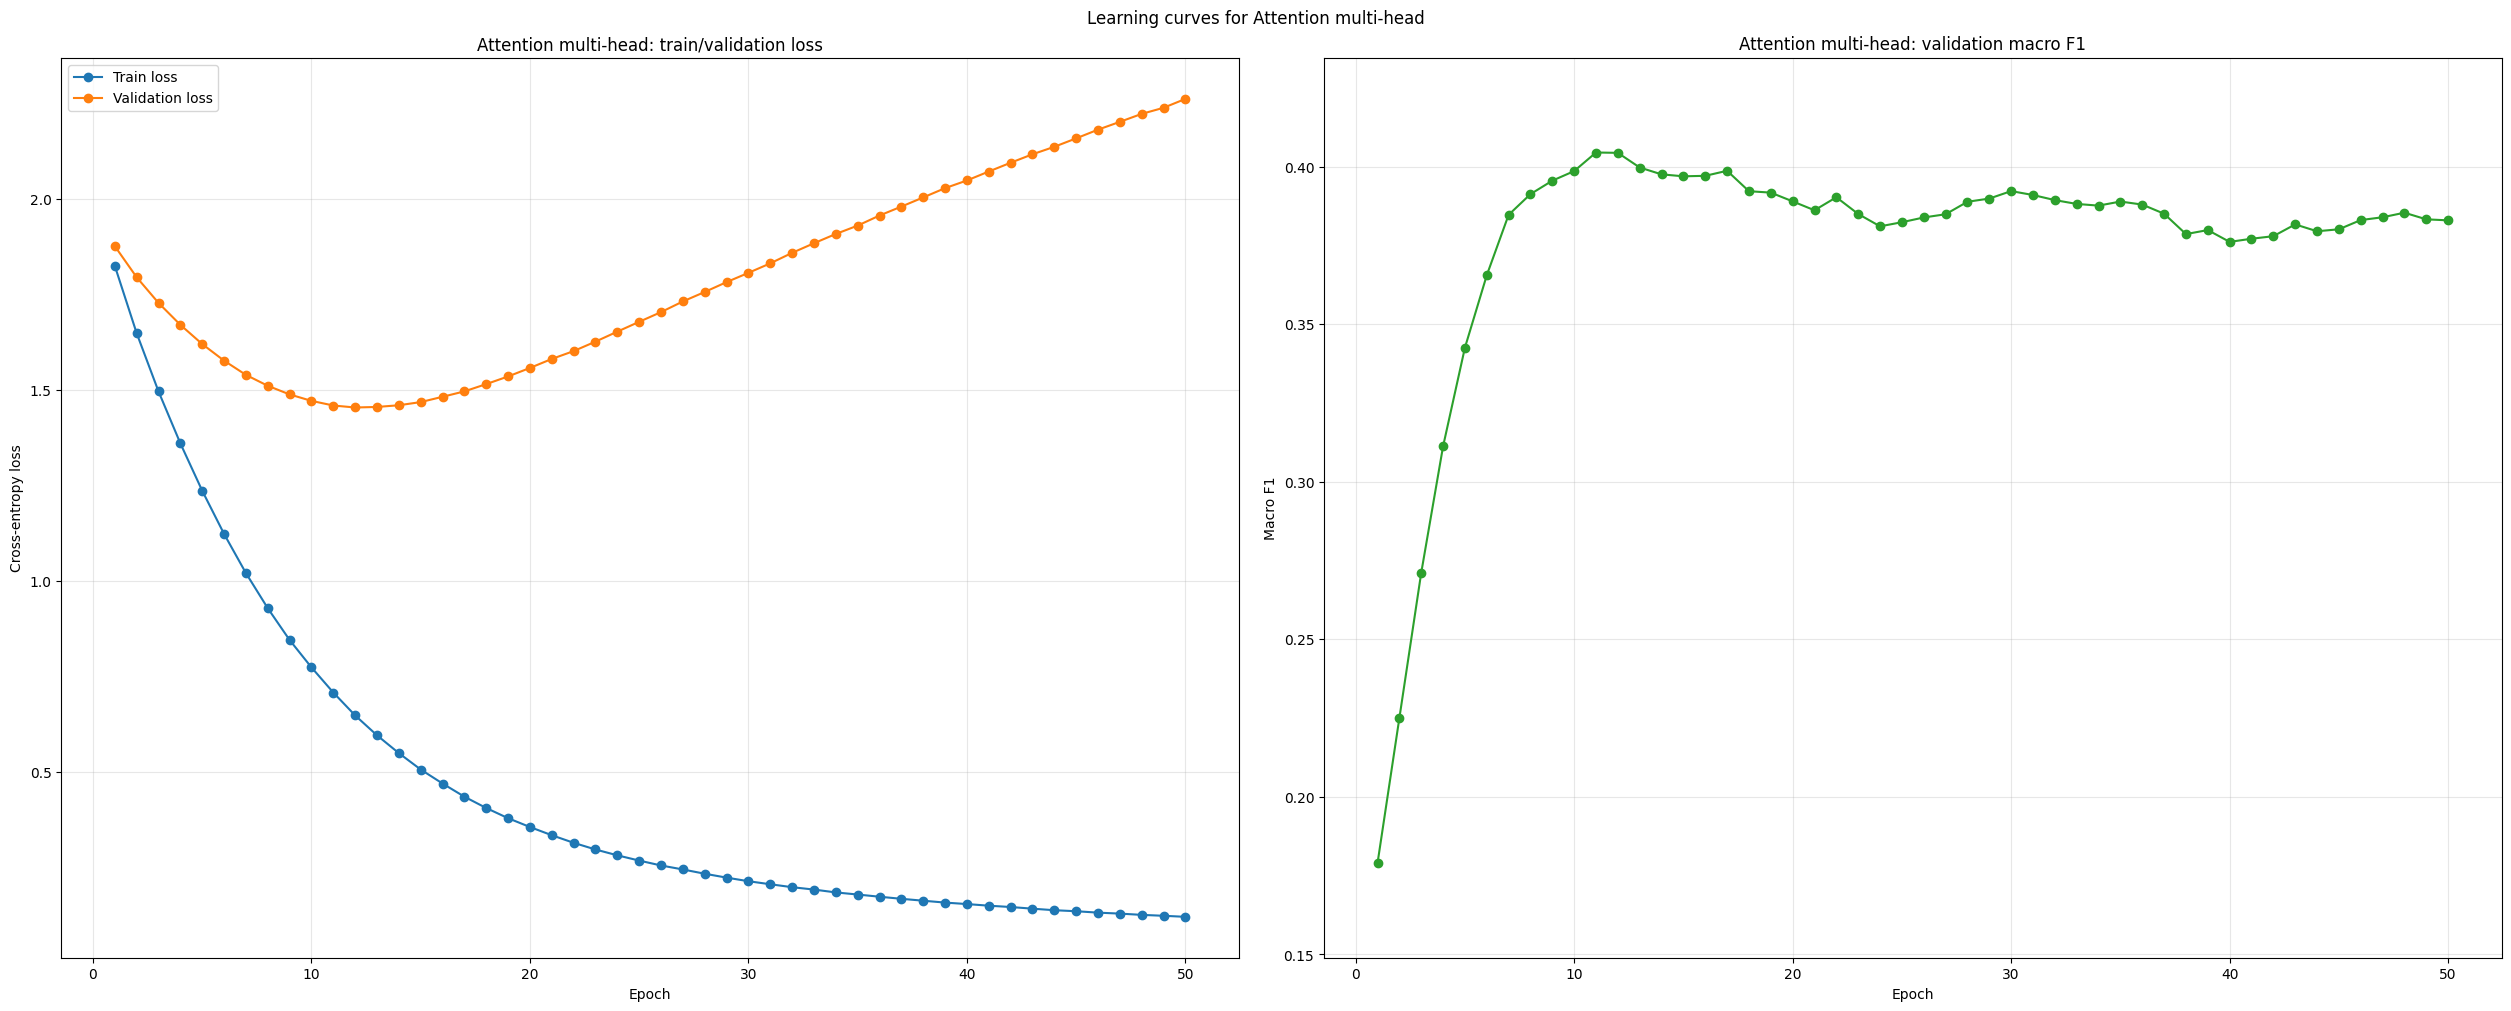

In [148]:
multihead_attn_run = train_and_record(
    context=dnn_context,
    model_name='Attention multi-head',
    model=MultiHeadAttentionDecoder(
        n_features=n_features_dnn,
        n_classes=n_classes_dnn,
        max_len=dnn_window_size,
    ),
    n_epochs=BASE_EPOCHS,
    optimizer_name=BASE_OPTIMIZER_NAME,
    lr=BASE_LR,
    weight_decay=BASE_WEIGHT_DECAY,
    learning_curve_figsize=FIGSIZE,
)

multihead_attn_model = multihead_attn_run['model']
multihead_attn_history = multihead_attn_run['history']


## 3.7 Compare All Models

We rank the DNNs using the validation **macro F1** only. The test set is kept for the final unbiased evaluation of the selected architecture.


Final ranking (sorted by validation macro F1):
1. CNN basic                | val macro_f1=0.432 | val bal_acc=0.432 | test macro_f1=0.379 | test bal_acc=0.390
2. MLP baseline             | val macro_f1=0.427 | val bal_acc=0.418 | test macro_f1=0.407 | test bal_acc=0.413
3. RNN basic                | val macro_f1=0.420 | val bal_acc=0.432 | test macro_f1=0.373 | test bal_acc=0.379
4. Attention multi-head     | val macro_f1=0.404 | val bal_acc=0.417 | test macro_f1=0.361 | test bal_acc=0.369
5. Attention single-head    | val macro_f1=0.395 | val bal_acc=0.416 | test macro_f1=0.354 | test bal_acc=0.359


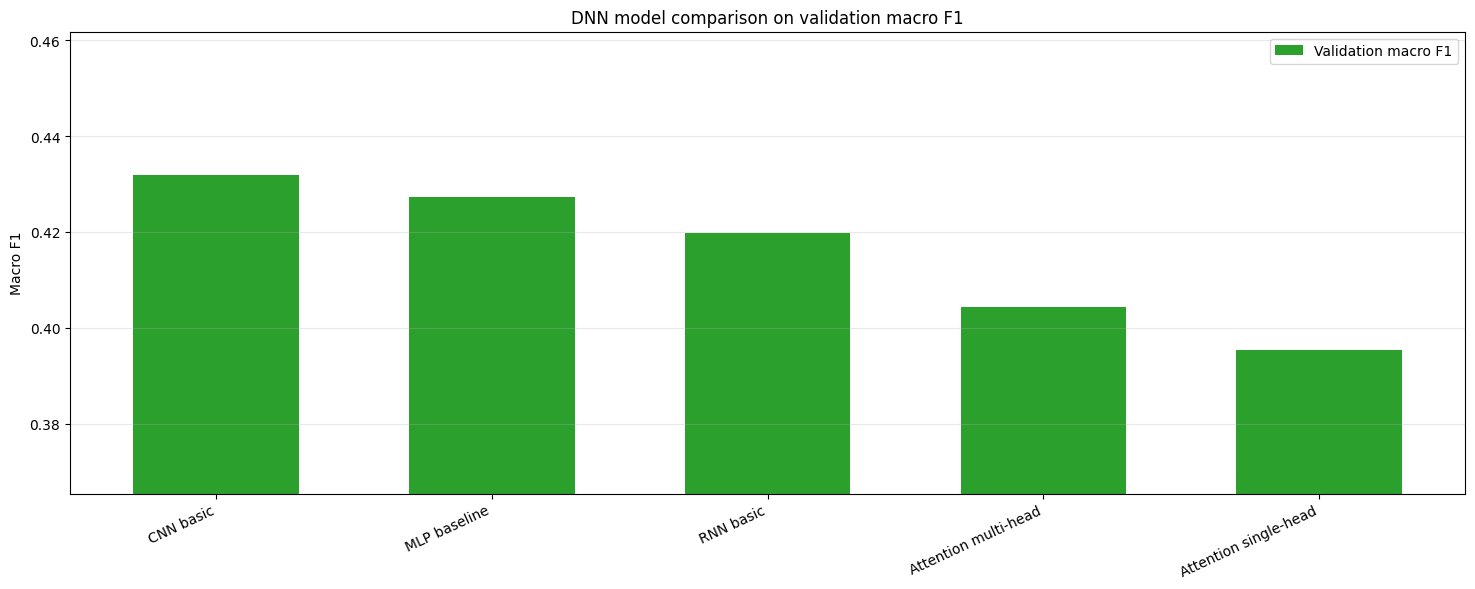

In [149]:
results_sorted = sorted(dnn_results, key=lambda row: row['val_macro_f1'], reverse=True)

print('Final ranking (sorted by validation macro F1):')
for rank, row in enumerate(results_sorted, start=1):
    print(
        f"{rank}. {row['model']:<24} | "
        f"val macro_f1={row['val_macro_f1']:.3f} | "
        f"val bal_acc={row['val_bal_acc']:.3f} | "
        f"test macro_f1={row['test_macro_f1']:.3f} | "
        f"test bal_acc={row['test_bal_acc']:.3f}"
    )

labels = [row['model'] for row in results_sorted]
f1_values = [row['val_macro_f1'] for row in results_sorted]

x = np.arange(len(labels))
max_f1 = max(f1_values)
y_max = min(1.0, max_f1 + 0.03)
y_min = max(0.0, min(f1_values) - 0.03)

plt.figure(figsize=(18, 6))
plt.bar(x, f1_values, width=0.6, color='tab:green', label='Validation macro F1')
plt.xticks(x, labels, rotation=25, ha='right')
plt.ylim(y_min, y_max)
plt.ylabel('Macro F1')
plt.title('DNN model comparison on validation macro F1')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()


### 3.8 Visualize The Best Validation-Selected DNN

The model below is chosen according to the best validation **macro F1**. We then evaluate and visualize it on the test set.


In [150]:
best_row = results_sorted[0]
best_model_name = best_row['model']
best_model = trained_dnn_models[best_model_name]
y_test_pred_dnn = predict_labels(best_model, test_loader, device=device)

print(
    f"Best model selected on validation macro F1: {best_model_name} | "
    f"val macro_f1={best_row['val_macro_f1']:.3f} | "
    f"val bal_acc={best_row['val_bal_acc']:.3f}"
)

print_classification_metrics(
    f'Test metrics ({best_model_name}, selected on validation macro F1)',
    y_test_win,
    y_test_pred_dnn,
    reference_labels=y_val_win,
)

class_labels = [f'Finger {i + 1}' for i in range(n_fingers)] + ['Rest']

tp.plot_prediction_vs_truth(
    y_test_win,
    y_test_pred_dnn,
    sample_rate=fs / hop_size,
    class_labels=class_labels,
    title='Prediction vs ground truth with temporal-window DNN',
    predicted_label=f'Prediction ({best_model_name})',
)


Best model selected on validation macro F1: CNN basic | val macro_f1=0.432 | val bal_acc=0.432
Test metrics (CNN basic, selected on validation macro F1)
  number of classes                  : 6
  chance level (validation set)    : 0.169 (always predict Rest)
  accuracy                           : 0.387
  balanced accuracy                  : 0.390
  macro F1                           : 0.379


## 3.9 Advanced: Attention Improvements

Goal: improve the attention model in three clear steps, directly inside the notebook:

1. improve the input representation with **5-buffer tokenisation**;
2. tune the model with a small **hyperparameter sweep** on the validation set;
3. choose a good **smoothing window** on the best swept model.


### 3.9.1 Tokenisation Optimisation

Until now, one power-feature vector summarized the whole 1-second buffer in a single block (`n_buffer = 1`). Here we reuse the same preprocessing pipeline, but change only one parameter: we split that 1-second window into **10 smaller power buffers**.

Why is this useful? Because the attention model can now see **finer temporal structure** inside each 1-second feature window, while still keeping the same CAR, band filtering, and normalization steps as before.

In the code below we:

1. rerun the shared preprocessing pipeline with `n_buffer = 10`;
2. reshape each example into a longer token sequence;
3. train the attention model with the shared `train_and_record(...)` function.


In [151]:
TOKEN_BUFFER_SIZE = 10
TOKEN_WINDOW_SIZE = 5 
TOKENISATION_LR = 2e-5
TOKENISATION_BATCH_SIZE = 128
TOKENISATION_WEIGHT_DECAY = 1e-4
TOKENISATION_EPOCHS = 50


def smooth_probabilities(probabilities, window_size):
    if window_size <= 1 or probabilities.shape[0] <= 1:
        return probabilities.copy()

    effective_window = min(window_size, probabilities.shape[0])
    kernel = np.ones(effective_window, dtype=float) / effective_window
    smoothed = np.stack(
        [np.convolve(probabilities[:, c], kernel, mode='same') for c in range(probabilities.shape[1])],
        axis=1,
    )
    smoothed /= np.maximum(smoothed.sum(axis=1, keepdims=True), 1e-8)
    return smoothed


def build_tokenized_attention_data(preprocessed, outer_window_size=10):
    base_feature_dim = preprocessed['X_train_filtered'].shape[1]

    X_train_local = preprocessed['X_train_features'][train_slice]
    X_val_local = preprocessed['X_train_features'][val_slice]
    X_test_local = preprocessed['X_test_features']

    X_train_win_local, y_train_win_local = build_temporal_windows(X_train_local, y_train, outer_window_size)
    X_val_win_local, y_val_win_local = build_temporal_windows(X_val_local, y_val, outer_window_size)
    X_test_win_local, y_test_win_local = build_temporal_windows(X_test_local, y_test, outer_window_size)

    def reshape_to_tokens(X_windows):
        n_samples = X_windows.shape[0]
        return X_windows.reshape(n_samples, outer_window_size, preprocessed['n_buffer'], base_feature_dim).reshape(
            n_samples,
            outer_window_size * preprocessed['n_buffer'],
            base_feature_dim,
        )

    return {
        'n_buffer': preprocessed['n_buffer'],
        'outer_window_size': outer_window_size,
        'seq_len': outer_window_size * preprocessed['n_buffer'],
        'n_features': base_feature_dim,
        'n_classes': int(np.max(y_train_win_local) + 1),
        'X_train': reshape_to_tokens(X_train_win_local),
        'y_train': y_train_win_local,
        'X_val': reshape_to_tokens(X_val_win_local),
        'y_val': y_val_win_local,
        'X_test': reshape_to_tokens(X_test_win_local),
        'y_test': y_test_win_local,
    }


advanced_preprocessed = tp.run_preprocessing_pipeline(
    subject_data.train_ecog,
    subject_data.test_ecog,
    bands=bands,
    fs=fs,
    channel_selection=channel_selection,
    car_method='car',
    normalization='zscore',
    feature_win_size=feature_win_size,
    hop_size=hop_size,
    n_buffer=TOKEN_BUFFER_SIZE,
    train_normalization_slice=train_slice,
)

advanced_token_data = build_tokenized_attention_data(
    advanced_preprocessed,
    outer_window_size=TOKEN_WINDOW_SIZE,
)

tokenisation_context = make_training_context(
    advanced_token_data['X_train'],
    advanced_token_data['y_train'],
    advanced_token_data['X_val'],
    advanced_token_data['y_val'],
    advanced_token_data['X_test'],
    advanced_token_data['y_test'],
    batch_size=TOKENISATION_BATCH_SIZE,
    n_classes=advanced_token_data['n_classes'],
    device=device,
    seed=SEED,
)
print('Base pipeline feature size (1 buffer):', X_train_features_full.shape[1])
print('Tokenised pipeline feature size (5 buffers):', advanced_preprocessed['X_train_features'].shape[1])
print('Old flat sample shape (time, features):', X_train_win.shape[1:])
print('New tokenised sample shape (tokens, features):', advanced_token_data['X_train'].shape[1:])

Base pipeline feature size (1 buffer): 244
Tokenised pipeline feature size (5 buffers): 2440
Old flat sample shape (time, features): (5, 244)
New tokenised sample shape (tokens, features): (50, 244)


In [152]:
tokenisation_run = train_and_record(
    context=tokenisation_context,
    model_name='Tokenisation optimisation',
    model=SingleHeadAttentionDecoder(
        n_features=advanced_token_data['n_features'],
        n_classes=advanced_token_data['n_classes'],
        max_len=advanced_token_data['seq_len'],
    ),
    n_epochs=TOKENISATION_EPOCHS,
    optimizer_name='adamw',
    lr=TOKENISATION_LR,
    weight_decay=TOKENISATION_WEIGHT_DECAY,
    checkpoint_metric='macro_f1',
    store_results=False,
    show_learning_curves=False,
    return_probabilities=True,
)

print('Tokenisation validation macro F1:', round(tokenisation_run['val_metrics']['macro_f1'], 3))
print('Tokenisation test macro F1      :', round(tokenisation_run['test_metrics']['macro_f1'], 3))


Training Tokenisation optimisation
Epoch 01/50 | train loss=1.7692 | val loss=1.7853 | val bal_acc=0.247 | val macro_f1=0.242
Epoch 02/50 | train loss=1.6774 | val loss=1.7459 | val bal_acc=0.281 | val macro_f1=0.274
Epoch 03/50 | train loss=1.5911 | val loss=1.7111 | val bal_acc=0.311 | val macro_f1=0.302
Epoch 04/50 | train loss=1.5069 | val loss=1.6777 | val bal_acc=0.352 | val macro_f1=0.338
Epoch 05/50 | train loss=1.4241 | val loss=1.6458 | val bal_acc=0.375 | val macro_f1=0.359
Epoch 06/50 | train loss=1.3413 | val loss=1.6130 | val bal_acc=0.403 | val macro_f1=0.384
Epoch 07/50 | train loss=1.2574 | val loss=1.5808 | val bal_acc=0.410 | val macro_f1=0.390
Epoch 08/50 | train loss=1.1757 | val loss=1.5505 | val bal_acc=0.404 | val macro_f1=0.383
Epoch 09/50 | train loss=1.0941 | val loss=1.5199 | val bal_acc=0.415 | val macro_f1=0.394
Epoch 10/50 | train loss=1.0161 | val loss=1.4913 | val bal_acc=0.427 | val macro_f1=0.406
Epoch 11/50 | train loss=0.9397 | val loss=1.4603 | va

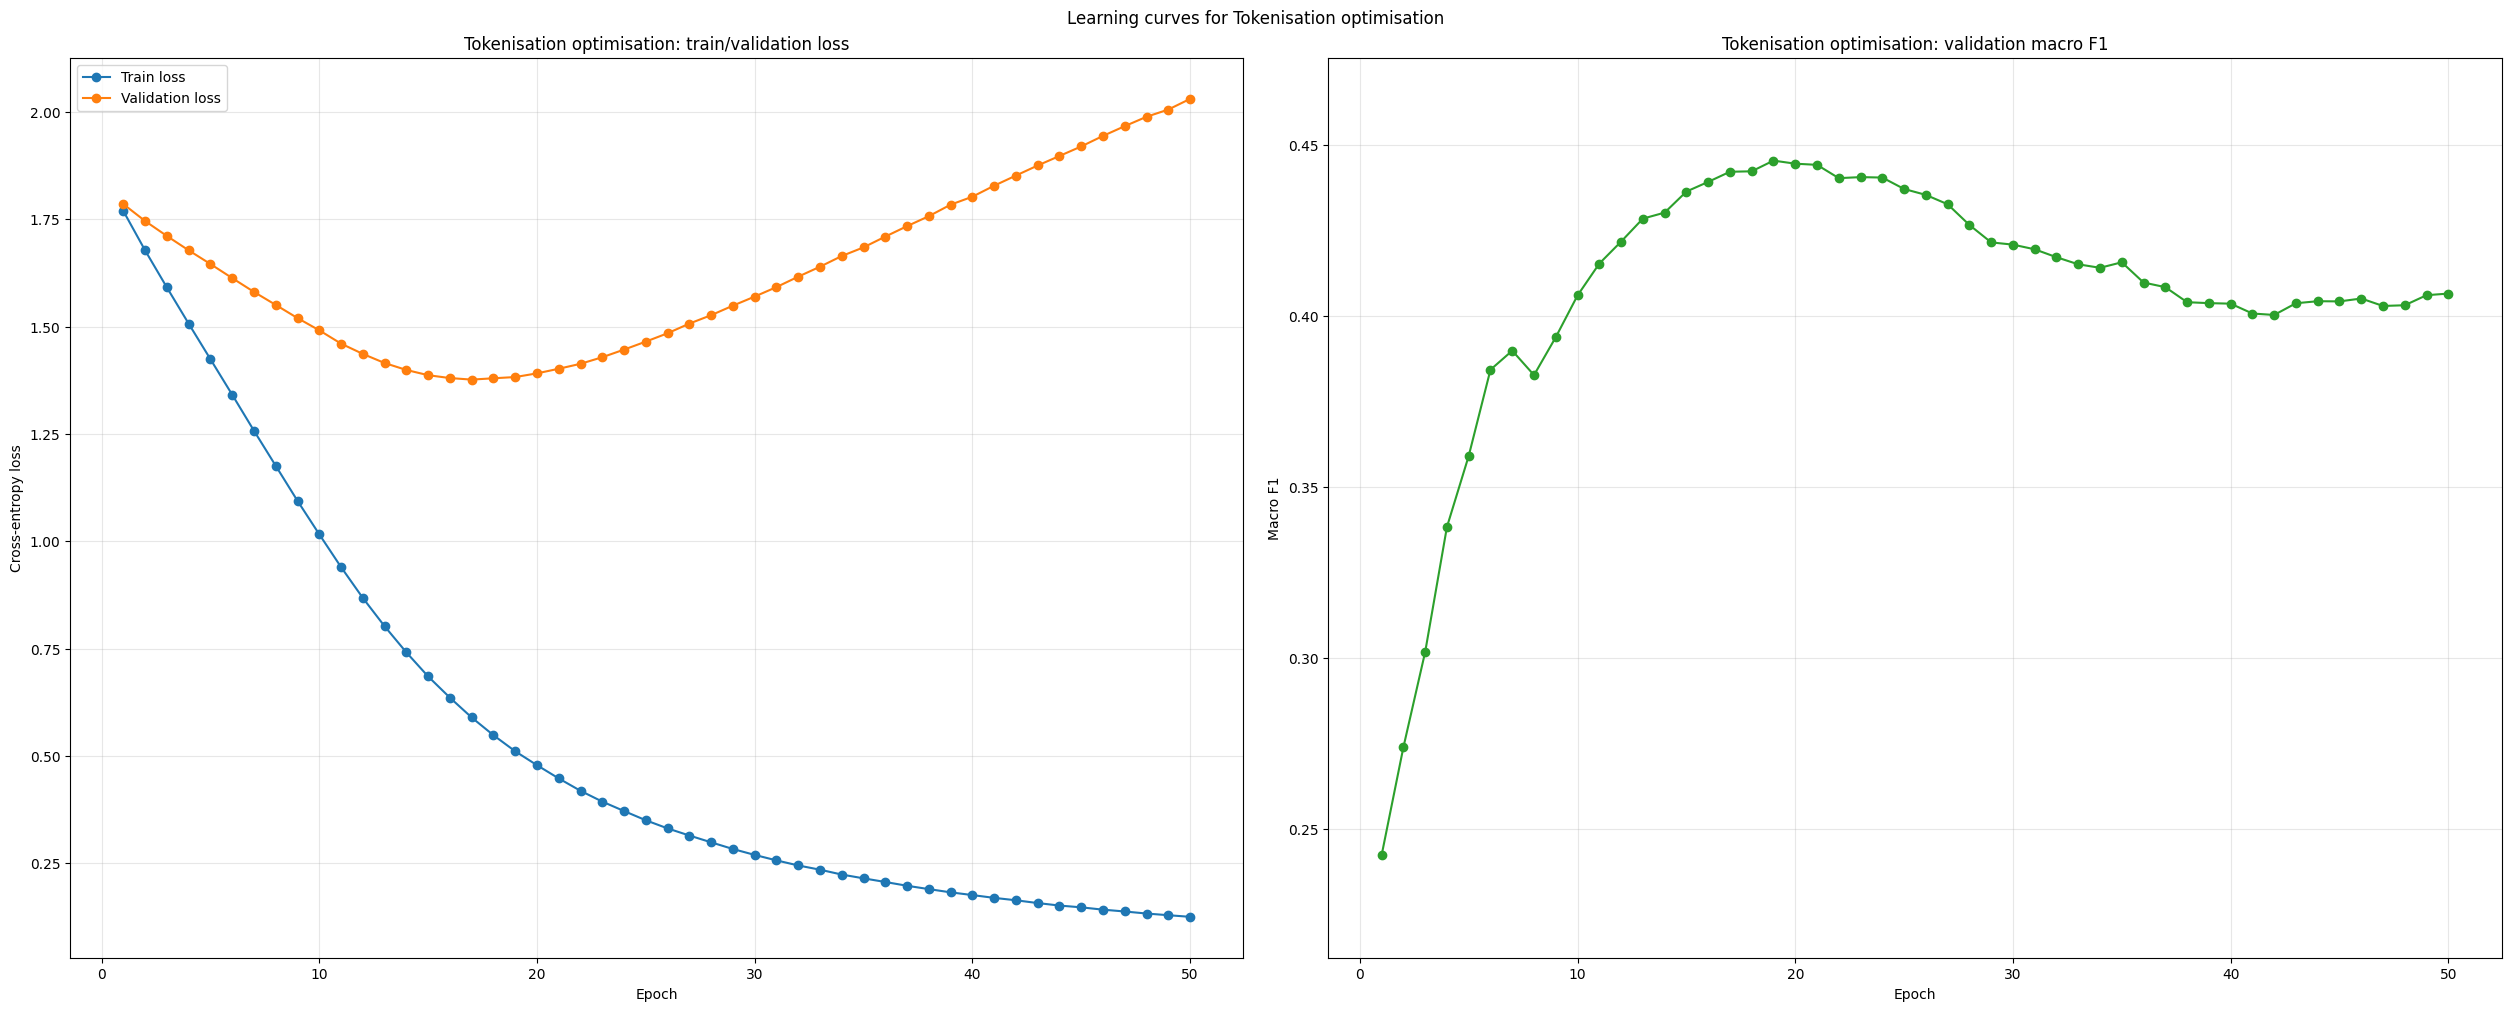

In [153]:
plot_dnn_learning_curves('Tokenisation optimisation', tokenisation_run['history'], figsize=FIGSIZE)

#### 3.9.2 Hyperparams Sweep

After tokenisation, we first tune the attention model itself before adding temporal smoothing.

We test a small but real grid:

- `lr` in `[1e-5, 2e-5, 5e-5]`
- `batch_size` in `[64, 128]`
- `weight_decay = 1e-3`

We then keep the run with the best **validation macro F1**.


In [154]:
hyperparam_grid = [
    {
        'lr': lr,
        'batch_size': batch_size,
        'weight_decay': 1e-3,
    }
    for lr in [1e-5, 2e-5, 5e-5]
    for batch_size in [64, 128]
]

advanced_hyperparam_rows = []
advanced_best_hyperparam_row = None

for config in hyperparam_grid:
    sweep_context = make_training_context(
        advanced_token_data['X_train'],
        advanced_token_data['y_train'],
        advanced_token_data['X_val'],
        advanced_token_data['y_val'],
        advanced_token_data['X_test'],
        advanced_token_data['y_test'],
        batch_size=config['batch_size'],
        n_classes=advanced_token_data['n_classes'],
        device=device,
        seed=SEED,
    )

    config_label = (
        f"lr={config['lr']:.0e}, "
        f"bs={config['batch_size']}, "
        f"wd={config['weight_decay']:.0e}"
    )

    run = train_and_record(
        context=sweep_context,
        model_name=config_label,
        model=SingleHeadAttentionDecoder(
            n_features=advanced_token_data['n_features'],
            n_classes=advanced_token_data['n_classes'],
            max_len=advanced_token_data['seq_len'],
        ),
        n_epochs=TOKENISATION_EPOCHS,
        optimizer_name='adamw',
        lr=config['lr'],
        weight_decay=config['weight_decay'],
        checkpoint_metric='macro_f1',
        store_results=False,
        show_learning_curves=False,
        return_probabilities=True,
    )

    row = {
        'config_label': config_label,
        'lr': config['lr'],
        'batch_size': config['batch_size'],
        'weight_decay': config['weight_decay'],
        'val_macro_f1': run['val_metrics']['macro_f1'],
        'test_macro_f1': run['test_metrics']['macro_f1'],
        'run': run,
    }
    advanced_hyperparam_rows.append(row)

    if advanced_best_hyperparam_row is None or row['val_macro_f1'] > advanced_best_hyperparam_row['val_macro_f1']:
        advanced_best_hyperparam_row = row

for row in advanced_hyperparam_rows:
    print(
        {
            'config': row['config_label'],
            'val_macro_f1': row['val_macro_f1'],
            'test_macro_f1': row['test_macro_f1'],
        }
    )

advanced_final_run = advanced_best_hyperparam_row['run']
advanced_final_config = {
    'lr': advanced_best_hyperparam_row['lr'],
    'batch_size': advanced_best_hyperparam_row['batch_size'],
    'weight_decay': advanced_best_hyperparam_row['weight_decay'],
}



Training lr=1e-05, bs=64, wd=1e-03
Epoch 01/50 | train loss=1.8083 | val loss=1.7503 | val bal_acc=0.228 | val macro_f1=0.197
Epoch 02/50 | train loss=1.7260 | val loss=1.7126 | val bal_acc=0.282 | val macro_f1=0.256
Epoch 03/50 | train loss=1.6483 | val loss=1.6791 | val bal_acc=0.325 | val macro_f1=0.304
Epoch 04/50 | train loss=1.5744 | val loss=1.6467 | val bal_acc=0.357 | val macro_f1=0.339
Epoch 05/50 | train loss=1.5015 | val loss=1.6153 | val bal_acc=0.375 | val macro_f1=0.358
Epoch 06/50 | train loss=1.4296 | val loss=1.5844 | val bal_acc=0.390 | val macro_f1=0.376
Epoch 07/50 | train loss=1.3590 | val loss=1.5538 | val bal_acc=0.411 | val macro_f1=0.398
Epoch 08/50 | train loss=1.2893 | val loss=1.5245 | val bal_acc=0.431 | val macro_f1=0.422
Epoch 09/50 | train loss=1.2195 | val loss=1.4947 | val bal_acc=0.445 | val macro_f1=0.438
Epoch 10/50 | train loss=1.1517 | val loss=1.4659 | val bal_acc=0.456 | val macro_f1=0.450
Epoch 11/50 | train loss=1.0853 | val loss=1.4357 | va

#### 3.9.3 Smoothing

Now that the hyperparameters are fixed, we smooth the predictions of the **best swept model**.

We test several smoothing windows on the validation set and keep the one with the best **validation macro F1**.


In [155]:
smoothing_windows = [1, 5, 11, 21, 31, 41, 51, 61, 71]
advanced_smoothing_rows = []

for window in smoothing_windows:
    val_proba_smoothed = smooth_probabilities(advanced_final_run['val_proba'], window)
    test_proba_smoothed = smooth_probabilities(advanced_final_run['test_proba'], window)

    val_pred_smoothed = np.argmax(val_proba_smoothed, axis=1)
    test_pred_smoothed = np.argmax(test_proba_smoothed, axis=1)

    advanced_smoothing_rows.append(
        {
            'window': window,
            'window_seconds': window * hop_size / fs,
            'val_macro_f1': f1_score(advanced_final_run['y_val_true'], val_pred_smoothed, average='macro'),
            'test_macro_f1': f1_score(advanced_final_run['y_test_true'], test_pred_smoothed, average='macro'),
        }
    )

best_smoothing_row = max(advanced_smoothing_rows, key=lambda row: row['val_macro_f1'])
best_smoothing_seconds = best_smoothing_row['window_seconds']
print('Best hyperparameters on validation:', advanced_final_config)
print('Best raw validation macro F1      :', round(advanced_best_hyperparam_row['val_macro_f1'], 3))
print(
    'Best smoothing window on validation:',
    f"{best_smoothing_row['window']} steps ({best_smoothing_seconds:.2f} s)",
)
print('Best smoothed validation macro F1  :', round(best_smoothing_row['val_macro_f1'], 3))
print('Smoothed test macro F1 at this window:', round(best_smoothing_row['test_macro_f1'], 3))

Best hyperparameters on validation: {'lr': 1e-05, 'batch_size': 64, 'weight_decay': 0.001}
Best raw validation macro F1      : 0.531
Best smoothing window on validation: 51 steps (2.04 s)
Best smoothed validation macro F1  : 0.585
Smoothed test macro F1 at this window: 0.524


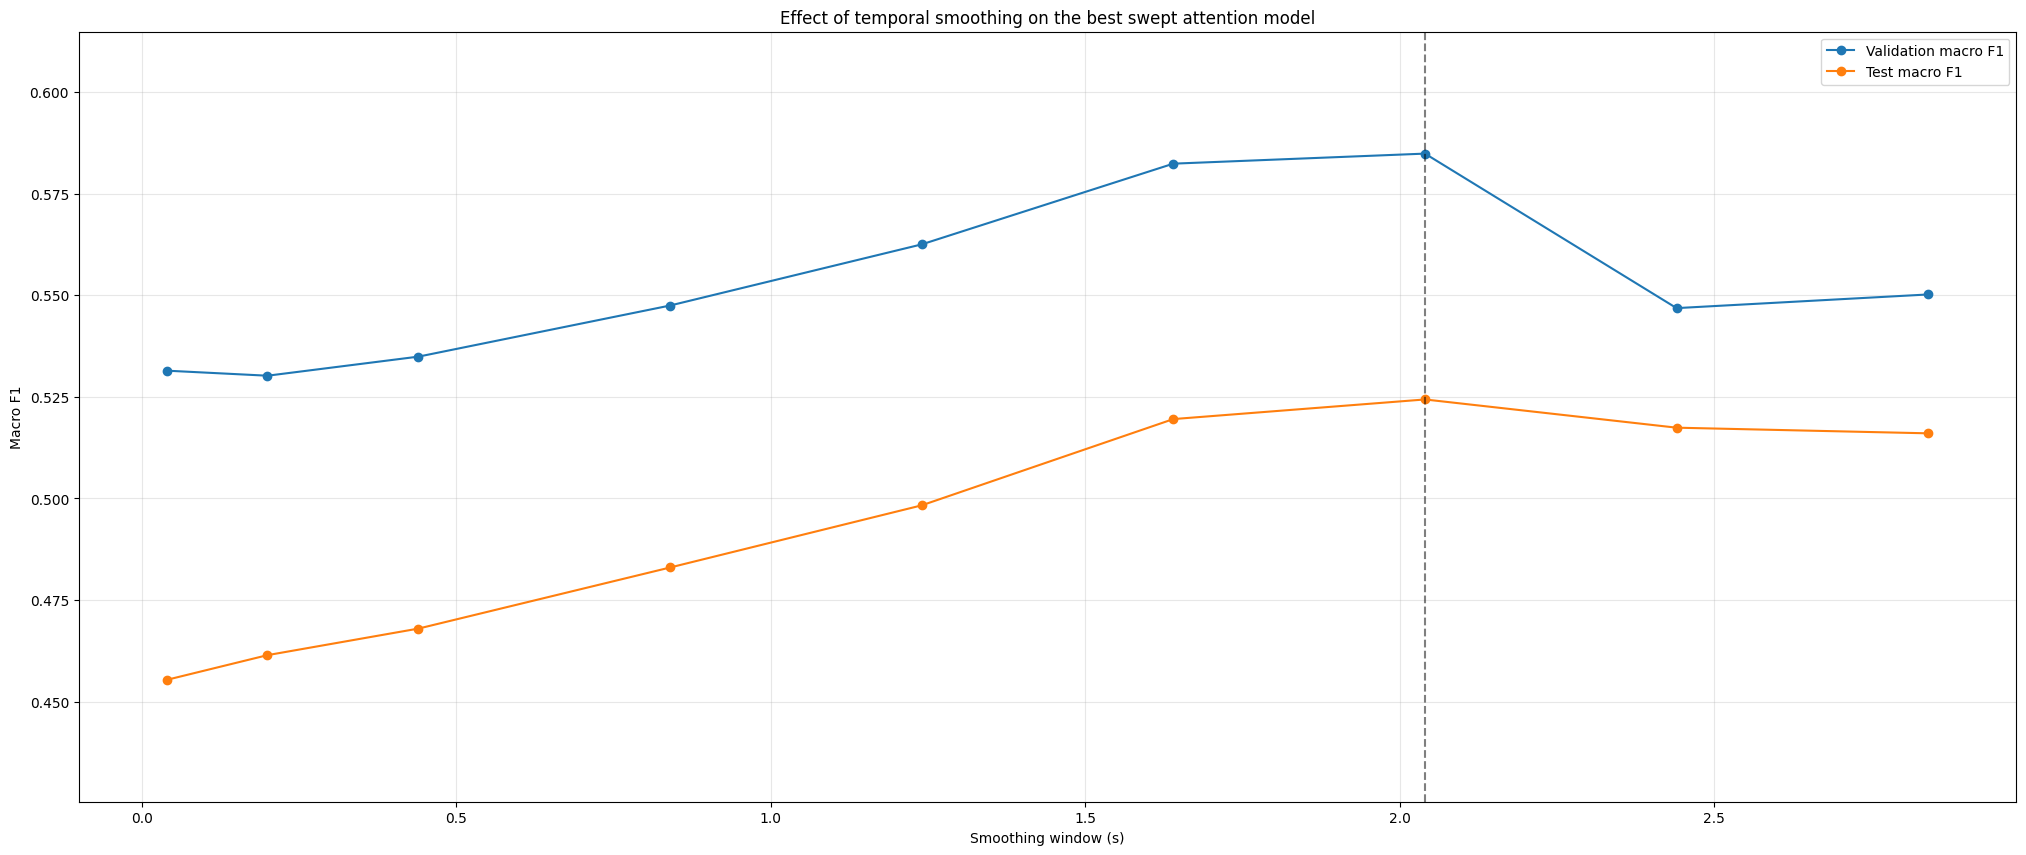

In [156]:
window_seconds = [row['window_seconds'] for row in advanced_smoothing_rows]
val_scores = [row['val_macro_f1'] for row in advanced_smoothing_rows]
test_scores = [row['test_macro_f1'] for row in advanced_smoothing_rows]

y_min = max(0.0, min(val_scores + test_scores) - 0.03)
y_max = min(1.0, max(val_scores + test_scores) + 0.03)

plt.figure(figsize=FIGSIZE)
plt.plot(window_seconds, val_scores, marker='o', label='Validation macro F1')
plt.plot(window_seconds, test_scores, marker='o', label='Test macro F1')
plt.axvline(best_smoothing_seconds, color='black', linestyle='--', alpha=0.5)
plt.xlabel('Smoothing window (s)')
plt.ylabel('Macro F1')
plt.ylim(y_min, y_max)
plt.title('Effect of temporal smoothing on the best swept attention model')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

#### 3.9.4 Final Model Vs Ground Truth

We now take the best hyperparameter configuration, apply the best smoothing window found on the validation set, and compare its predictions to the ground truth on the test recording.


In [157]:
advanced_final_test_proba_smoothed = smooth_probabilities(
    advanced_final_run['test_proba'],
    best_smoothing_row['window'],
)
advanced_final_test_pred = np.argmax(advanced_final_test_proba_smoothed, axis=1)

print('Final hyperparameters:', advanced_final_config)
print_classification_metrics(
    f"Advanced attention test metrics (smoothed, {best_smoothing_seconds:.2f} s)",
    advanced_final_run['y_test_true'],
    advanced_final_test_pred,
    reference_labels=advanced_final_run['y_val_true'],
)

Final hyperparameters: {'lr': 1e-05, 'batch_size': 64, 'weight_decay': 0.001}
Advanced attention test metrics (smoothed, 2.04 s)
  number of classes                  : 6
  chance level (validation set)    : 0.169 (always predict Rest)
  accuracy                           : 0.545
  balanced accuracy                  : 0.543
  macro F1                           : 0.524


In [158]:
class_labels = [f'Finger {i + 1}' for i in range(n_fingers)] + ['Rest']

tp.plot_prediction_vs_truth(
    advanced_final_run['y_test_true'],
    advanced_final_test_pred,
    sample_rate=fs / hop_size,
    class_labels=class_labels,
    title='Prediction vs ground truth for the final advanced model',
    predicted_label=f"Tokenised attention + smoothing ({best_smoothing_seconds:.2f} s)",
)

#### 3.9.5 Compare Final Advanced Model With Linear LDA

After selecting the best advanced model on the validation set and its smoothing window, we can compare it with the earlier **linear LDA** baseline.

To keep the comparison fair, we align the LDA predictions to the same target time points as the tokenised model.

Aligned test metrics (Linear LDA)
  number of classes                  : 6
  chance level (validation set)    : 0.169 (always predict Rest)
  accuracy                           : 0.451
  balanced accuracy                  : 0.451
  macro F1                           : 0.449
Aligned test metrics (Advanced attention + smoothing, 2.04 s)
  number of classes                  : 6
  chance level (validation set)    : 0.169 (always predict Rest)
  accuracy                           : 0.545
  balanced accuracy                  : 0.543
  macro F1                           : 0.524


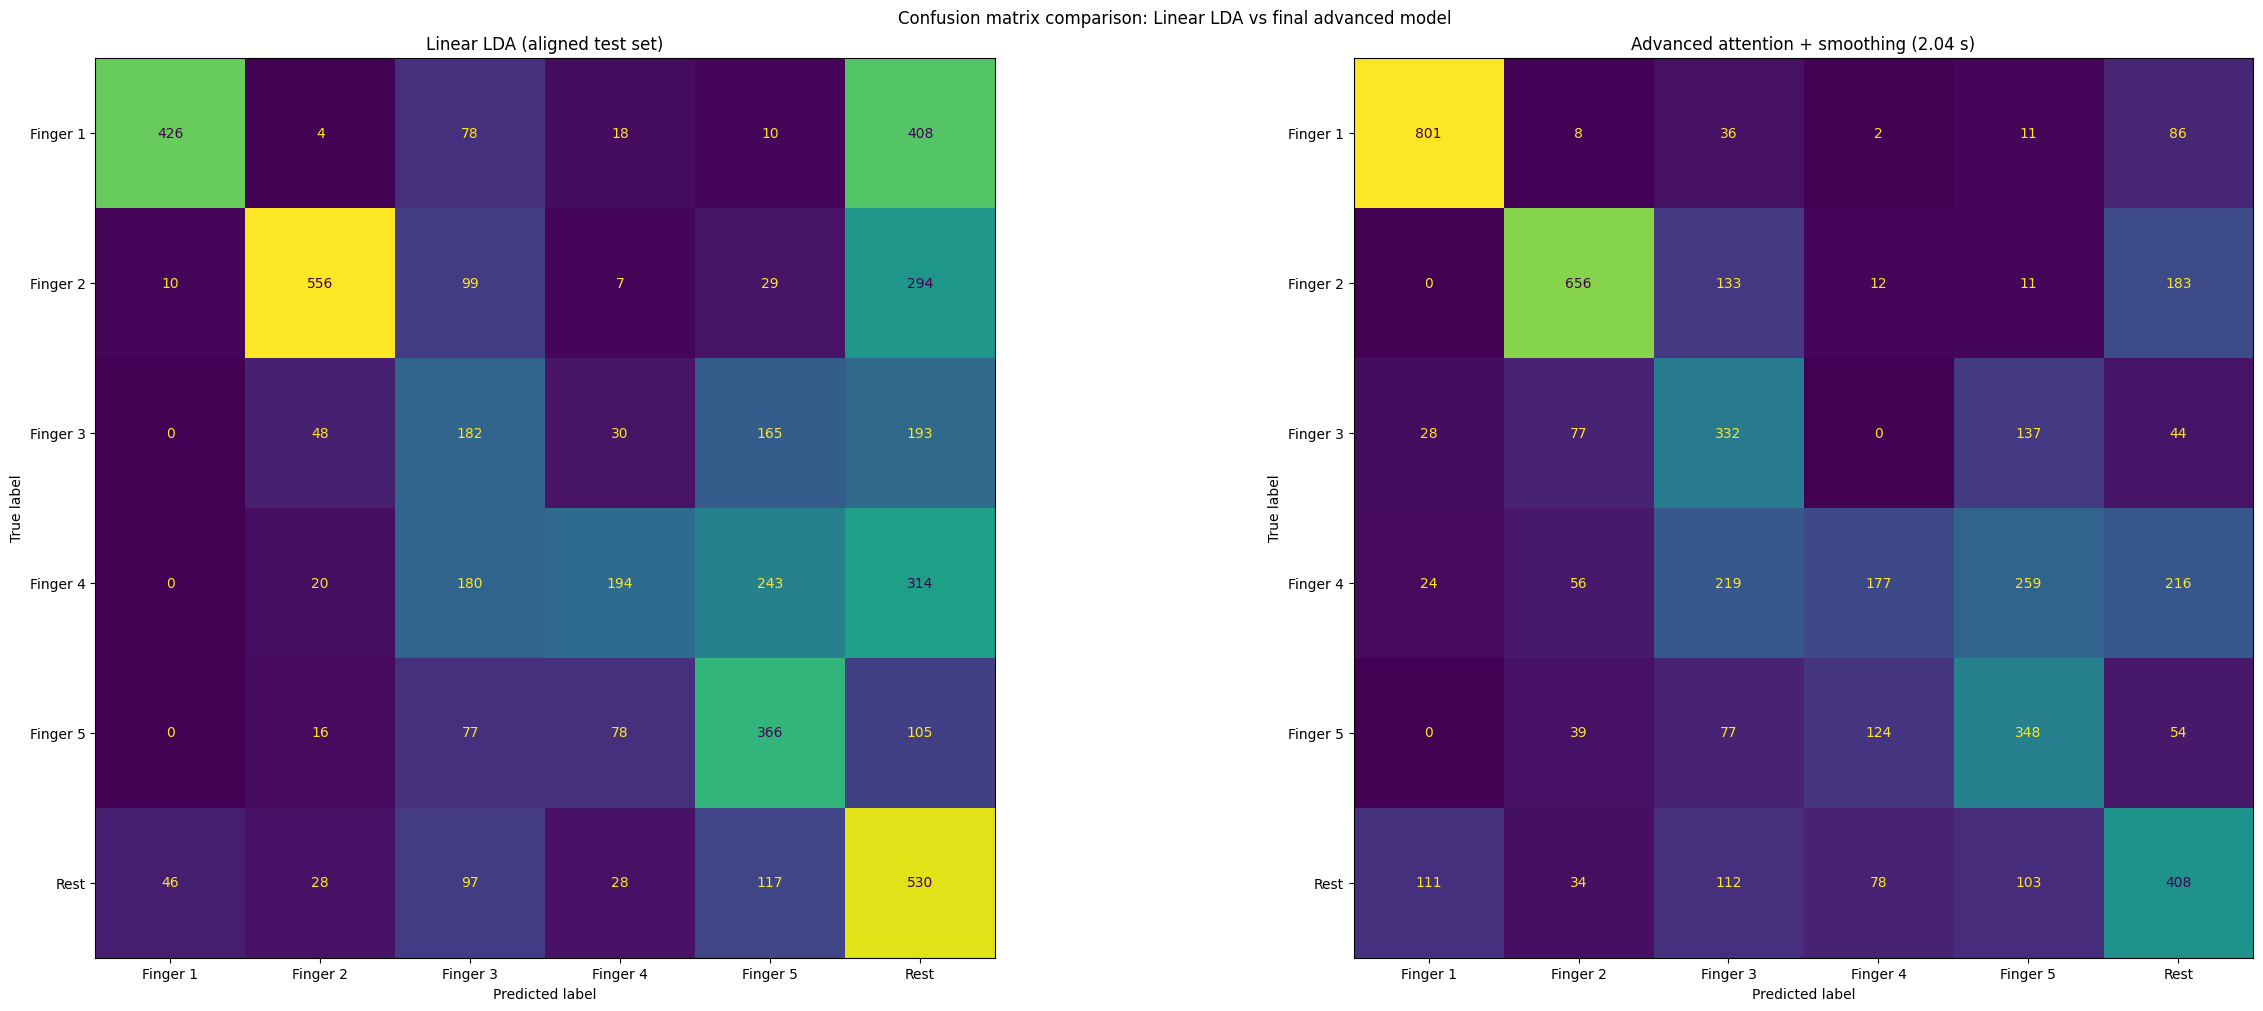

In [159]:
class_labels = [f'Finger {i + 1}' for i in range(n_fingers)] + ['Rest']

lda_alignment_offset = len(y_test) - len(advanced_final_run['y_test_true'])
y_test_lda_advanced_aligned = y_test[lda_alignment_offset:]
y_test_pred_lda_advanced_aligned = y_test_pred[lda_alignment_offset:]

print_classification_metrics(
    'Aligned test metrics (Linear LDA)',
    y_test_lda_advanced_aligned,
    y_test_pred_lda_advanced_aligned,
    reference_labels=advanced_final_run['y_val_true'],
)
print_classification_metrics(
    f"Aligned test metrics (Advanced attention + smoothing, {best_smoothing_seconds:.2f} s)",
    advanced_final_run['y_test_true'],
    advanced_final_test_pred,
    reference_labels=advanced_final_run['y_val_true'],
)

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE, constrained_layout=True)

ConfusionMatrixDisplay.from_predictions(
    y_test_lda_advanced_aligned,
    y_test_pred_lda_advanced_aligned,
    display_labels=class_labels,
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title('Linear LDA (aligned test set)')

ConfusionMatrixDisplay.from_predictions(
    advanced_final_run['y_test_true'],
    advanced_final_test_pred,
    display_labels=class_labels,
    ax=axes[1],
    colorbar=False,
)
axes[1].set_title(f"Advanced attention + smoothing ({best_smoothing_seconds:.2f} s)")

fig.suptitle('Confusion matrix comparison: Linear LDA vs final advanced model')
plt.show()